# 🎓 Analisis Data Eksploratif (EDA) Komprehensif — Dataset OULAD

**Open University Learning Analytics Dataset (OULAD)**

---

Notebook ini melakukan eksplorasi menyeluruh terhadap **7 file CSV** dari dataset OULAD yang mencakup data kursus, mahasiswa, penilaian, aktivitas virtual learning environment (VLE), dan registrasi.

### 📚 Daftar Dataset
| No | File | Baris | Deskripsi |
|---|---|---|---|
| 1 | `courses.csv` | 22 | Informasi modul & presentasi |
| 2 | `assessments.csv` | 206 | Detail penilaian |
| 3 | `studentInfo.csv` | 32.593 | Demografi & hasil akhir mahasiswa |
| 4 | `studentAssessment.csv` | 173.912 | Skor penilaian mahasiswa |
| 5 | `studentRegistration.csv` | 32.593 | Data registrasi & unregistrasi |
| 6 | `studentVle.csv` | ~10.6 juta | Interaksi mahasiswa dengan VLE |
| 7 | `vle.csv` | 6.364 | Metadata aktivitas VLE |

### 📌 Struktur Notebook
1. **Setup & Pemuatan Data**
2. **Analisis Kualitas Data**
3. **Analisis Univariat**
4. **Analisis Bivariat & Lintas Dataset**
5. **Analisis Perjalanan Mahasiswa**
6. **Deep Dive Aktivitas VLE**
7. **Analisis Bias & Kesetaraan**
8. **Rekayasa Fitur & Ekspor Data**

---
## 🛠️ Section 1: Setup & Pemuatan Data

Pada bagian ini kita akan:
- Memasang Google Drive
- Menginstal library tambahan jika diperlukan
- Memuat semua 7 dataset OULAD
- Menampilkan ringkasan awal setiap dataset (bentuk, tipe data, baris pertama)

In [1]:
# 1.1 Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# 1.2 Instalasi Library Tambahan
!pip install -q scipy

In [3]:
# 1.3 Import Semua Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import os
import warnings
import gc
import time

warnings.filterwarnings('ignore')

# Konfigurasi visualisasi global
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Path dataset
BASE_PATH = '/content/drive/MyDrive/AI-Learning Path/'
OUTPUT_PATH = os.path.join(BASE_PATH, 'processed')
os.makedirs(OUTPUT_PATH, exist_ok=True)

print("[OK] Semua library berhasil dimuat.")
print(f"[OK] Base path: {BASE_PATH}")
print(f"[OK] Output path: {OUTPUT_PATH}")

[OK] Semua library berhasil dimuat.
[OK] Base path: /content/drive/MyDrive/AI-Learning Path/
[OK] Output path: /content/drive/MyDrive/AI-Learning Path/processed


In [5]:
# 1.4 Fungsi Helper untuk Pemuatan & Inspeksi Data

def load_and_inspect(filename, description, nrows=None):

    filepath = os.path.join(BASE_PATH, filename)
    print(f"\n{'='*70}")
    print(f" Memuat: {filename} -- {description}")
    print(f"{'='*70}")

    start = time.time()
    df = pd.read_csv(filepath, nrows=nrows)
    elapsed = time.time() - start

    print(f" Waktu muat: {elapsed:.2f} detik")
    print(f" Shape: {df.shape[0]:,} baris x {df.shape[1]} kolom")
    print(f" Memori: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f" Tipe Data:")
    print(df.dtypes.to_string())
    print(f" 5 Baris Pertama:")
    display(df.head())

    return df

In [6]:
# 1.5 Muat Semua Dataset (kecuali studentVle)
df_courses = load_and_inspect('courses.csv', 'Informasi modul dan presentasi (22 baris)')
df_assessments = load_and_inspect('assessments.csv', 'Detail penilaian (206 baris)')
df_student_info = load_and_inspect('studentInfo.csv', 'Demografi & hasil akhir mahasiswa (32.593 baris)')
df_student_assessment = load_and_inspect('studentAssessment.csv', 'Skor penilaian mahasiswa (173.912 baris)')
df_student_reg = load_and_inspect('studentRegistration.csv', 'Data registrasi mahasiswa (32.593 baris)')
df_vle = load_and_inspect('vle.csv', 'Metadata aktivitas VLE (6.364 baris)')


 Memuat: courses.csv -- Informasi modul dan presentasi (22 baris)
 Waktu muat: 0.01 detik
 Shape: 22 baris x 3 kolom
 Memori: 0.00 MB
 Tipe Data:
code_module                   object
code_presentation             object
module_presentation_length     int64
 5 Baris Pertama:


,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240



 Memuat: assessments.csv -- Detail penilaian (206 baris)
 Waktu muat: 0.01 detik
 Shape: 206 baris x 6 kolom
 Memori: 0.04 MB
 Tipe Data:
code_module           object
code_presentation     object
id_assessment          int64
assessment_type       object
date                 float64
weight               float64
 5 Baris Pertama:


,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0



 Memuat: studentInfo.csv -- Demografi & hasil akhir mahasiswa (32.593 baris)
 Waktu muat: 0.08 detik
 Shape: 32,593 baris x 12 kolom
 Memori: 16.30 MB
 Tipe Data:
code_module             object
code_presentation       object
id_student               int64
gender                  object
region                  object
highest_education       object
imd_band                object
age_band                object
num_of_prev_attempts     int64
studied_credits          int64
disability              object
final_result            object
 5 Baris Pertama:


...

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0



 Memuat: studentRegistration.csv -- Data registrasi mahasiswa (32.593 baris)
 Waktu muat: 0.03 detik
 Shape: 32,593 baris x 5 kolom
 Memori: 4.04 MB
 Tipe Data:
code_module             object
code_presentation       object
id_student               int64
date_registration      float64
date_unregistration    float64
 5 Baris Pertama:


,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN



 Memuat: vle.csv -- Metadata aktivitas VLE (6.364 baris)
 Waktu muat: 0.01 detik
 Shape: 6,364 baris x 6 kolom
 Memori: 1.13 MB
 Tipe Data:
id_site                int64
code_module           object
code_presentation     object
activity_type         object
week_from            float64
week_to              float64
 5 Baris Pertama:


,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN


In [11]:
# 1.6 Muat studentVle.csv dengan Chunked Reading
# File studentVle.csv berukuran ~453 MB (~10.6 juta baris)
# Kita gunakan chunked reading untuk efisiensi memori

print(" Memuat studentVle.csv secara bertahap (chunked)...")
print(" File ini sangat besar (~453 MB). Proses ini mungkin memakan waktu beberapa menit.\n")

CHUNK_SIZE = 500_000
chunks = []
total_rows = 0

filepath_svle = os.path.join(BASE_PATH, 'studentVle.csv')

for i, chunk in enumerate(pd.read_csv(filepath_svle, chunksize=CHUNK_SIZE)):
    chunks.append(chunk)
    total_rows += len(chunk)
    if (i + 1) % 5 == 0:
        print(f"  \u2714\ufe0f Chunk {i+1} selesai -- Total baris dimuat: {total_rows:,}")

df_student_vle = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()

print(f"studentVle.csv berhasil dimuat!")
print(f" Shape: {df_student_vle.shape[0]:,} baris x {df_student_vle.shape[1]} kolom")
print(f" Memori: {df_student_vle.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Tipe Data:")
print(df_student_vle.dtypes.to_string())
print(f"5 Baris Pertama:")
display(df_student_vle.head())

 Memuat studentVle.csv secara bertahap (chunked)...
 File ini sangat besar (~453 MB). Proses ini mungkin memakan waktu beberapa menit.

  ✔️ Chunk 5 selesai -- Total baris dimuat: 2,500,000
  ✔️ Chunk 10 selesai -- Total baris dimuat: 5,000,000
  ✔️ Chunk 15 selesai -- Total baris dimuat: 7,500,000
  ✔️ Chunk 20 selesai -- Total baris dimuat: 10,000,000
studentVle.csv berhasil dimuat!
 Shape: 10,655,280 baris x 6 kolom
 Memori: 1402.31 MB
Tipe Data:
code_module          object
code_presentation    object
id_student            int64
id_site               int64
date                  int64
sum_click             int64
5 Baris Pertama:


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


### 📝 Ringkasan Pemuatan Data

Semua 7 dataset OULAD telah berhasil dimuat ke memori. Berikut rangkuman:

| Dataset | Variabel | Catatan |
|---|---|---|
| `courses` | Modul, presentasi, durasi | Data kecil (22 baris) |
| `assessments` | Jenis, tanggal, bobot penilaian | 206 entri penilaian |
| `studentInfo` | Demografi, hasil akhir | Data inti mahasiswa |
| `studentAssessment` | Skor, tanggal pengumpulan | 173K+ catatan skor |
| `studentRegistration` | Tanggal daftar/batal | Pelacakan registrasi |
| `studentVle` | Klik per sesi per mahasiswa | Dataset terbesar (~10.6M) |
| `vle` | Tipe aktivitas, periode | Metadata VLE |

---
## 🔍 Section 2: Analisis Kualitas Data

Pada bagian ini kita akan menganalisis kualitas data secara menyeluruh:
- **Nilai yang hilang (missing values)** — dengan heatmap dan tabel persentase
- **Deteksi duplikat** — apakah ada baris yang terulang?
- **Validasi tipe data** — apakah tipe data sudah sesuai?
- **Deteksi outlier** — untuk kolom numerik menggunakan metode IQR

In [12]:
# 2.1 Analisis Missing Values — Semua Dataset

datasets = {
    'courses': df_courses,
    'assessments': df_assessments,
    'studentInfo': df_student_info,
    'studentAssessment': df_student_assessment,
    'studentRegistration': df_student_reg,
    'vle': df_vle,
    'studentVle': df_student_vle
}

print("RINGKASAN MISSING VALUES SEMUA DATASET")

missing_summary = []

for name, df in datasets.items():
    total_cells = df.shape[0] * df.shape[1]
    missing_cells = df.isnull().sum().sum()
    missing_pct = (missing_cells / total_cells * 100) if total_cells > 0 else 0

    missing_cols = df.isnull().sum()
    cols_with_missing = missing_cols[missing_cols > 0]

    missing_summary.append({
        'Dataset': name,
        'Total Baris': f"{df.shape[0]:,}",
        'Total Kolom': df.shape[1],
        'Total Missing': f"{missing_cells:,}",
        'Persen Missing': f"{missing_pct:.2f}%",
        'Kolom Bermasalah': len(cols_with_missing)
    })

    if len(cols_with_missing) > 0:
        print(f"\n\ud83d\udcc1 {name}:")
        for col, count in cols_with_missing.items():
            pct = count / df.shape[0] * 100
            print(f"   - {col}: {count:,} missing ({pct:.1f}%)")

print("\n")
df_missing_summary = pd.DataFrame(missing_summary)
display(df_missing_summary)

ERROR:tornado.application:Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x7d588046f1c0>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 70-71: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_send = self.serialize(msg, ident)
              ^^^^^^

,Dataset,Total Baris,Total Kolom,Total Missing,Persen Missing,Kolom Bermasalah
0,courses,22,3,0,0.00%,0
1,assessments,206,6,11,0.89%,1
2,studentInfo,"32,593",12,"1,111",0.28%,1
3,studentAssessment,"173,912",5,173,0.02%,1
4,studentRegistration,"32,593",5,"22,566",13.85%,2
5,vle,"6,364",6,"10,486",27.46%,2
6,studentVle,"10,655,280",6,0,0.00%,0


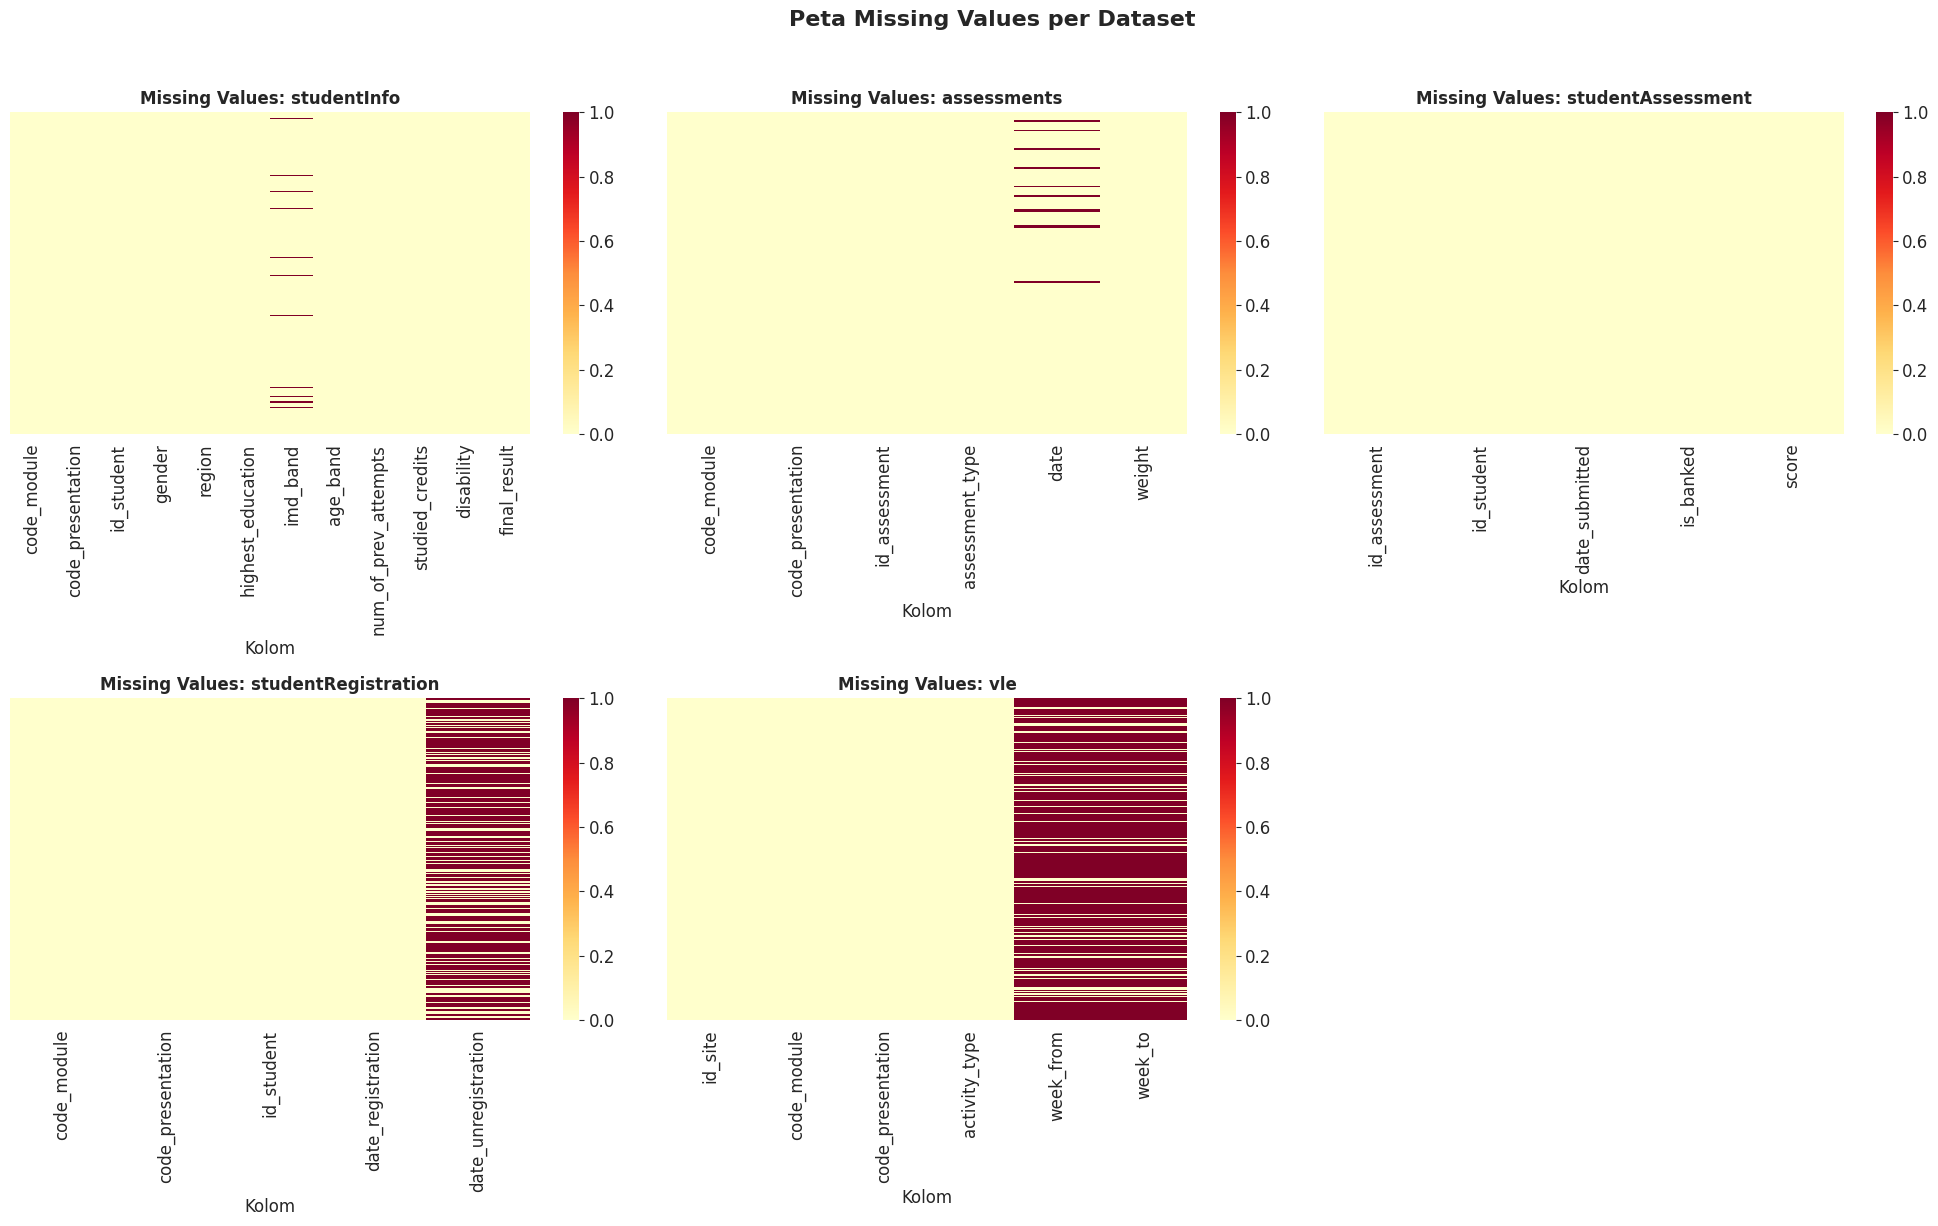

In [13]:
# 2.2 Heatmap Missing Values untuk Dataset Utama

# Pilih dataset yang memiliki missing values signifikan
datasets_to_plot = {
    'studentInfo': df_student_info,
    'assessments': df_assessments,
    'studentAssessment': df_student_assessment,
    'studentRegistration': df_student_reg,
    'vle': df_vle
}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, (name, df) in enumerate(datasets_to_plot.items()):
    ax = axes[idx]
    # Buat matrix missing values: 1 = missing, 0 = ada
    missing_matrix = df.isnull().astype(int)

    # Untuk dataset besar, ambil sampel
    if len(missing_matrix) > 1000:
        missing_matrix = missing_matrix.sample(1000, random_state=42)

    sns.heatmap(missing_matrix, cbar=True, yticklabels=False,
                cmap='YlOrRd', ax=ax)
    ax.set_title(f'Missing Values: {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Kolom')

# Sembunyikan subplot kosong
for idx in range(len(datasets_to_plot), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Peta Missing Values per Dataset', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# 2.3 Deteksi Duplikat

print("DETEKSI DUPLIKAT SEMUA DATASET")
print("=" * 70)

duplicate_results = []
for name, df in datasets.items():
    n_dups = df.duplicated().sum()
    pct = n_dups / len(df) * 100 if len(df) > 0 else 0
    status = "\u26a0\ufe0f ADA" if n_dups > 0 else "[OK] BERSIH"
    duplicate_results.append({
        'Dataset': name,
        'Jumlah Duplikat': n_dups,
        'Persentase': f"{pct:.2f}%",
        'Status': status
    })
    print(f"  {status} {name}: {n_dups:,} duplikat ({pct:.2f}%)")

print("\n")
display(pd.DataFrame(duplicate_results))

DETEKSI DUPLIKAT SEMUA DATASET
  [OK] BERSIH courses: 0 duplikat (0.00%)
  [OK] BERSIH assessments: 0 duplikat (0.00%)
  [OK] BERSIH studentInfo: 0 duplikat (0.00%)
  [OK] BERSIH studentAssessment: 0 duplikat (0.00%)
  [OK] BERSIH studentRegistration: 0 duplikat (0.00%)
  [OK] BERSIH vle: 0 duplikat (0.00%)
  ⚠️ ADA studentVle: 787,170 duplikat (7.39%)




,Dataset,Jumlah Duplikat,Persentase,Status
0,courses,0,0.00%,[OK] BERSIH
1,assessments,0,0.00%,[OK] BERSIH
2,studentInfo,0,0.00%,[OK] BERSIH
3,studentAssessment,0,0.00%,[OK] BERSIH
4,studentRegistration,0,0.00%,[OK] BERSIH
5,vle,0,0.00%,[OK] BERSIH
6,studentVle,787170,7.39%,⚠️ ADA


In [15]:
# 2.4 Validasi Tipe Data

print("VALIDASI TIPE DATA")
print("=" * 70)

expected_types = {
    'courses': {
        'code_module': 'object', 'code_presentation': 'object',
        'module_presentation_length': 'int64'
    },
    'assessments': {
        'code_module': 'object', 'code_presentation': 'object',
        'id_assessment': 'int64', 'assessment_type': 'object',
        'date': 'float64', 'weight': 'float64'
    },
    'studentInfo': {
        'id_student': 'int64', 'gender': 'object',
        'region': 'object', 'highest_education': 'object',
        'imd_band': 'object', 'age_band': 'object',
        'num_of_prev_attempts': 'int64', 'studied_credits': 'int64',
        'disability': 'object', 'final_result': 'object'
    }
}

for ds_name, expected in expected_types.items():
    df = datasets[ds_name]
    print(f"{ds_name}:")
    for col, exp_type in expected.items():
        if col in df.columns:
            actual = str(df[col].dtype)
            match = "[OK]" if actual == exp_type else ""
            print(f"   {match} {col}: diharapkan={exp_type}, aktual={actual}")
        else:
            print(f"   [X] {col}: KOLOM TIDAK DITEMUKAN")

VALIDASI TIPE DATA
courses:
   [OK] code_module: diharapkan=object, aktual=object
   [OK] code_presentation: diharapkan=object, aktual=object
   [OK] module_presentation_length: diharapkan=int64, aktual=int64
assessments:
   [OK] code_module: diharapkan=object, aktual=object
   [OK] code_presentation: diharapkan=object, aktual=object
   [OK] id_assessment: diharapkan=int64, aktual=int64
   [OK] assessment_type: diharapkan=object, aktual=object
   [OK] date: diharapkan=float64, aktual=float64
   [OK] weight: diharapkan=float64, aktual=float64
studentInfo:
   [OK] id_student: diharapkan=int64, aktual=int64
   [OK] gender: diharapkan=object, aktual=object
   [OK] region: diharapkan=object, aktual=object
   [OK] highest_education: diharapkan=object, aktual=object
   [OK] imd_band: diharapkan=object, aktual=object
   [OK] age_band: diharapkan=object, aktual=object
   [OK] num_of_prev_attempts: diharapkan=int64, aktual=int64
   [OK] studied_credits: diharapkan=int64, aktual=int64
   [OK] dis

DETEKSI OUTLIER (Metode IQR)


,Dataset,Kolom,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier,Persen Outlier
0,courses,module_presentation_length,241.0,268.00,27.00,200.500,308.500,0,0.00%
1,studentInfo,num_of_prev_attempts,0.0,0.00,0.00,0.000,0.000,4172,12.80%
2,studentInfo,studied_credits,60.0,120.00,60.00,-30.000,210.000,350,1.07%
3,studentAssessment,score,65.0,90.00,25.00,27.500,127.500,3813,2.19%
4,assessments,weight,0.0,24.25,24.25,-36.375,60.625,24,11.65%


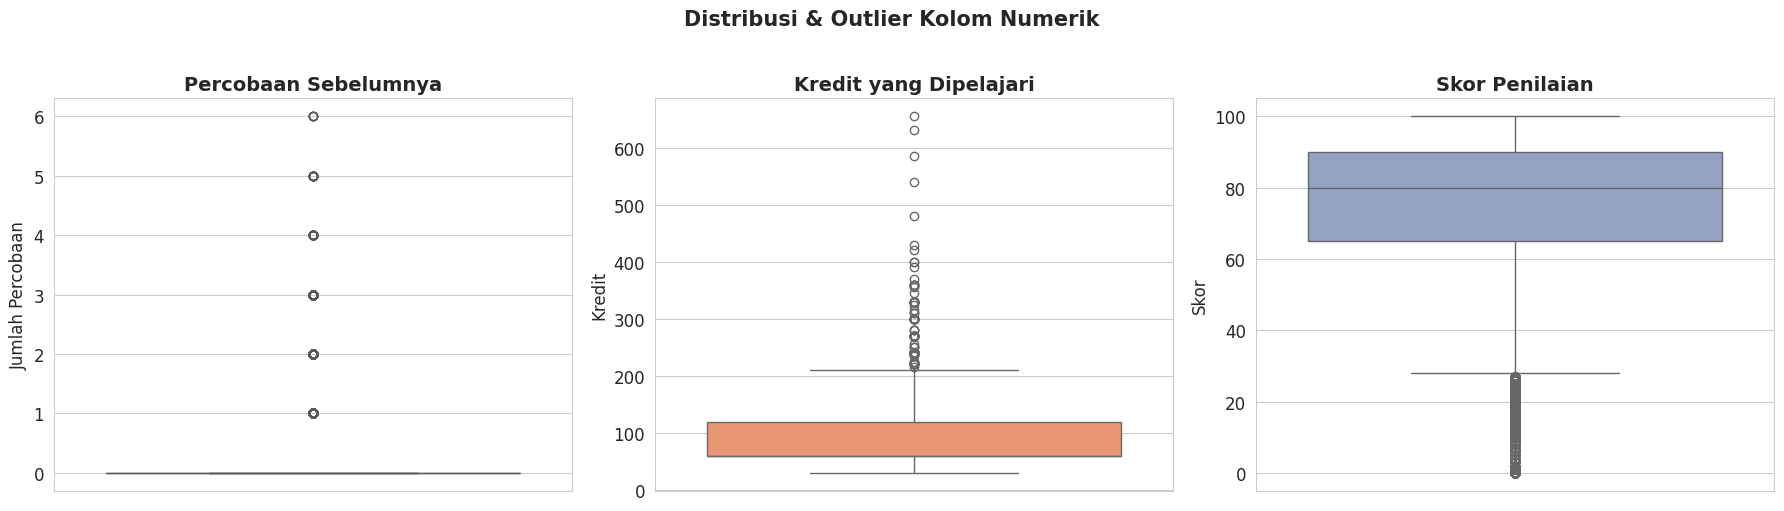

In [17]:
# 2.5 Deteksi Outlier — Metode IQR

def detect_outliers_iqr(df, column):
    """Deteksi outlier menggunakan metode IQR (Interquartile Range).

    Returns
    -------
    dict : statistik outlier
    """
    data = df[column].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data < lower) | (data > upper)]
    return {
        'Kolom': column,
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Batas Bawah': lower, 'Batas Atas': upper,
        'Jumlah Outlier': len(outliers),
        'Persen Outlier': f"{len(outliers)/len(data)*100:.2f}%"
    }

# Kolom numerik yang akan dianalisis
numeric_checks = [
    ('courses', 'module_presentation_length'),
    ('studentInfo', 'num_of_prev_attempts'),
    ('studentInfo', 'studied_credits'),
    ('studentAssessment', 'score'),
    ('assessments', 'weight'),
]

print("DETEKSI OUTLIER (Metode IQR)")

outlier_results = []
for ds_name, col in numeric_checks:
    result = detect_outliers_iqr(datasets[ds_name], col)
    result['Dataset'] = ds_name
    outlier_results.append(result)

df_outliers = pd.DataFrame(outlier_results)[['Dataset', 'Kolom', 'Q1', 'Q3', 'IQR',
                                              'Batas Bawah', 'Batas Atas',
                                              'Jumlah Outlier', 'Persen Outlier']]
display(df_outliers)

# Boxplot untuk kolom numerik kunci
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df_student_info, y='num_of_prev_attempts', ax=axes[0], color='#66c2a5')
axes[0].set_title('Percobaan Sebelumnya', fontweight='bold')
axes[0].set_ylabel('Jumlah Percobaan')

sns.boxplot(data=df_student_info, y='studied_credits', ax=axes[1], color='#fc8d62')
axes[1].set_title('Kredit yang Dipelajari', fontweight='bold')
axes[1].set_ylabel('Kredit')

sns.boxplot(data=df_student_assessment, y='score', ax=axes[2], color='#8da0cb')
axes[2].set_title('Skor Penilaian', fontweight='bold')
axes[2].set_ylabel('Skor')

plt.suptitle('Distribusi & Outlier Kolom Numerik', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 📝 Temuan Kualitas Data

**Missing Values:**
- `imd_band` pada studentInfo memiliki nilai kosong — ini mewakili mahasiswa yang data sosial-ekonominya tidak tersedia.
- `date` pada assessments memiliki beberapa nilai NaN — biasanya untuk ujian akhir yang belum dijadwalkan.
- `date_unregistration` pada studentRegistration banyak NaN — ini normal, menunjukkan mahasiswa yang **tidak** membatalkan registrasi.
- `week_from` dan `week_to` pada vle juga memiliki missing values.

**Duplikat:** Perlu dicek apakah ada baris duplikat murni (jika ada, mungkin data entry error).

**Outlier:**
- `num_of_prev_attempts` memiliki outlier pada mahasiswa yang sudah berkali-kali mencoba.
- `score` memiliki nilai di atas 100 yang perlu diperhatikan.
- `studied_credits` bervariasi dari 30 hingga 600+ kredit.

---
## 📊 Section 3: Analisis Univariat

Pada bagian ini kita akan mengeksplorasi distribusi masing-masing variabel secara individu:
- Distribusi modul dan presentasi
- Demografi mahasiswa (gender, umur, wilayah, pendidikan, dll)
- Distribusi jenis penilaian
- Distribusi tipe aktivitas VLE

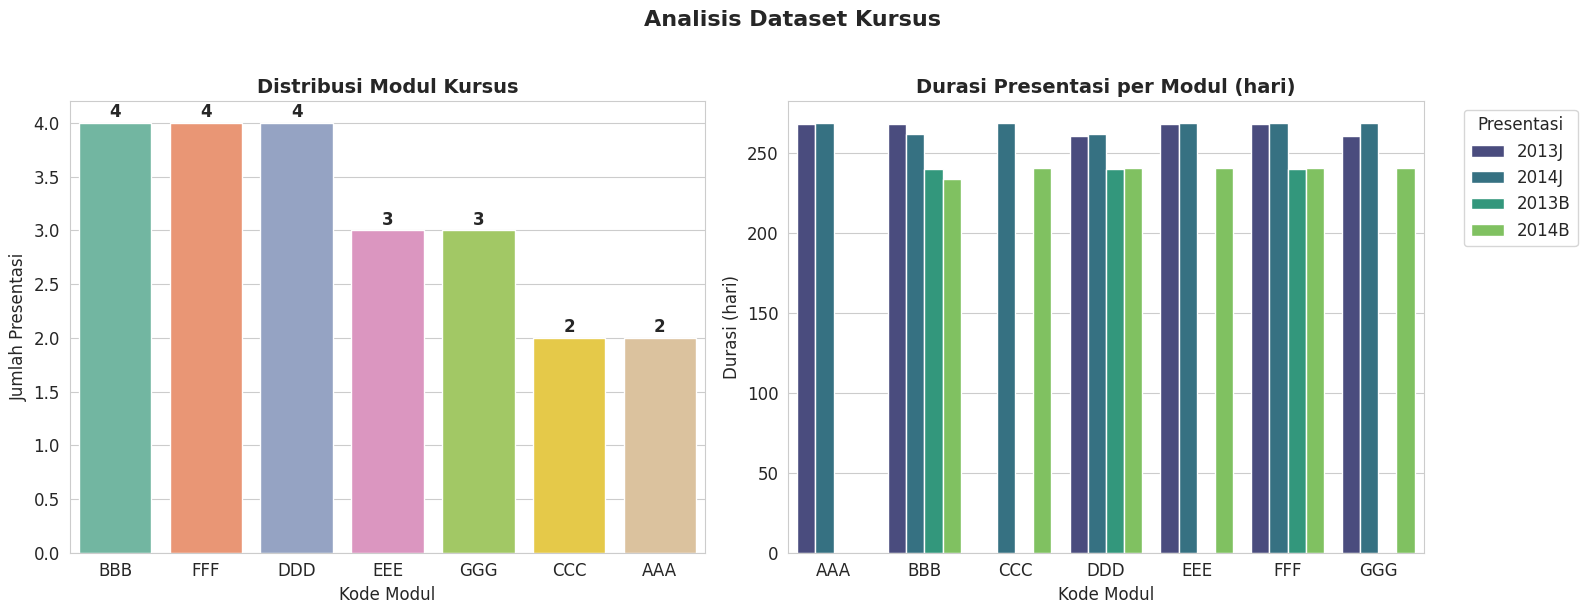

Statistik Deskriptif Durasi Presentasi:


,module_presentation_length
count,22.000000
mean,255.545455
std,13.654677
min,234.000000
25%,241.000000
50%,261.500000
75%,268.000000
max,269.000000


In [18]:
# 3.1 Kursus: Distribusi Modul & Durasi Presentasi

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribusi modul
module_counts = df_courses['code_module'].value_counts()
sns.barplot(x=module_counts.index, y=module_counts.values, ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Modul Kursus', fontweight='bold')
axes[0].set_xlabel('Kode Modul')
axes[0].set_ylabel('Jumlah Presentasi')
for i, v in enumerate(module_counts.values):
    axes[0].text(i, v + 0.05, str(v), ha='center', fontweight='bold')

# Distribusi durasi presentasi
sns.barplot(data=df_courses, x='code_module', y='module_presentation_length',
            hue='code_presentation', ax=axes[1], palette='viridis')
axes[1].set_title('Durasi Presentasi per Modul (hari)', fontweight='bold')
axes[1].set_xlabel('Kode Modul')
axes[1].set_ylabel('Durasi (hari)')
axes[1].legend(title='Presentasi', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Analisis Dataset Kursus', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Statistik Deskriptif Durasi Presentasi:")
display(df_courses['module_presentation_length'].describe())

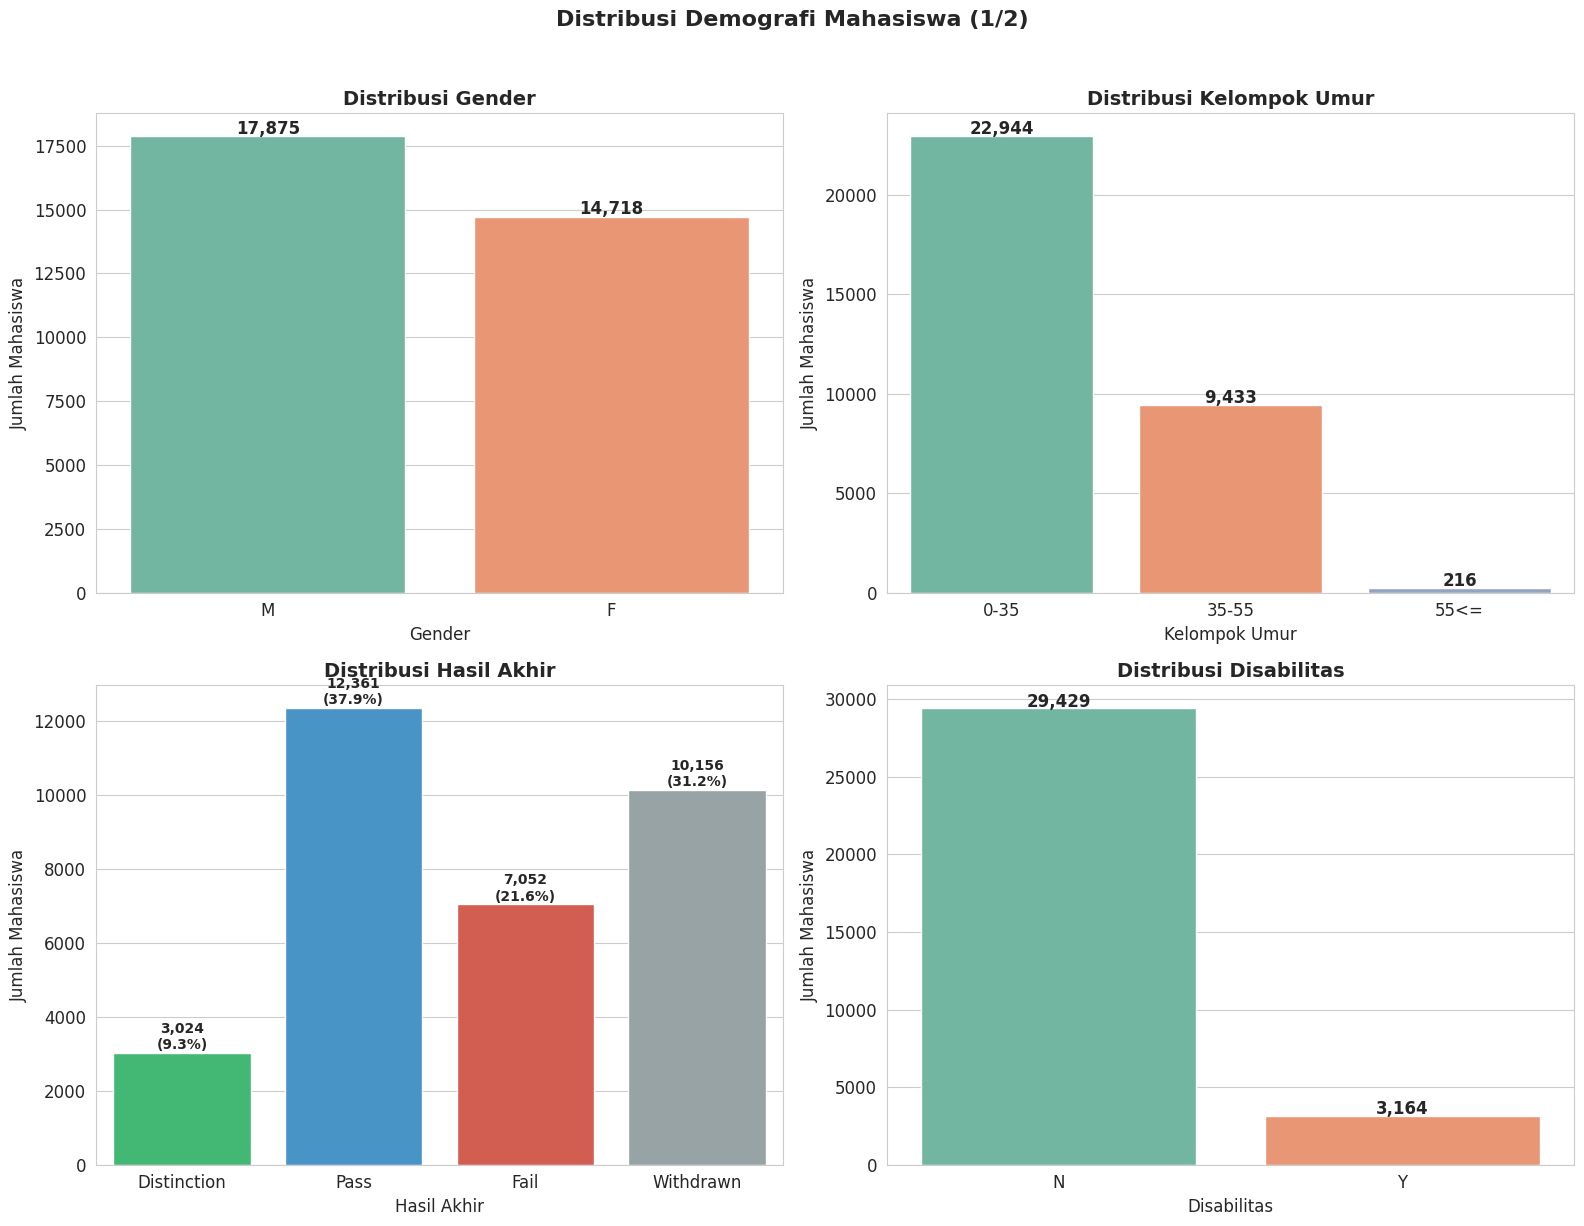

In [19]:
# 3.2 Mahasiswa: Distribusi Demografi (Bagian 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gender
gender_counts = df_student_info['gender'].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Distribusi Gender', fontweight='bold')
axes[0, 0].set_xlabel('Gender')
axes[0, 0].set_ylabel('Jumlah Mahasiswa')
for i, v in enumerate(gender_counts.values):
    axes[0, 0].text(i, v + 100, f"{v:,}", ha='center', fontweight='bold')

# Age Band
age_order = ['0-35', '35-55', '55<=']
age_counts = df_student_info['age_band'].value_counts().reindex(age_order)
sns.barplot(x=age_counts.index, y=age_counts.values, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Distribusi Kelompok Umur', fontweight='bold')
axes[0, 1].set_xlabel('Kelompok Umur')
axes[0, 1].set_ylabel('Jumlah Mahasiswa')
for i, v in enumerate(age_counts.values):
    axes[0, 1].text(i, v + 100, f"{v:,}", ha='center', fontweight='bold')

# Final Result
result_order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
result_counts = df_student_info['final_result'].value_counts().reindex(result_order)
colors_result = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']
sns.barplot(x=result_counts.index, y=result_counts.values, ax=axes[1, 0], palette=colors_result)
axes[1, 0].set_title('Distribusi Hasil Akhir', fontweight='bold')
axes[1, 0].set_xlabel('Hasil Akhir')
axes[1, 0].set_ylabel('Jumlah Mahasiswa')
for i, v in enumerate(result_counts.values):
    pct = v / len(df_student_info) * 100
    axes[1, 0].text(i, v + 100, f"{v:,}\n({pct:.1f}%)", ha='center', fontweight='bold', fontsize=10)

# Disability
disability_counts = df_student_info['disability'].value_counts()
sns.barplot(x=disability_counts.index, y=disability_counts.values, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Distribusi Disabilitas', fontweight='bold')
axes[1, 1].set_xlabel('Disabilitas')
axes[1, 1].set_ylabel('Jumlah Mahasiswa')
for i, v in enumerate(disability_counts.values):
    axes[1, 1].text(i, v + 100, f"{v:,}", ha='center', fontweight='bold')

plt.suptitle('Distribusi Demografi Mahasiswa (1/2)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

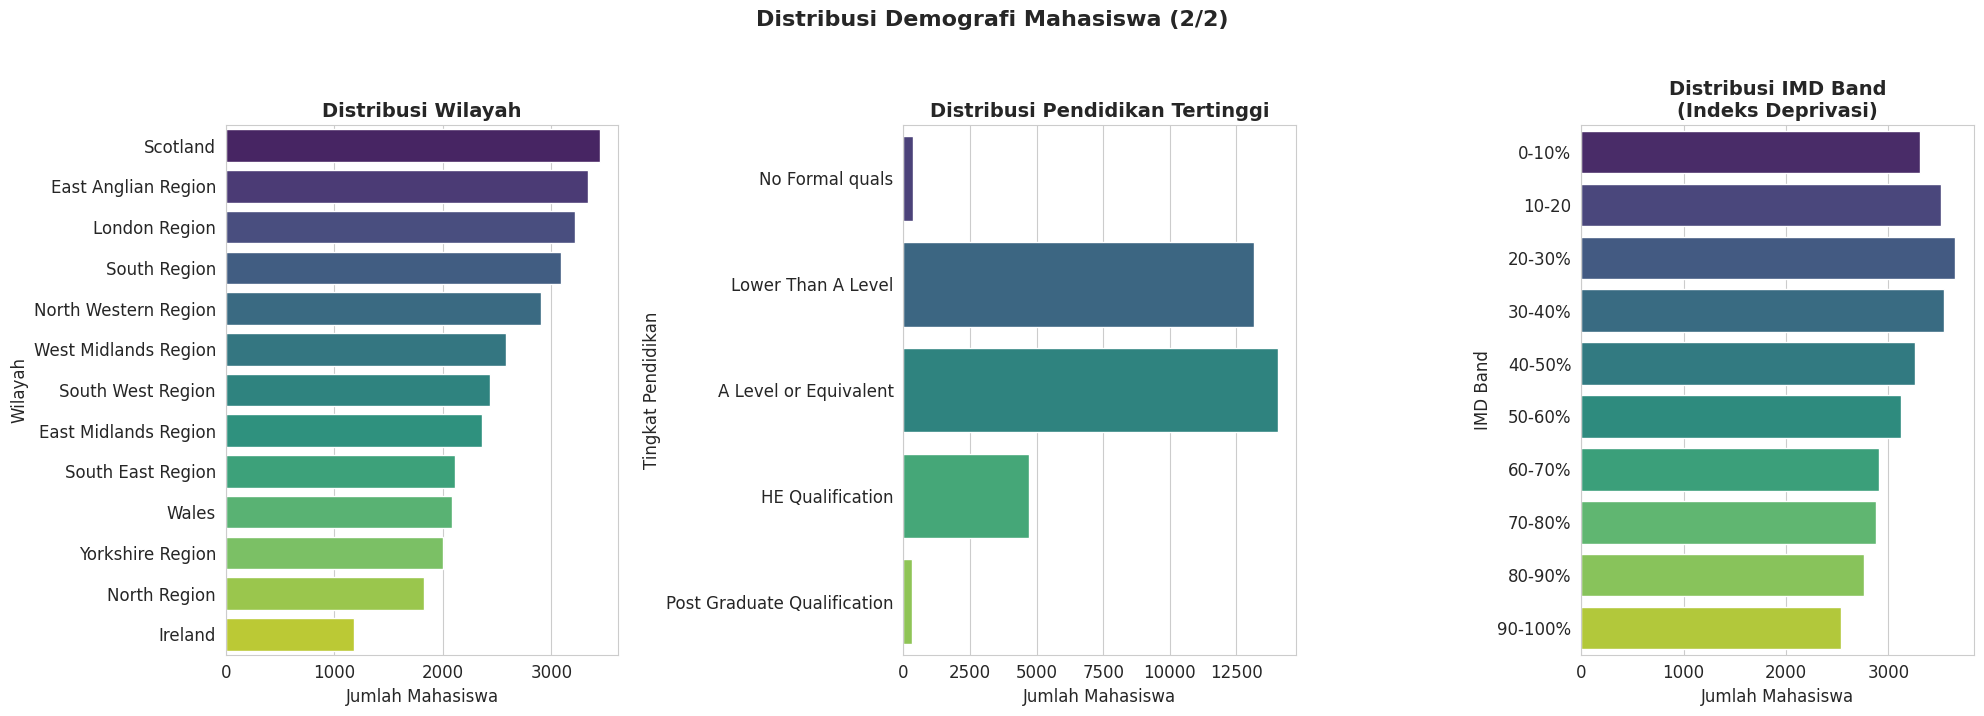

In [20]:
# 3.3 Mahasiswa: Distribusi Demografi (Bagian 2)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Region
region_counts = df_student_info['region'].value_counts()
sns.barplot(y=region_counts.index, x=region_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title('Distribusi Wilayah', fontweight='bold')
axes[0].set_xlabel('Jumlah Mahasiswa')
axes[0].set_ylabel('Wilayah')

# Highest Education
edu_order = ['No Formal quals', 'Lower Than A Level', 'A Level or Equivalent',
             'HE Qualification', 'Post Graduate Qualification']
edu_counts = df_student_info['highest_education'].value_counts().reindex(edu_order).dropna()
sns.barplot(y=edu_counts.index, x=edu_counts.values, ax=axes[1], palette='viridis')
axes[1].set_title('Distribusi Pendidikan Tertinggi', fontweight='bold')
axes[1].set_xlabel('Jumlah Mahasiswa')
axes[1].set_ylabel('Tingkat Pendidikan')

# IMD Band
imd_order = ['0-10%', '10-20', '20-30%', '30-40%', '40-50%',
             '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']
imd_counts = df_student_info['imd_band'].value_counts()
# Reindex hanya band yang ada
available_bands = [b for b in imd_order if b in imd_counts.index]
# Tambahkan band yang tidak ada di urutan tapi ada di data
for b in imd_counts.index:
    if b not in available_bands:
        available_bands.append(b)
imd_counts = imd_counts.reindex(available_bands).dropna()
sns.barplot(y=imd_counts.index, x=imd_counts.values, ax=axes[2], palette='viridis')
axes[2].set_title('Distribusi IMD Band\n(Indeks Deprivasi)', fontweight='bold')
axes[2].set_xlabel('Jumlah Mahasiswa')
axes[2].set_ylabel('IMD Band')

plt.suptitle('Distribusi Demografi Mahasiswa (2/2)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

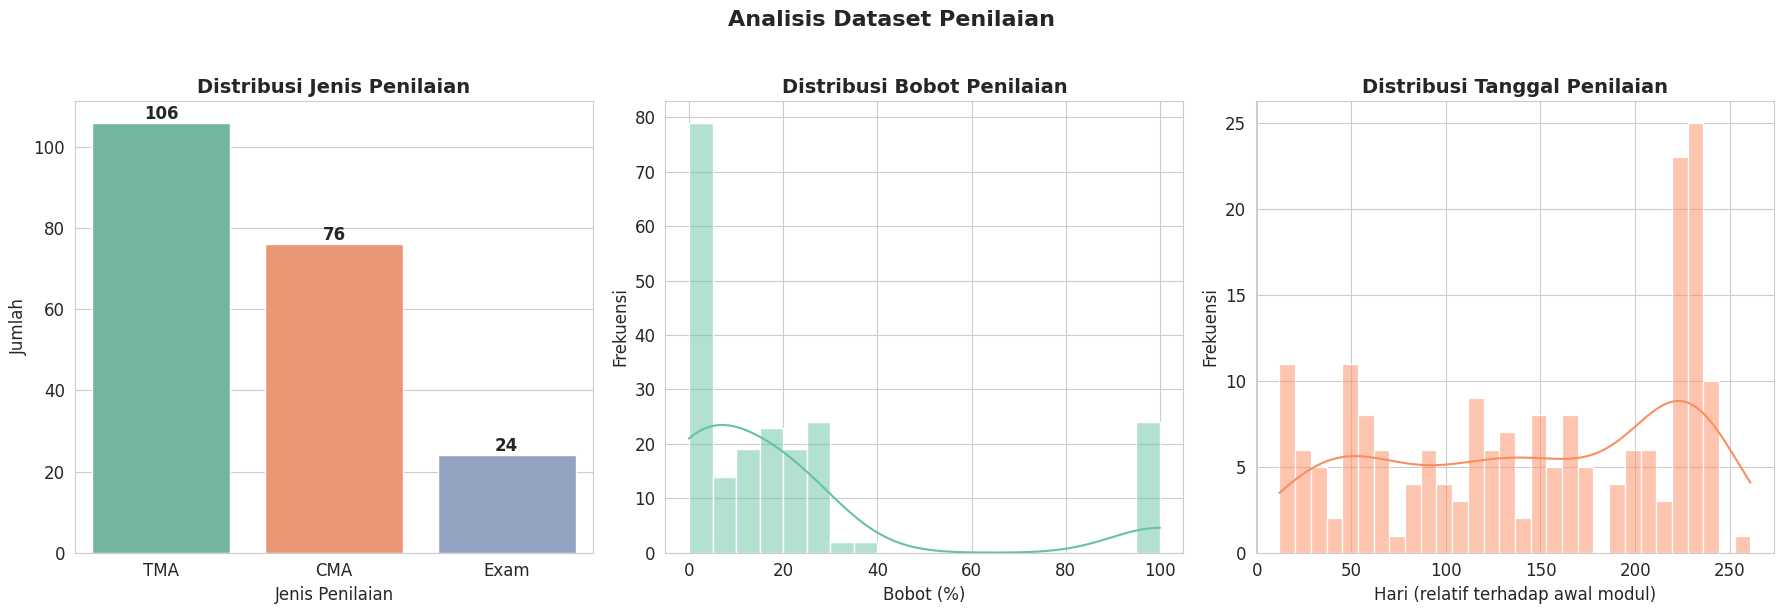

In [21]:
# ============================================================
# 3.4 Penilaian: Distribusi Jenis, Bobot, dan Tanggal
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Jenis Penilaian
assess_type_counts = df_assessments['assessment_type'].value_counts()
sns.barplot(x=assess_type_counts.index, y=assess_type_counts.values, ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Jenis Penilaian', fontweight='bold')
axes[0].set_xlabel('Jenis Penilaian')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(assess_type_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Distribusi Bobot
sns.histplot(df_assessments['weight'].dropna(), bins=20, ax=axes[1], color='#66c2a5', kde=True)
axes[1].set_title('Distribusi Bobot Penilaian', fontweight='bold')
axes[1].set_xlabel('Bobot (%)')
axes[1].set_ylabel('Frekuensi')

# Distribusi Tanggal Penilaian
sns.histplot(df_assessments['date'].dropna(), bins=30, ax=axes[2], color='#fc8d62', kde=True)
axes[2].set_title('Distribusi Tanggal Penilaian', fontweight='bold')
axes[2].set_xlabel('Hari (relatif terhadap awal modul)')
axes[2].set_ylabel('Frekuensi')

plt.suptitle('Analisis Dataset Penilaian', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

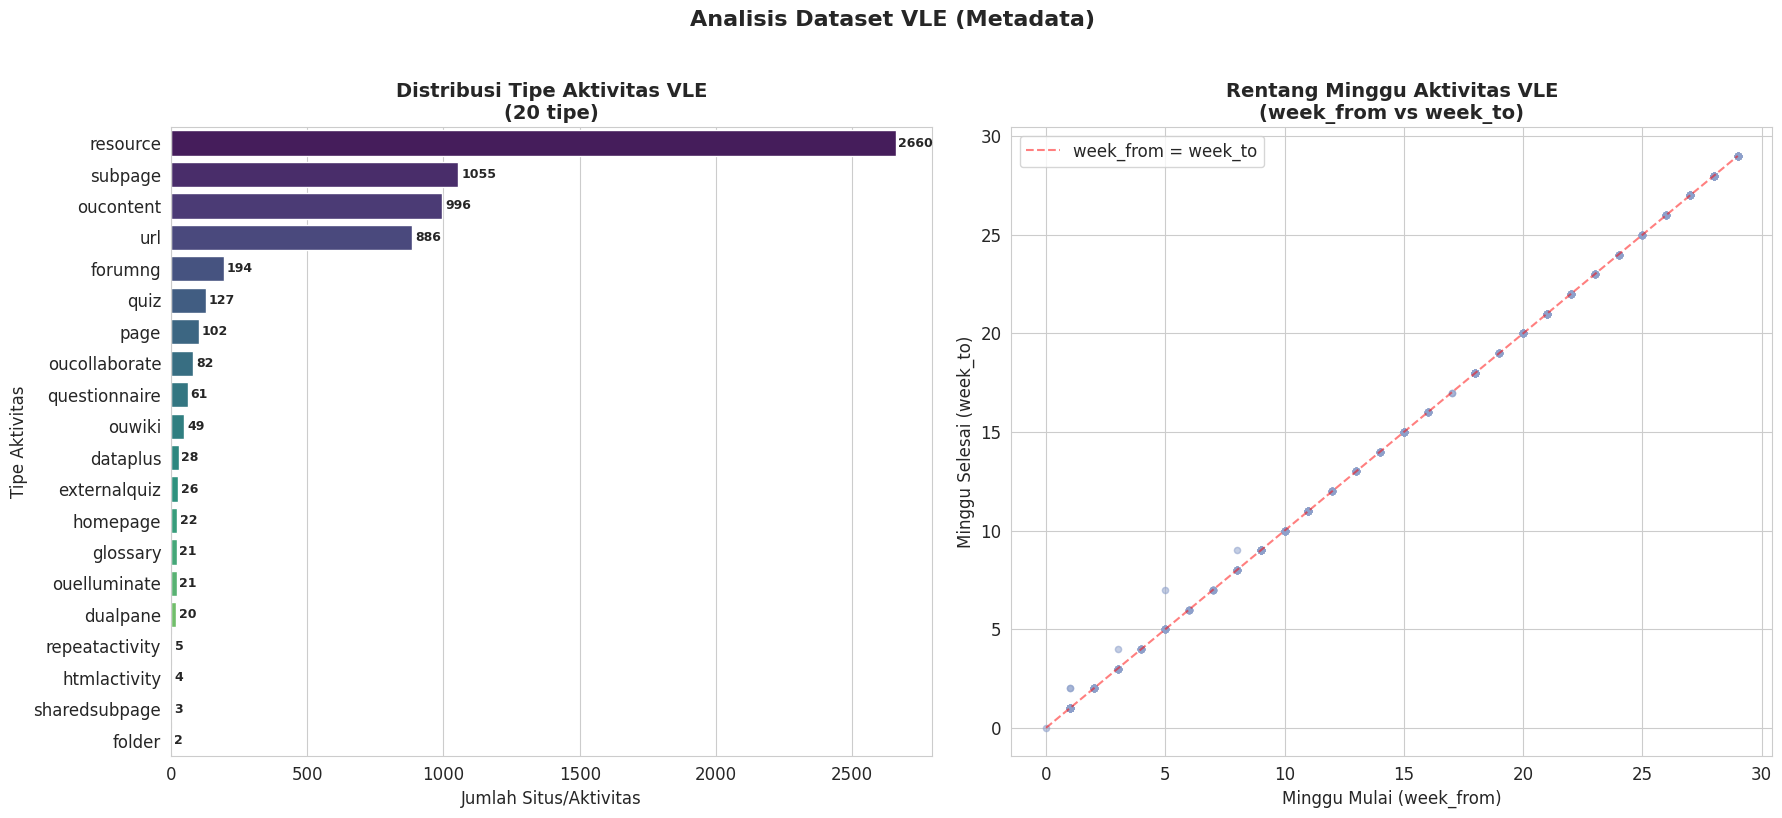

Daftar Lengkap Tipe Aktivitas VLE:
   1. resource: 2,660 situs
   2. subpage: 1,055 situs
   3. oucontent: 996 situs
   4. url: 886 situs
   5. forumng: 194 situs
   6. quiz: 127 situs
   7. page: 102 situs
   8. oucollaborate: 82 situs
   9. questionnaire: 61 situs
  10. ouwiki: 49 situs
  11. dataplus: 28 situs
  12. externalquiz: 26 situs
  13. homepage: 22 situs
  14. glossary: 21 situs
  15. ouelluminate: 21 situs
  16. dualpane: 20 situs
  17. repeatactivity: 5 situs
  18. htmlactivity: 4 situs
  19. sharedsubpage: 3 situs
  20. folder: 2 situs


In [22]:
# 3.5 VLE: Distribusi Tipe Aktivitas & Rentang Minggu

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Tipe Aktivitas VLE
activity_counts = df_vle['activity_type'].value_counts()
sns.barplot(y=activity_counts.index, x=activity_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title(f'Distribusi Tipe Aktivitas VLE\n({len(activity_counts)} tipe)', fontweight='bold')
axes[0].set_xlabel('Jumlah Situs/Aktivitas')
axes[0].set_ylabel('Tipe Aktivitas')
for i, v in enumerate(activity_counts.values):
    axes[0].text(v + 10, i, str(v), va='center', fontweight='bold', fontsize=9)

# Week From/To Range
vle_week = df_vle[['week_from', 'week_to']].dropna()
axes[1].scatter(vle_week['week_from'], vle_week['week_to'], alpha=0.3, s=20, color='#8da0cb')
axes[1].set_title('Rentang Minggu Aktivitas VLE\n(week_from vs week_to)', fontweight='bold')
axes[1].set_xlabel('Minggu Mulai (week_from)')
axes[1].set_ylabel('Minggu Selesai (week_to)')
# Tambahkan garis diagonal
max_week = max(vle_week['week_from'].max(), vle_week['week_to'].max())
axes[1].plot([0, max_week], [0, max_week], 'r--', alpha=0.5, label='week_from = week_to')
axes[1].legend()

plt.suptitle('Analisis Dataset VLE (Metadata)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Daftar Lengkap Tipe Aktivitas VLE:")
for i, (act, count) in enumerate(activity_counts.items(), 1):
    print(f"  {i:2d}. {act}: {count:,} situs")

### 📝 Temuan Analisis Univariat

**Kursus:**
- Terdapat 7 modul unik dengan total 22 kombinasi modul-presentasi.
- Durasi modul bervariasi (biasanya 234-269 hari).

**Mahasiswa:**
- Distribusi gender relatif seimbang, sedikit lebih banyak wanita.
- Mayoritas mahasiswa berada di kelompok umur 0-35 tahun.
- Proporsi **Withdrawn** (berhenti) dan **Fail** (gagal) cukup signifikan.
- Tingkat disabilitas relatif rendah (sekitar 10%).
- A Level merupakan pendidikan tertinggi paling umum.

**Penilaian:**
- TMA (Tutor Marked Assessment) paling banyak, diikuti CMA dan Exam.
- Bobot penilaian bervariasi, dengan konsentrasi pada bobot rendah.

**VLE:**
- Terdapat ~20 tipe aktivitas berbeda.
- `oucontent`, `forumng`, dan `subpage` adalah tipe paling umum.

---
## 🔗 Section 4: Analisis Bivariat & Lintas Dataset

Pada bagian ini kita akan mengeksplorasi hubungan antar variabel dan antar dataset:
- Bagaimana demografi mempengaruhi hasil akhir?
- Apakah skor penilaian berbeda antara kelompok mahasiswa?
- Bagaimana hubungan VLE engagement dengan keberhasilan?

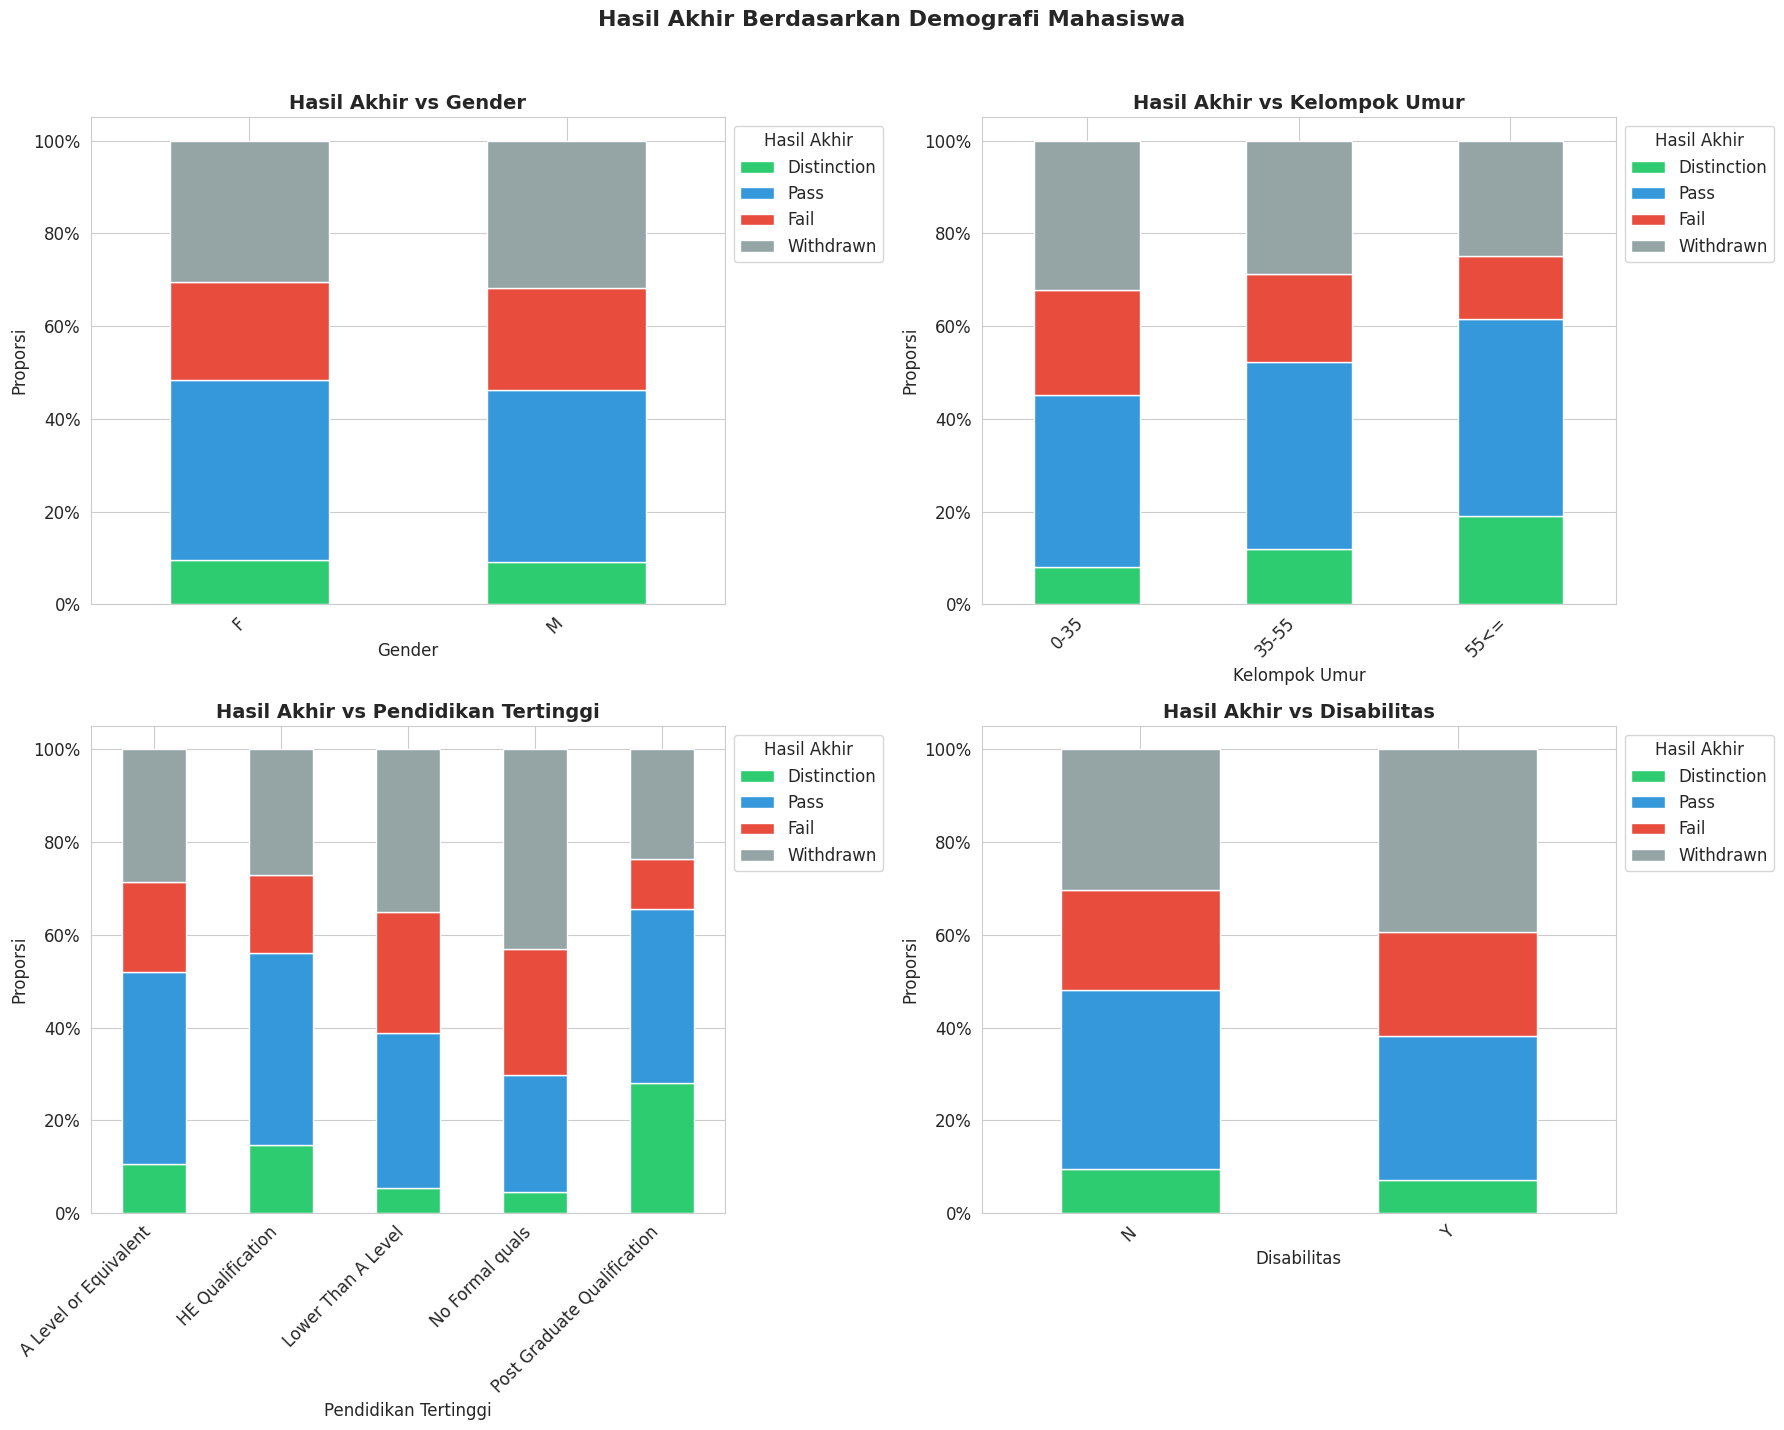

Crosstab: Gender vs Hasil Akhir (jumlah absolut)


final_result,Distinction,Fail,Pass,Withdrawn,Total
gender,,,,,
F,1394,3103,5735,4486,14718
M,1630,3949,6626,5670,17875
Total,3024,7052,12361,10156,32593


Crosstab: Gender vs Hasil Akhir (proporsi baris)


final_result,Distinction,Fail,Pass,Withdrawn
gender,,,,
F,0.095,0.211,0.390,0.305
M,0.091,0.221,0.371,0.317


In [23]:
# 4.1 Hasil Akhir vs Gender, Umur, Pendidikan (Crosstab + Stacked Bar)

result_order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
colors_result = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']

demographic_vars = {
    'gender': 'Gender',
    'age_band': 'Kelompok Umur',
    'highest_education': 'Pendidikan Tertinggi',
    'disability': 'Disabilitas'
}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, (col, label) in enumerate(demographic_vars.items()):
    ax = axes[idx]
    ct = pd.crosstab(df_student_info[col], df_student_info['final_result'], normalize='index')
    ct = ct.reindex(columns=result_order, fill_value=0)
    ct.plot(kind='bar', stacked=True, ax=ax, color=colors_result, edgecolor='white')
    ax.set_title(f'Hasil Akhir vs {label}', fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Proporsi')
    ax.legend(title='Hasil Akhir', bbox_to_anchor=(1.0, 1.0))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.suptitle('Hasil Akhir Berdasarkan Demografi Mahasiswa',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Tampilkan crosstab detail untuk gender
print("Crosstab: Gender vs Hasil Akhir (jumlah absolut)")
display(pd.crosstab(df_student_info['gender'], df_student_info['final_result'],
                    margins=True, margins_name='Total'))

print("Crosstab: Gender vs Hasil Akhir (proporsi baris)")
display(pd.crosstab(df_student_info['gender'], df_student_info['final_result'],
                    normalize='index').round(3))

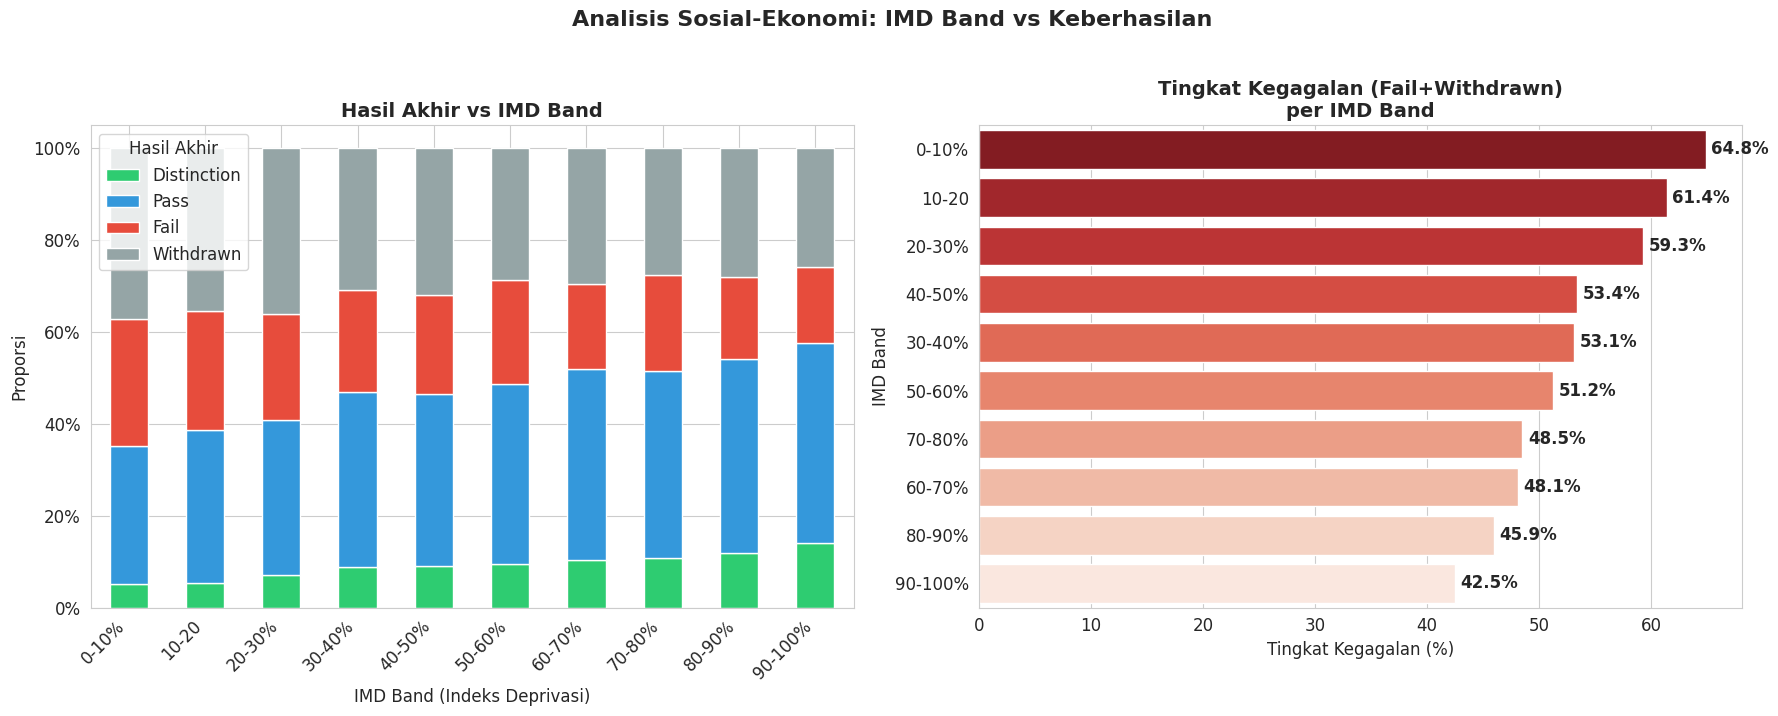

In [24]:
# 4.2 Hasil Akhir vs IMD Band (Sosial-Ekonomi)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Stacked bar chart
ct_imd = pd.crosstab(df_student_info['imd_band'], df_student_info['final_result'],
                      normalize='index')
ct_imd = ct_imd.reindex(columns=result_order, fill_value=0)

ct_imd.plot(kind='bar', stacked=True, ax=axes[0], color=colors_result, edgecolor='white')
axes[0].set_title('Hasil Akhir vs IMD Band', fontweight='bold')
axes[0].set_xlabel('IMD Band (Indeks Deprivasi)')
axes[0].set_ylabel('Proporsi')
axes[0].legend(title='Hasil Akhir')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# Tingkat kegagalan (Fail + Withdrawn) per IMD Band
ct_imd_abs = pd.crosstab(df_student_info['imd_band'], df_student_info['final_result'])
ct_imd_abs = ct_imd_abs.reindex(columns=result_order, fill_value=0)
failure_rate = (ct_imd_abs['Fail'] + ct_imd_abs['Withdrawn']) / ct_imd_abs.sum(axis=1) * 100
failure_rate = failure_rate.sort_values(ascending=False)

sns.barplot(x=failure_rate.values, y=failure_rate.index, ax=axes[1], palette='Reds_r')
axes[1].set_title('Tingkat Kegagalan (Fail+Withdrawn)\nper IMD Band', fontweight='bold')
axes[1].set_xlabel('Tingkat Kegagalan (%)')
axes[1].set_ylabel('IMD Band')
for i, v in enumerate(failure_rate.values):
    axes[1].text(v + 0.5, i, f"{v:.1f}%", va='center', fontweight='bold')

plt.suptitle('Analisis Sosial-Ekonomi: IMD Band vs Keberhasilan',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

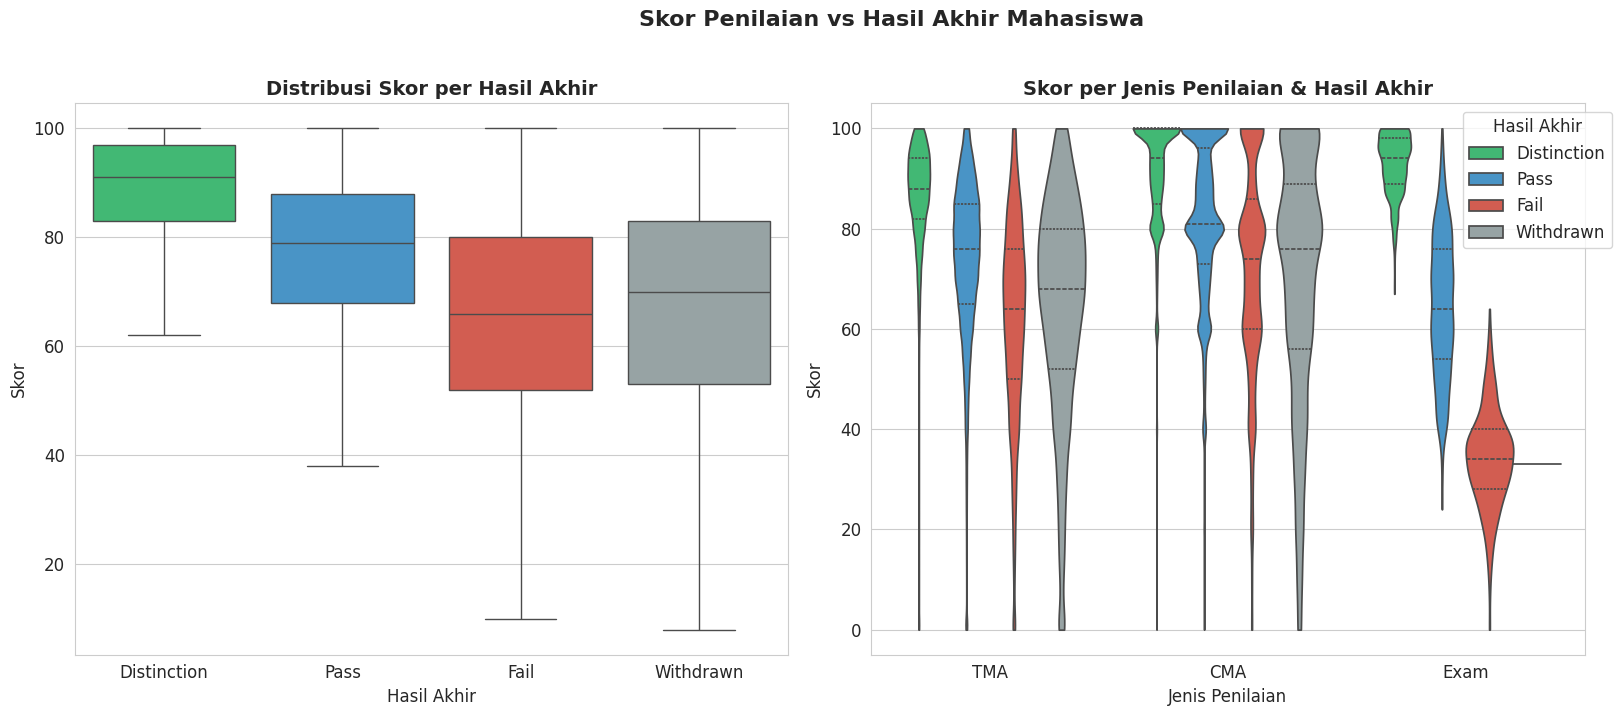

Rata-rata Skor per Hasil Akhir:


,count,mean,std,min,25%,50%,75%,max
final_result,,,,,,,,
Distinction,26330.0,88.68,11.44,0.0,83.0,91.0,97.0,100.0
Pass,105987.0,76.77,16.46,0.0,68.0,79.0,88.0,100.0
Fail,28399.0,64.69,21.43,0.0,52.0,66.0,80.0,100.0
Withdrawn,13023.0,66.08,23.18,0.0,53.0,70.0,83.0,100.0


In [25]:
# 4.3 Skor Penilaian vs Hasil Akhir

# Gabungkan studentAssessment dengan assessments & studentInfo
df_sa_merged = df_student_assessment.merge(
    df_assessments[['id_assessment', 'code_module', 'code_presentation', 'assessment_type']],
    on='id_assessment', how='left'
)
df_sa_merged = df_sa_merged.merge(
    df_student_info[['id_student', 'code_module', 'code_presentation', 'final_result', 'imd_band']],
    on=['id_student', 'code_module', 'code_presentation'], how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Boxplot skor vs hasil akhir
sns.boxplot(data=df_sa_merged, x='final_result', y='score',
            order=result_order, palette=colors_result, ax=axes[0],
            showfliers=False)
axes[0].set_title('Distribusi Skor per Hasil Akhir', fontweight='bold')
axes[0].set_xlabel('Hasil Akhir')
axes[0].set_ylabel('Skor')

# Violin plot skor vs jenis penilaian & hasil akhir
sns.violinplot(data=df_sa_merged, x='assessment_type', y='score',
               hue='final_result', hue_order=result_order,
               palette=colors_result, ax=axes[1], cut=0, inner='quartile')
axes[1].set_title('Skor per Jenis Penilaian & Hasil Akhir', fontweight='bold')
axes[1].set_xlabel('Jenis Penilaian')
axes[1].set_ylabel('Skor')
axes[1].legend(title='Hasil Akhir', bbox_to_anchor=(1.05, 1))

plt.suptitle('Skor Penilaian vs Hasil Akhir Mahasiswa',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Statistik rata-rata skor per hasil akhir
print("Rata-rata Skor per Hasil Akhir:")
display(df_sa_merged.groupby('final_result')['score'].describe().round(2).reindex(result_order))

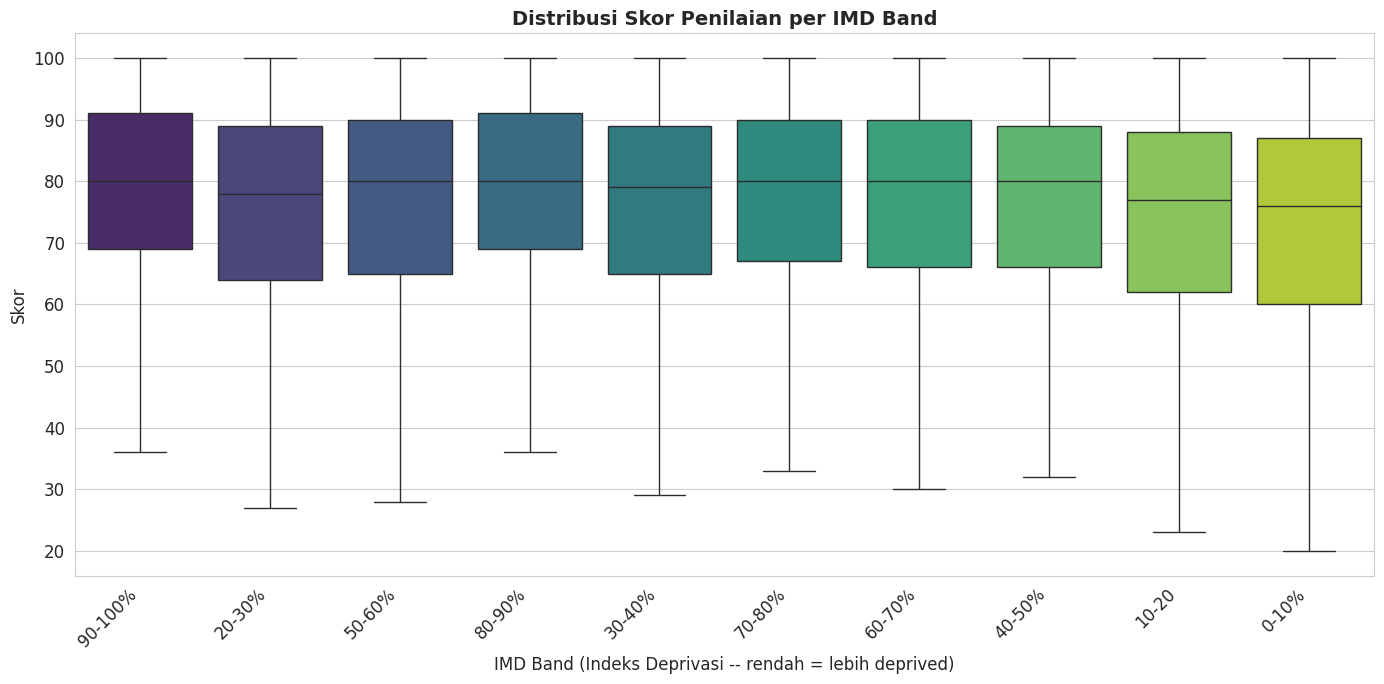

In [26]:
# 4.4 Skor Penilaian vs IMD Band (Sosial-Ekonomi)

fig, ax = plt.subplots(figsize=(14, 7))

# Median skor per IMD Band
score_by_imd = df_sa_merged.groupby('imd_band')['score'].agg(['mean', 'median', 'std']).reset_index()
score_by_imd = score_by_imd.dropna()
score_by_imd = score_by_imd.sort_values('median', ascending=True)

sns.boxplot(data=df_sa_merged, x='imd_band', y='score', palette='viridis',
            ax=ax, showfliers=False)
ax.set_title('Distribusi Skor Penilaian per IMD Band', fontweight='bold')
ax.set_xlabel('IMD Band (Indeks Deprivasi -- rendah = lebih deprived)')
ax.set_ylabel('Skor')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

[LOADING] Menghitung total klik VLE per mahasiswa...


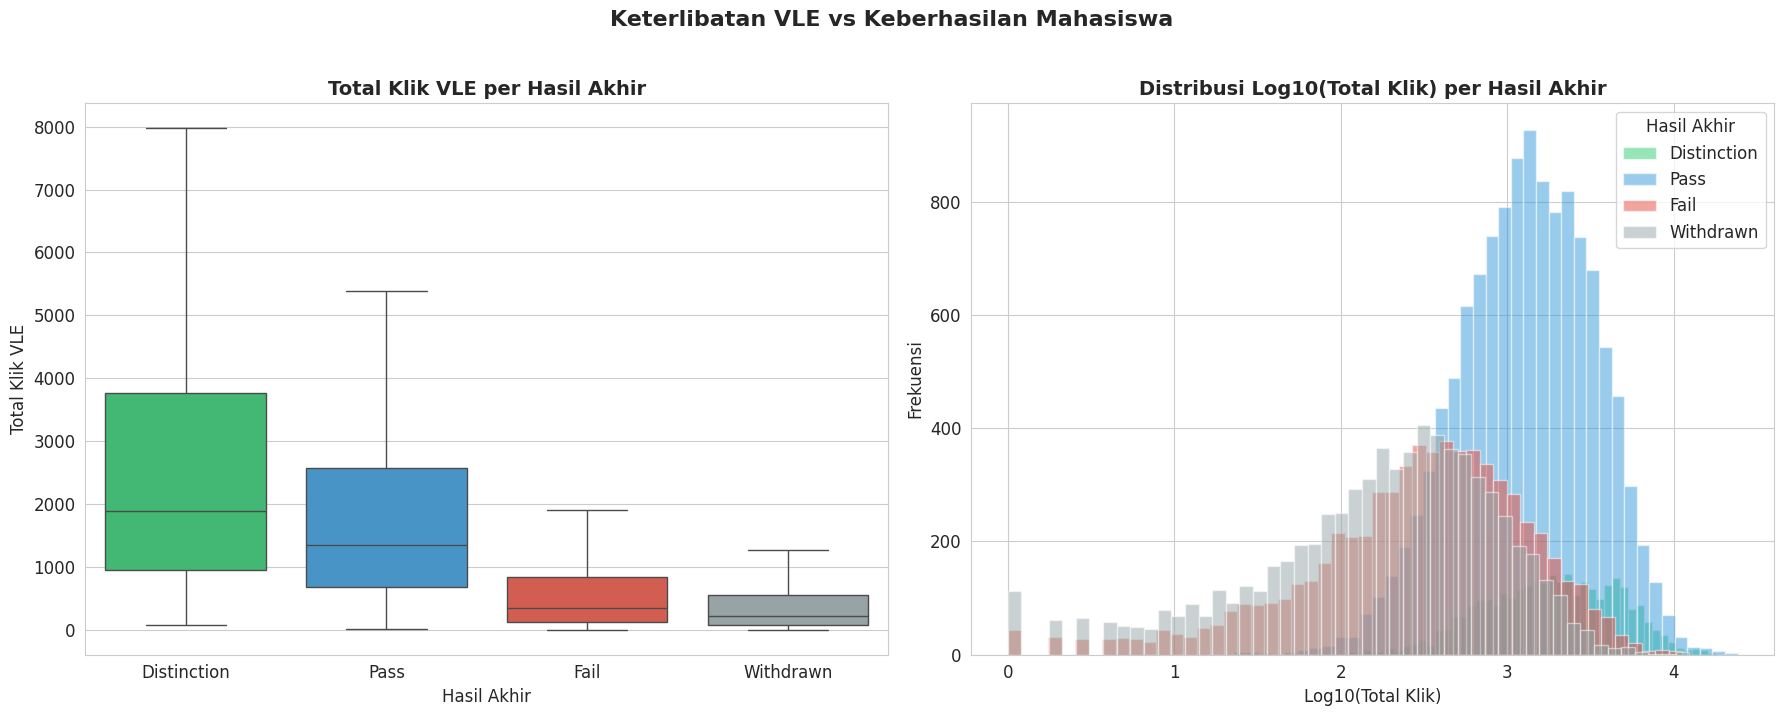

Statistik Total Klik per Hasil Akhir:


,count,mean,std,min,25%,50%,75%,max
final_result,,,,,,,,
Distinction,3024.0,2666.8,2410.0,70.0,942.0,1896.0,3765.0,18039.0
Pass,12358.0,1922.3,1852.8,4.0,683.0,1343.0,2568.0,24139.0
Fail,6678.0,688.4,980.9,1.0,124.0,353.0,838.8,11250.0
Withdrawn,7168.0,444.8,683.1,1.0,70.0,221.5,551.0,12401.0


CPU times: user 2.4 s, sys: 72.5 ms, total: 2.47 s
Wall time: 2.59 s


In [27]:
%%time
# 4.5 VLE Clicks vs Hasil Akhir

# Hitung total klik VLE per mahasiswa per modul
print("[LOADING] Menghitung total klik VLE per mahasiswa...")
vle_clicks_per_student = df_student_vle.groupby(
    ['code_module', 'code_presentation', 'id_student']
)['sum_click'].sum().reset_index()
vle_clicks_per_student.columns = ['code_module', 'code_presentation', 'id_student', 'total_clicks']

# Gabungkan dengan hasil akhir
vle_result = vle_clicks_per_student.merge(
    df_student_info[['id_student', 'code_module', 'code_presentation', 'final_result']],
    on=['id_student', 'code_module', 'code_presentation'], how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Boxplot klik vs hasil akhir
sns.boxplot(data=vle_result, x='final_result', y='total_clicks',
            order=result_order, palette=colors_result, ax=axes[0],
            showfliers=False)
axes[0].set_title('Total Klik VLE per Hasil Akhir', fontweight='bold')
axes[0].set_xlabel('Hasil Akhir')
axes[0].set_ylabel('Total Klik VLE')

# Distribusi klik (log scale) per hasil
for res, color in zip(result_order, colors_result):
    data = vle_result[vle_result['final_result'] == res]['total_clicks']
    data = data[data > 0]  # Log tidak bisa 0
    axes[1].hist(np.log10(data), bins=50, alpha=0.5, label=res, color=color)

axes[1].set_title('Distribusi Log10(Total Klik) per Hasil Akhir', fontweight='bold')
axes[1].set_xlabel('Log10(Total Klik)')
axes[1].set_ylabel('Frekuensi')
axes[1].legend(title='Hasil Akhir')

plt.suptitle('Keterlibatan VLE vs Keberhasilan Mahasiswa',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Statistik Total Klik per Hasil Akhir:")
display(vle_result.groupby('final_result')['total_clicks'].describe().round(1).reindex(result_order))

[LOADING] Menggabungkan data VLE dengan metadata aktivitas...


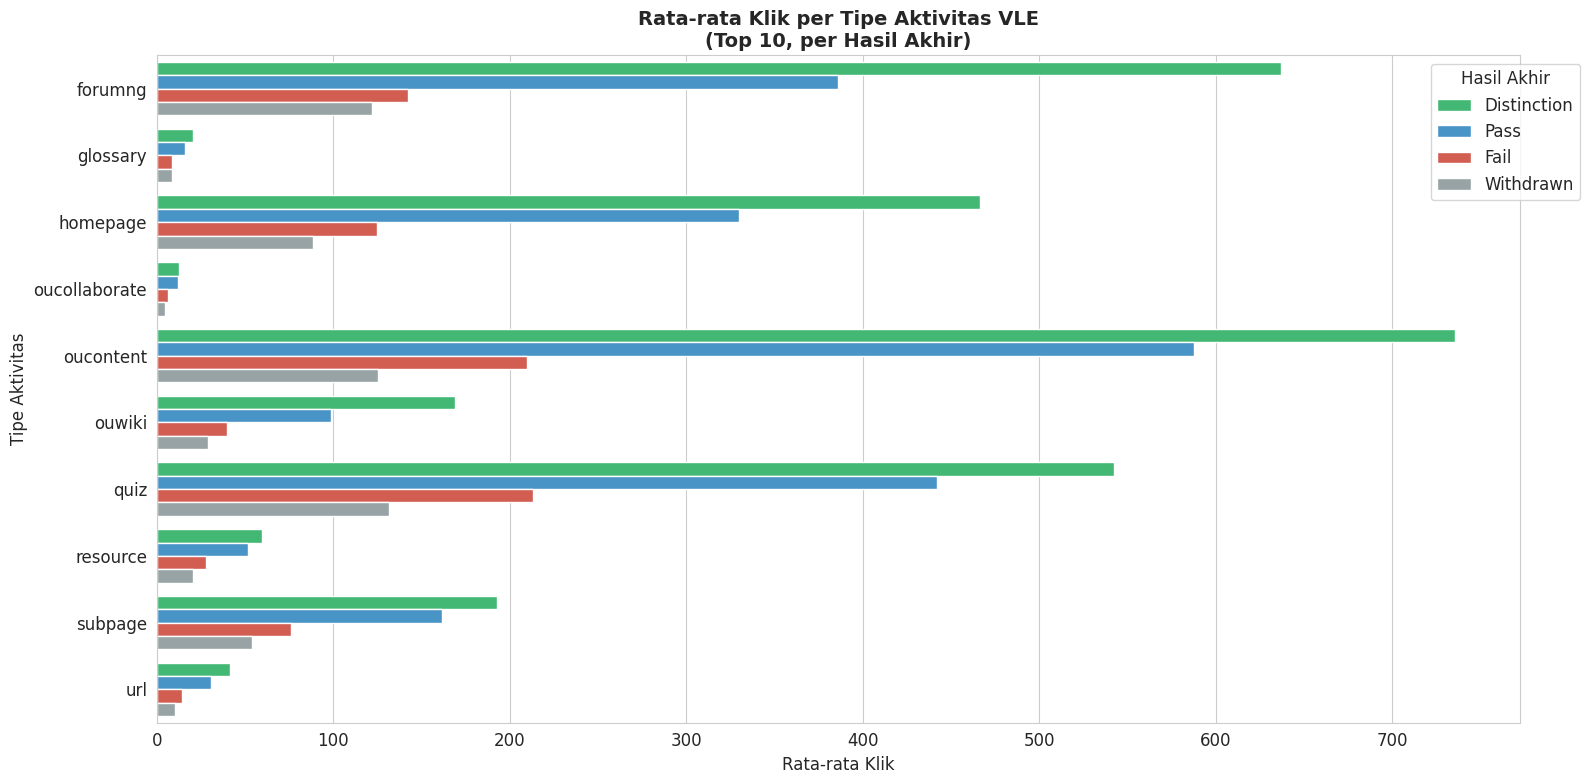

CPU times: user 6.21 s, sys: 638 ms, total: 6.85 s
Wall time: 6.89 s


47057

In [28]:
%%time
# 4.6 Tipe Aktivitas VLE per Kelompok Hasil Akhir

# Gabungkan studentVle dengan vle metadata dan studentInfo
print("[LOADING] Menggabungkan data VLE dengan metadata aktivitas...")
df_svle_type = df_student_vle.merge(
    df_vle[['id_site', 'code_module', 'code_presentation', 'activity_type']],
    on=['id_site', 'code_module', 'code_presentation'], how='left'
)

# Hitung klik per tipe aktivitas per mahasiswa
clicks_by_type_student = df_svle_type.groupby(
    ['code_module', 'code_presentation', 'id_student', 'activity_type']
)['sum_click'].sum().reset_index()

# Gabungkan dengan hasil akhir
clicks_by_type_student = clicks_by_type_student.merge(
    df_student_info[['id_student', 'code_module', 'code_presentation', 'final_result']],
    on=['id_student', 'code_module', 'code_presentation'], how='left'
)

# Rata-rata klik per tipe aktivitas per hasil akhir
avg_clicks_type_result = clicks_by_type_student.groupby(
    ['activity_type', 'final_result']
)['sum_click'].mean().reset_index()

# Top 10 tipe aktivitas
top_activities = clicks_by_type_student.groupby('activity_type')['sum_click'].sum()\
    .nlargest(10).index.tolist()

plot_data = avg_clicks_type_result[avg_clicks_type_result['activity_type'].isin(top_activities)]

fig, ax = plt.subplots(figsize=(16, 8))
sns.barplot(data=plot_data, y='activity_type', x='sum_click',
            hue='final_result', hue_order=result_order,
            palette=colors_result, ax=ax)
ax.set_title('Rata-rata Klik per Tipe Aktivitas VLE\n(Top 10, per Hasil Akhir)', fontweight='bold')
ax.set_xlabel('Rata-rata Klik')
ax.set_ylabel('Tipe Aktivitas')
ax.legend(title='Hasil Akhir', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

# Bersihkan memori
del df_svle_type
gc.collect()

### 📝 Temuan Analisis Bivariat

**Demografi vs Hasil Akhir:**
- Gender tidak menunjukkan perbedaan besar dalam proporsi kelulusan.
- Mahasiswa kelompok umur lebih tua (55<=) cenderung memiliki tingkat kelulusan lebih baik.
- Tingkat pendidikan sebelumnya berkorelasi kuat dengan keberhasilan.
- Mahasiswa penyandang disabilitas menunjukkan sedikit perbedaan dalam hasil.

**Sosial-Ekonomi (IMD Band):**
- Terdapat pola bahwa mahasiswa dari daerah dengan deprivasi tinggi (IMD rendah) memiliki tingkat kegagalan yang lebih tinggi.

**Skor Penilaian:**
- Mahasiswa dengan Distinction memiliki skor rata-rata jauh lebih tinggi.
- Mahasiswa Withdrawn sering memiliki skor yang lebih rendah sebelum berhenti.

**VLE Engagement:**
- **Temuan kunci:** Mahasiswa yang berhasil (Pass/Distinction) memiliki total klik VLE yang jauh lebih banyak.
- Mahasiswa Withdrawn memiliki klik paling sedikit — indikasi disengagement awal.

---
## 🚶 Section 5: Analisis Perjalanan Mahasiswa

Pada bagian ini kita akan menganalisis perjalanan temporal mahasiswa:
- Kapan mahasiswa mendaftar dan membatalkan registrasi?
- Pada titik mana mahasiswa melakukan withdrawal?
- Bagaimana pola engagement VLE berubah dari waktu ke waktu?
- Pola pengumpulan tugas (tepat waktu vs terlambat)

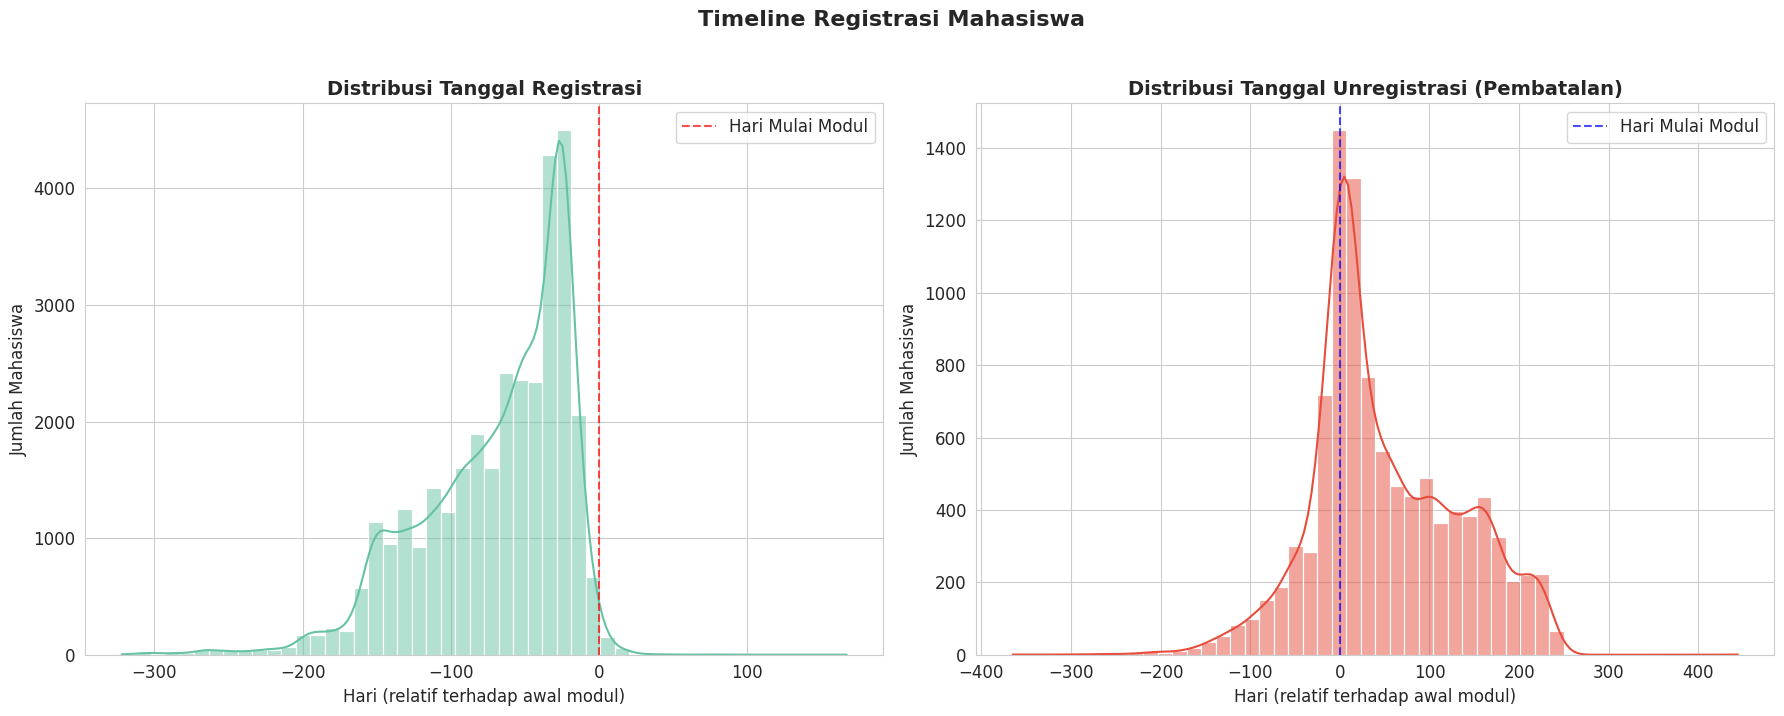

Statistik Registrasi:
  - Total mahasiswa terdaftar: 32,593
  - Yang membatalkan registrasi: 10,072 (30.9%)
  - Yang tetap terdaftar: 22,521 (69.1%)
  - Registrasi sebelum modul dimulai: 32,312
  - Registrasi setelah modul dimulai: 236


In [29]:
# 5.1 Analisis Timeline Registrasi

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Distribusi tanggal registrasi
reg_dates = df_student_reg['date_registration'].dropna()
sns.histplot(reg_dates, bins=50, ax=axes[0], color='#66c2a5', kde=True)
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Hari Mulai Modul')
axes[0].set_title('Distribusi Tanggal Registrasi', fontweight='bold')
axes[0].set_xlabel('Hari (relatif terhadap awal modul)')
axes[0].set_ylabel('Jumlah Mahasiswa')
axes[0].legend()

# Distribusi tanggal unregistrasi
unreg_dates = df_student_reg['date_unregistration'].dropna()
sns.histplot(unreg_dates, bins=50, ax=axes[1], color='#e74c3c', kde=True)
axes[1].axvline(x=0, color='blue', linestyle='--', alpha=0.7, label='Hari Mulai Modul')
axes[1].set_title('Distribusi Tanggal Unregistrasi (Pembatalan)', fontweight='bold')
axes[1].set_xlabel('Hari (relatif terhadap awal modul)')
axes[1].set_ylabel('Jumlah Mahasiswa')
axes[1].legend()

plt.suptitle('Timeline Registrasi Mahasiswa', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Statistik
total_students = len(df_student_reg)
unregistered = df_student_reg['date_unregistration'].notna().sum()
print(f"Statistik Registrasi:")
print(f"  - Total mahasiswa terdaftar: {total_students:,}")
print(f"  - Yang membatalkan registrasi: {unregistered:,} ({unregistered/total_students*100:.1f}%)")
print(f"  - Yang tetap terdaftar: {total_students - unregistered:,} ({(total_students-unregistered)/total_students*100:.1f}%)")
print(f"  - Registrasi sebelum modul dimulai: {(reg_dates < 0).sum():,}")
print(f"  - Registrasi setelah modul dimulai: {(reg_dates >= 0).sum():,}")

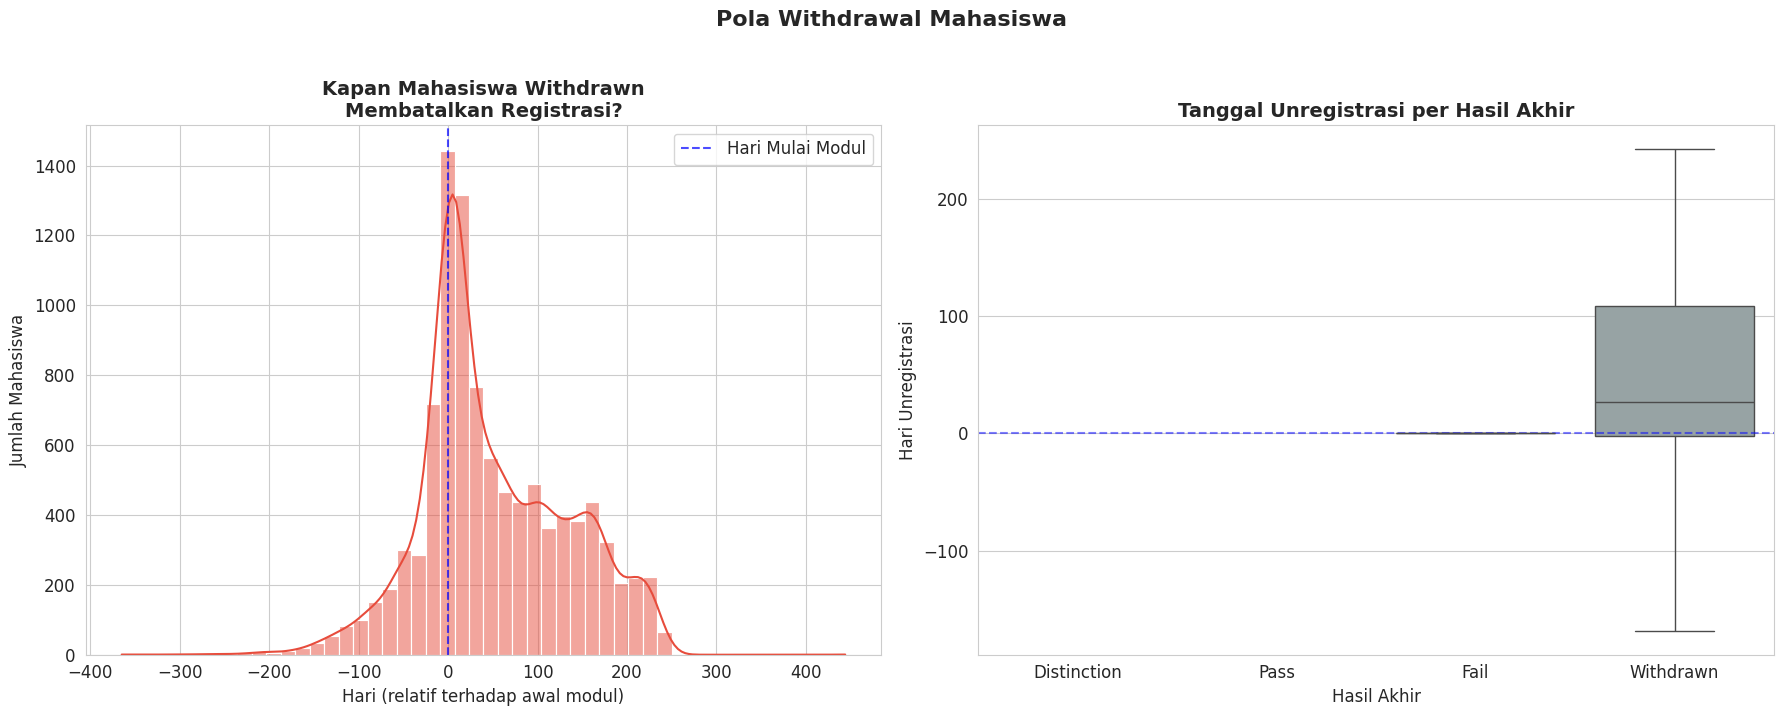

Statistik Withdrawal:
  - Total mahasiswa Withdrawn: 10,156
  - Median hari unregistrasi: 27
  - Withdrawal sebelum modul dimulai: 2,676
  - Withdrawal dalam 30 hari pertama: 2,443
  - Withdrawal setelah 30 hari: 4,944


In [30]:
# 5.2 Pola Withdrawal: Kapan Mahasiswa Berhenti?

# Gabungkan registrasi dengan info mahasiswa
df_reg_info = df_student_reg.merge(
    df_student_info[['id_student', 'code_module', 'code_presentation', 'final_result']],
    on=['id_student', 'code_module', 'code_presentation'], how='left'
)

# Fokus pada mahasiswa Withdrawn
withdrawn = df_reg_info[df_reg_info['final_result'] == 'Withdrawn'].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Kapan mahasiswa withdrawn melakukan unregistrasi
withdrawn_dates = withdrawn['date_unregistration'].dropna()
sns.histplot(withdrawn_dates, bins=50, ax=axes[0], color='#e74c3c', kde=True)
axes[0].axvline(x=0, color='blue', linestyle='--', alpha=0.7, label='Hari Mulai Modul')
axes[0].set_title('Kapan Mahasiswa Withdrawn\nMembatalkan Registrasi?', fontweight='bold')
axes[0].set_xlabel('Hari (relatif terhadap awal modul)')
axes[0].set_ylabel('Jumlah Mahasiswa')
axes[0].legend()

# Perbandingan tanggal unregistrasi per hasil akhir
unreg_by_result = df_reg_info[df_reg_info['date_unregistration'].notna()]
sns.boxplot(data=unreg_by_result, x='final_result', y='date_unregistration',
            order=result_order, palette=colors_result, ax=axes[1],
            showfliers=False)
axes[1].set_title('Tanggal Unregistrasi per Hasil Akhir', fontweight='bold')
axes[1].set_xlabel('Hasil Akhir')
axes[1].set_ylabel('Hari Unregistrasi')
axes[1].axhline(y=0, color='blue', linestyle='--', alpha=0.5)

plt.suptitle('Pola Withdrawal Mahasiswa', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Statistik withdrawal
print("Statistik Withdrawal:")
print(f"  - Total mahasiswa Withdrawn: {len(withdrawn):,}")
print(f"  - Median hari unregistrasi: {withdrawn_dates.median():.0f}")
print(f"  - Withdrawal sebelum modul dimulai: {(withdrawn_dates < 0).sum():,}")
print(f"  - Withdrawal dalam 30 hari pertama: {((withdrawn_dates >= 0) & (withdrawn_dates <= 30)).sum():,}")
print(f"  - Withdrawal setelah 30 hari: {(withdrawn_dates > 30).sum():,}")

[LOADING] Menghitung engagement VLE per minggu per kelompok hasil...


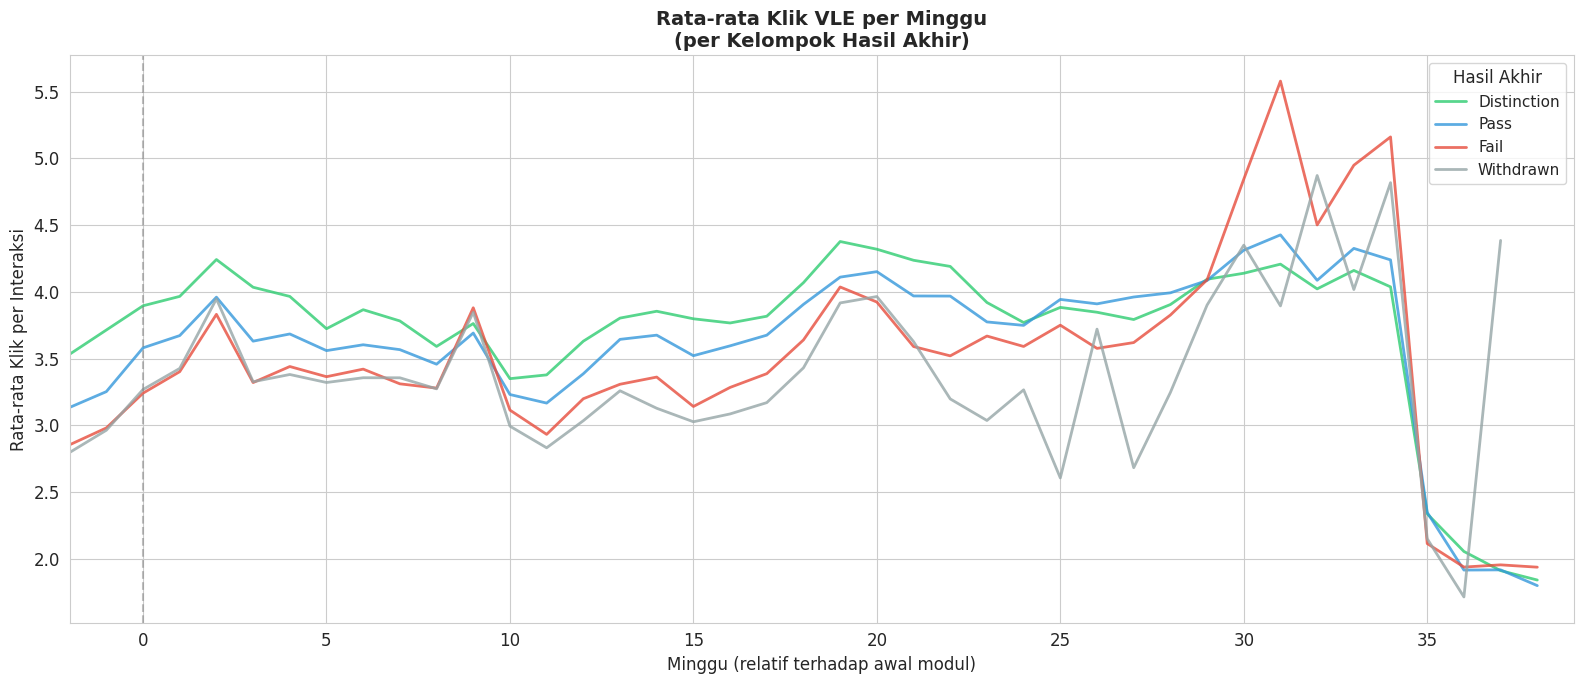

CPU times: user 5.37 s, sys: 856 ms, total: 6.23 s
Wall time: 6.26 s


36783

In [31]:
%%time
# 5.3 VLE Engagement dari Waktu ke Waktu

print("[LOADING] Menghitung engagement VLE per minggu per kelompok hasil...")

# Tambahkan kolom minggu
df_student_vle['week'] = df_student_vle['date'] // 7

# Gabungkan dengan hasil akhir
svle_with_result = df_student_vle.merge(
    df_student_info[['id_student', 'code_module', 'code_presentation', 'final_result']],
    on=['id_student', 'code_module', 'code_presentation'], how='left'
)

# Rata-rata klik per minggu per kelompok hasil
weekly_clicks = svle_with_result.groupby(['week', 'final_result'])['sum_click'].mean().reset_index()

# Filter minggu yang masuk akal (0-39, ~9 bulan)
weekly_clicks = weekly_clicks[(weekly_clicks['week'] >= -2) & (weekly_clicks['week'] <= 39)]

fig, ax = plt.subplots(figsize=(16, 7))

for res, color in zip(result_order, colors_result):
    data = weekly_clicks[weekly_clicks['final_result'] == res]
    ax.plot(data['week'], data['sum_click'], label=res, color=color, linewidth=2, alpha=0.8)

ax.set_title('Rata-rata Klik VLE per Minggu\n(per Kelompok Hasil Akhir)', fontweight='bold')
ax.set_xlabel('Minggu (relatif terhadap awal modul)')
ax.set_ylabel('Rata-rata Klik per Interaksi')
ax.legend(title='Hasil Akhir', fontsize=11)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5, label='Awal Modul')
ax.set_xlim(-2, 39)

plt.tight_layout()
plt.show()

# Bersihkan
del svle_with_result
gc.collect()

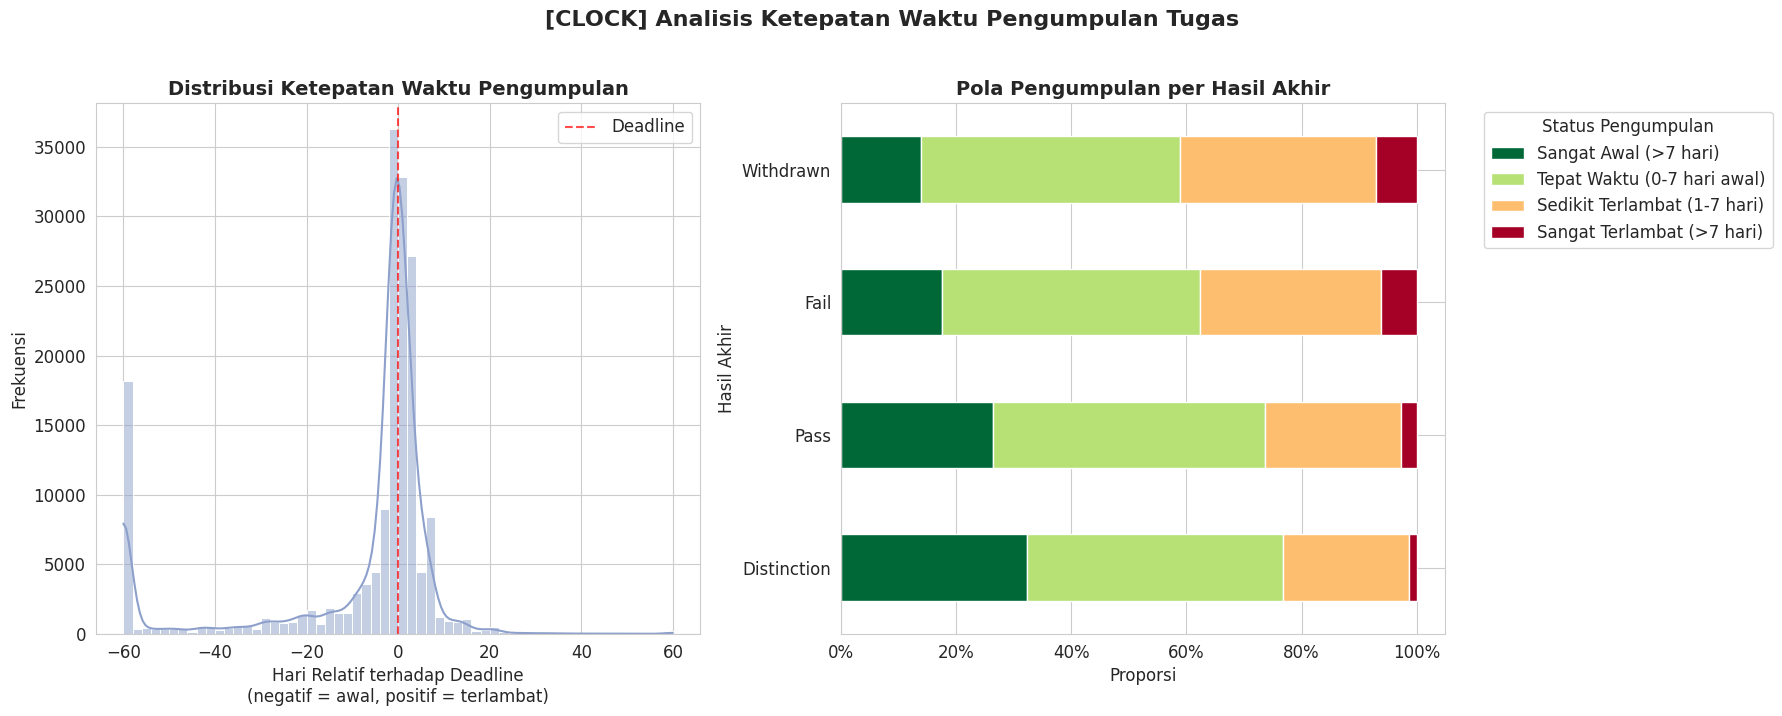

Statistik Ketepatan Waktu:
  - Tepat waktu atau lebih awal: 121,729 (71.2%)
  - Terlambat: 49,318 (28.8%)
  - Median hari (relatif deadline): -1


In [32]:
# 5.4 Pola Pengumpulan Tugas: Tepat Waktu vs Terlambat

# Gabungkan studentAssessment dengan assessments untuk mendapatkan deadline
df_submission = df_student_assessment.merge(
    df_assessments[['id_assessment', 'date', 'assessment_type', 'code_module', 'code_presentation']],
    on='id_assessment', how='left'
)
df_submission = df_submission.merge(
    df_student_info[['id_student', 'code_module', 'code_presentation', 'final_result']],
    on=['id_student', 'code_module', 'code_presentation'], how='left'
)

# Hitung selisih hari (negatif = lebih awal, positif = terlambat)
df_submission['days_early_late'] = df_submission['date_submitted'] - df_submission['date']
df_submission['submission_status'] = pd.cut(
    df_submission['days_early_late'],
    bins=[-np.inf, -7, 0, 7, np.inf],
    labels=['Sangat Awal (>7 hari)', 'Tepat Waktu (0-7 hari awal)', 'Sedikit Terlambat (1-7 hari)', 'Sangat Terlambat (>7 hari)']
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Distribusi selisih hari
early_late = df_submission['days_early_late'].dropna()
early_late_clipped = early_late.clip(-60, 60)  # Clip untuk visualisasi
sns.histplot(early_late_clipped, bins=60, ax=axes[0], color='#8da0cb', kde=True)
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Deadline')
axes[0].set_title('Distribusi Ketepatan Waktu Pengumpulan', fontweight='bold')
axes[0].set_xlabel('Hari Relatif terhadap Deadline\n(negatif = awal, positif = terlambat)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Ketepatan waktu per hasil akhir
ct_timing = pd.crosstab(df_submission['final_result'], df_submission['submission_status'],
                        normalize='index')
ct_timing = ct_timing.reindex(index=result_order)
ct_timing.plot(kind='barh', stacked=True, ax=axes[1], colormap='RdYlGn_r', edgecolor='white')
axes[1].set_title('Pola Pengumpulan per Hasil Akhir', fontweight='bold')
axes[1].set_xlabel('Proporsi')
axes[1].set_ylabel('Hasil Akhir')
axes[1].legend(title='Status Pengumpulan', bbox_to_anchor=(1.05, 1))
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.suptitle('[CLOCK] Analisis Ketepatan Waktu Pengumpulan Tugas',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Statistik Ketepatan Waktu:")
print(f"  - Tepat waktu atau lebih awal: {(early_late <= 0).sum():,} ({(early_late <= 0).mean()*100:.1f}%)")
print(f"  - Terlambat: {(early_late > 0).sum():,} ({(early_late > 0).mean()*100:.1f}%)")
print(f"  - Median hari (relatif deadline): {early_late.median():.0f}")

### 📝 Temuan Analisis Perjalanan Mahasiswa

**Registrasi:**
- Mayoritas mahasiswa mendaftar **sebelum modul dimulai** (tanggal negatif).
- Sebagian signifikan mahasiswa membatalkan registrasi (unregister).

**Pola Withdrawal:**
- Withdrawal terjadi di sepanjang durasi modul, tetapi ada konsentrasi di **awal-awal modul**.
- Beberapa mahasiswa bahkan withdrawal sebelum modul dimulai.

**VLE Engagement Temporal:**
- Mahasiswa Distinction dan Pass menunjukkan **engagement yang konsisten** sepanjang modul.
- Mahasiswa Withdrawn menunjukkan **penurunan engagement yang tajam** sebelum dropout.
- Pola ini sangat berguna untuk early warning system.

**Pengumpulan Tugas:**
- Mahasiswa berhasil cenderung mengumpulkan tugas **lebih awal** dari deadline.
- Mahasiswa Fail dan Withdrawn lebih sering terlambat atau tidak mengumpulkan.

---
## 🌐 Section 6: Deep Dive Aktivitas VLE

Pada bagian ini kita akan menganalisis lebih dalam pola penggunaan Virtual Learning Environment:
- Engagement tipe aktivitas per modul
- Tipe aktivitas paling populer per kelompok hasil
- Pola intensitas klik (heavy vs light users)
- Metrik VLE agregat per mahasiswa

[LOADING] Menghitung engagement per tipe aktivitas per modul...


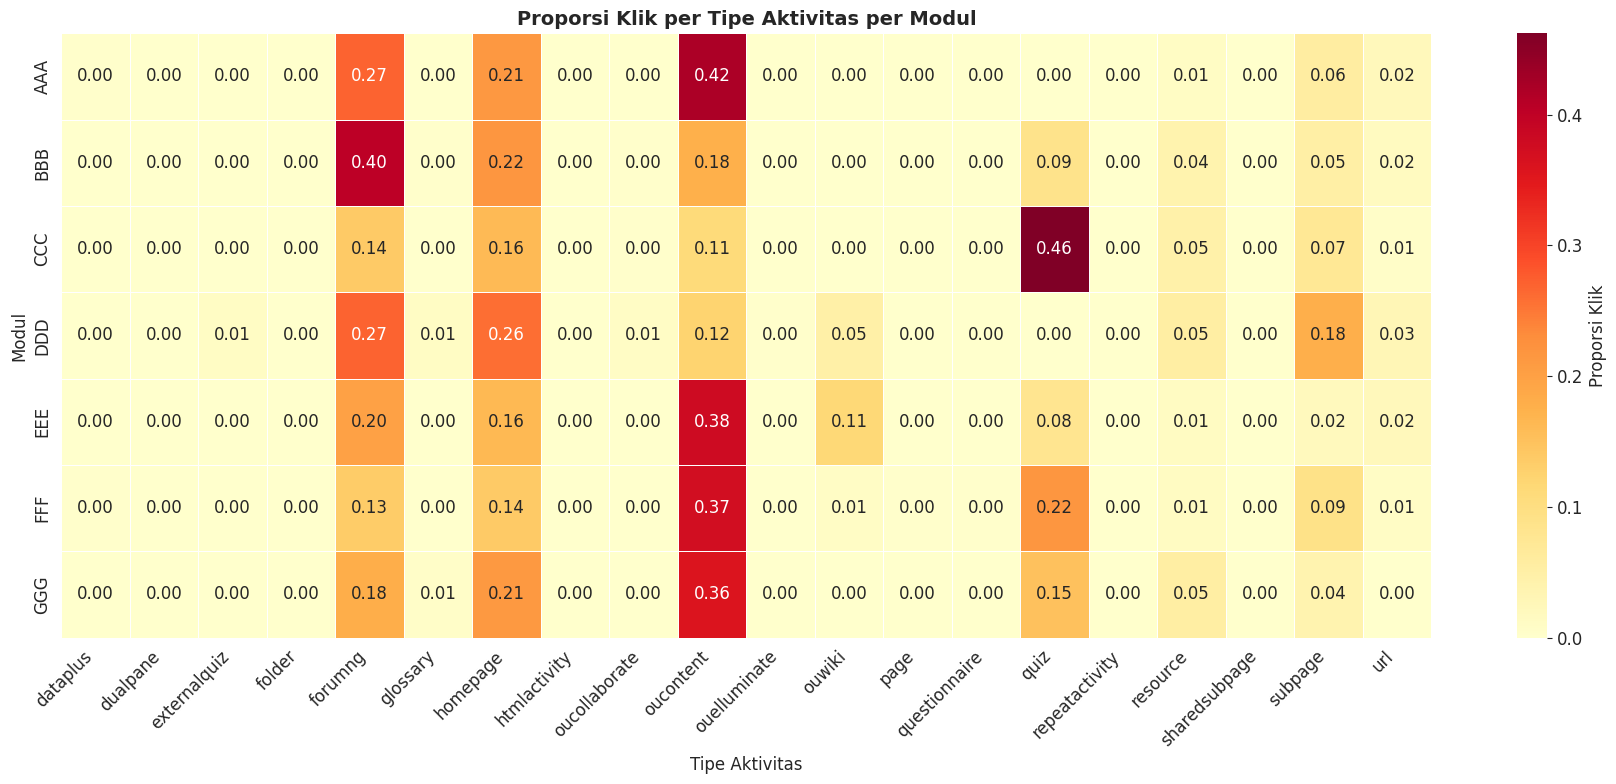

CPU times: user 5.89 s, sys: 730 ms, total: 6.62 s
Wall time: 6.68 s


In [33]:
%%time
# 6.1 Tipe Aktivitas VLE per Modul

print("[LOADING] Menghitung engagement per tipe aktivitas per modul...")

# Gabungkan studentVle dengan vle metadata
svle_with_type = df_student_vle.merge(
    df_vle[['id_site', 'code_module', 'code_presentation', 'activity_type']],
    on=['id_site', 'code_module', 'code_presentation'], how='left'
)

# Klik per modul per tipe aktivitas
module_activity = svle_with_type.groupby(
    ['code_module', 'activity_type']
)['sum_click'].sum().reset_index()

# Pivot untuk heatmap
pivot_module_activity = module_activity.pivot_table(
    index='code_module', columns='activity_type',
    values='sum_click', fill_value=0
)

# Normalisasi per modul (proporsi)
pivot_module_pct = pivot_module_activity.div(pivot_module_activity.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(pivot_module_pct, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Proporsi Klik'})
ax.set_title('Proporsi Klik per Tipe Aktivitas per Modul', fontweight='bold', fontsize=14)
ax.set_xlabel('Tipe Aktivitas')
ax.set_ylabel('Modul')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

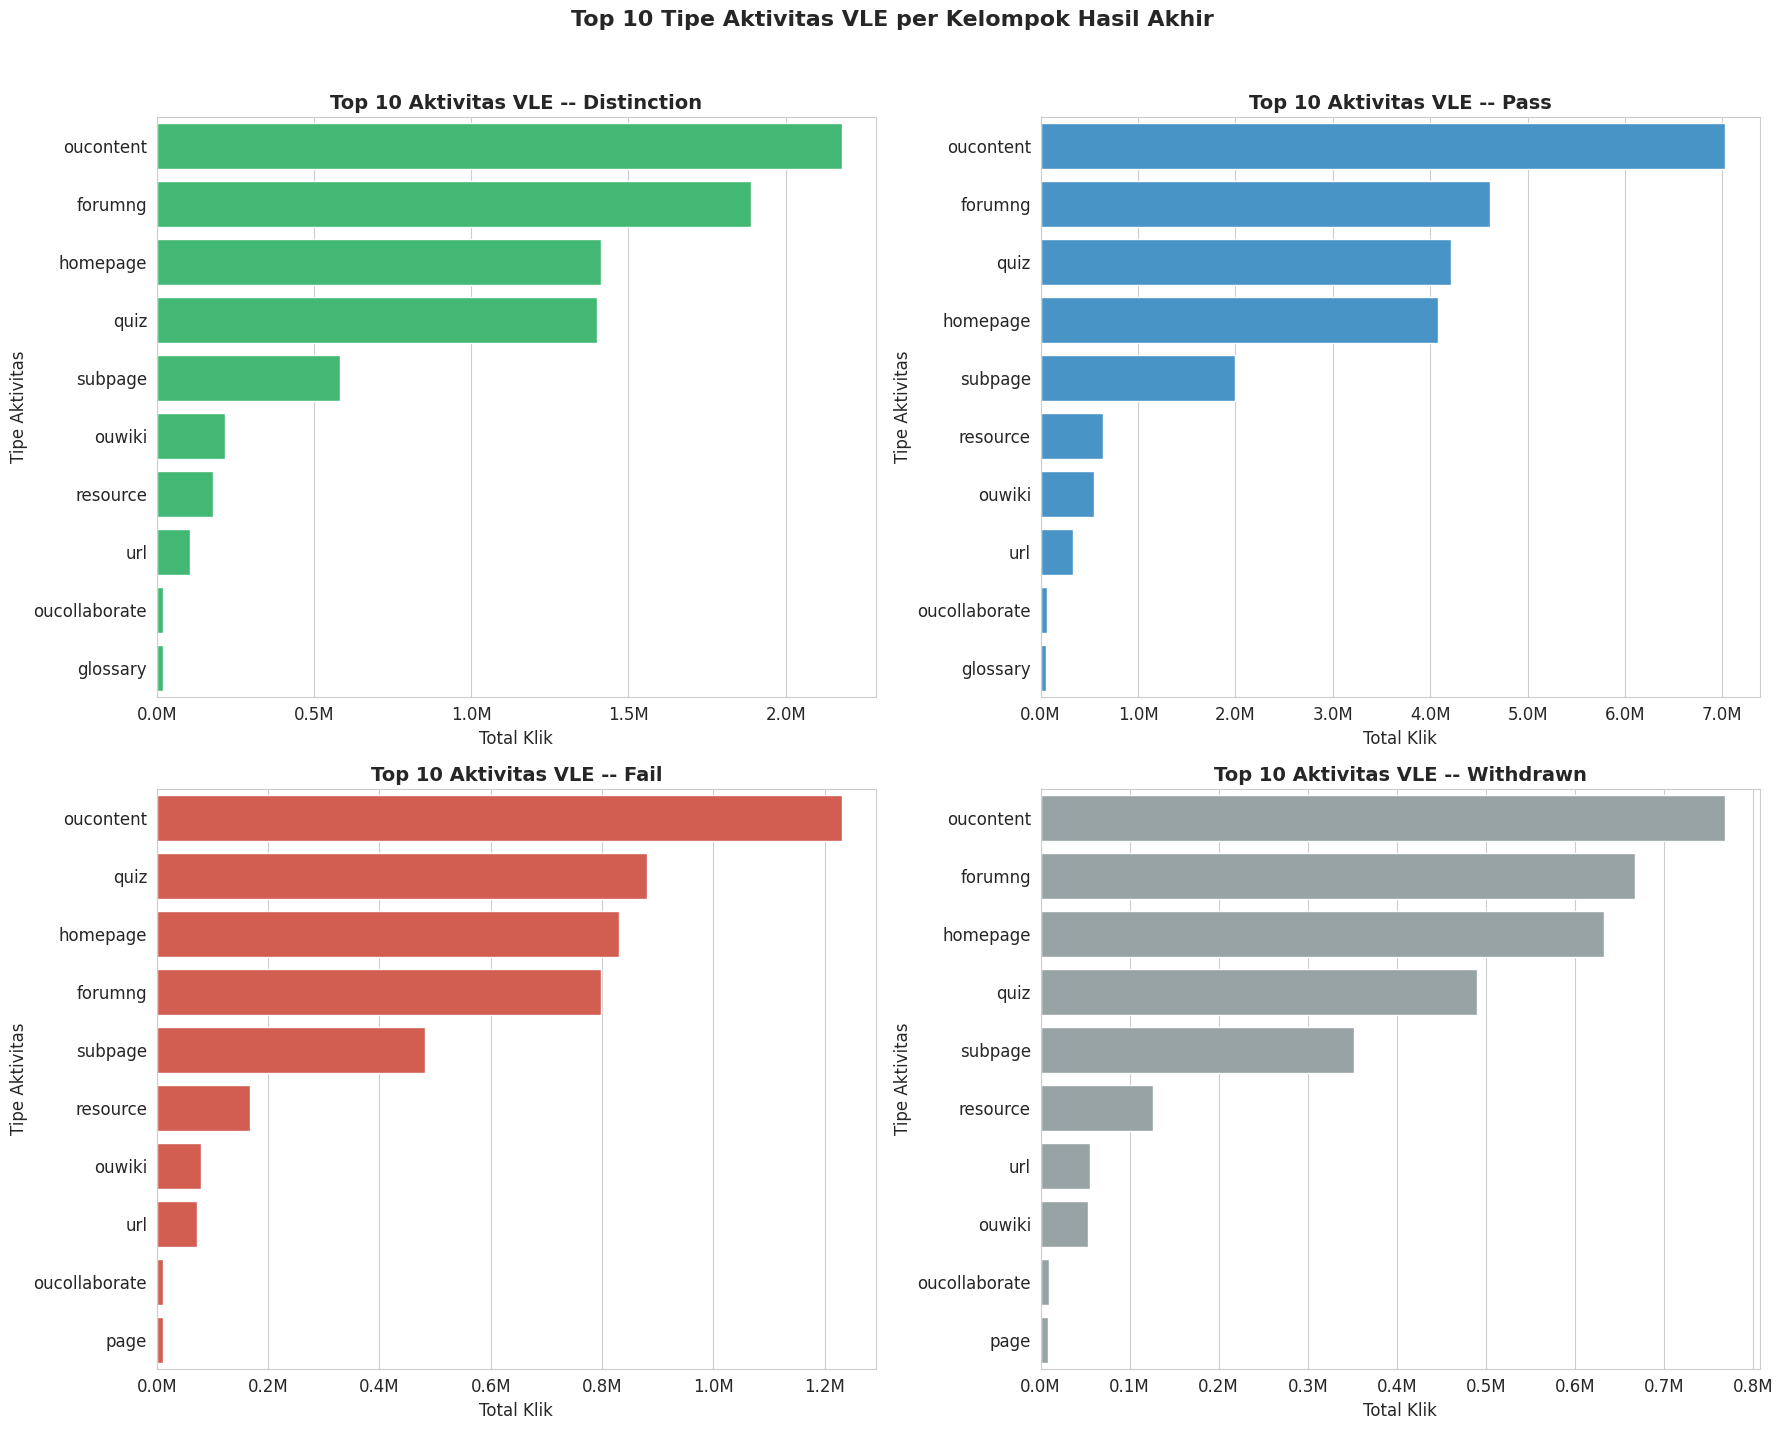

CPU times: user 6.61 s, sys: 1.76 s, total: 8.37 s
Wall time: 8.86 s


39744

In [34]:
%%time
# 6.2 Tipe Aktivitas Paling Populer per Outcome

# Gabungkan dengan hasil akhir
svle_type_result = svle_with_type.merge(
    df_student_info[['id_student', 'code_module', 'code_presentation', 'final_result']],
    on=['id_student', 'code_module', 'code_presentation'], how='left'
)

# Klik per outcome per tipe aktivitas
result_activity = svle_type_result.groupby(
    ['final_result', 'activity_type']
)['sum_click'].sum().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, res in enumerate(result_order):
    ax = axes[idx]
    data = result_activity[result_activity['final_result'] == res]
    data = data.nlargest(10, 'sum_click')

    sns.barplot(data=data, y='activity_type', x='sum_click',
                color=colors_result[idx], ax=ax)
    ax.set_title(f'Top 10 Aktivitas VLE -- {res}', fontweight='bold')
    ax.set_xlabel('Total Klik')
    ax.set_ylabel('Tipe Aktivitas')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.suptitle('Top 10 Tipe Aktivitas VLE per Kelompok Hasil Akhir',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Bersihkan
del svle_type_result
gc.collect()

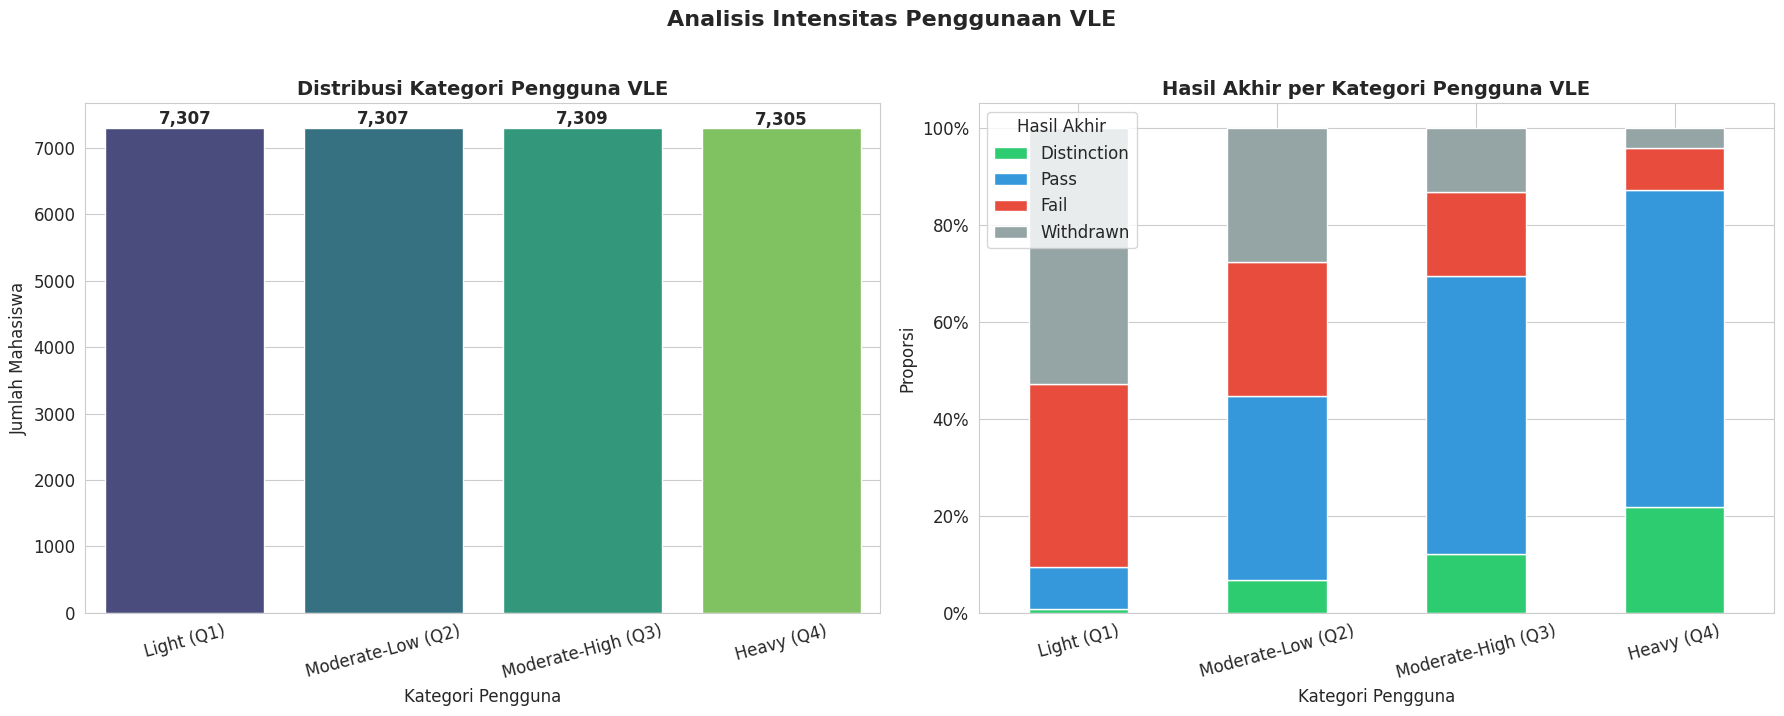

Batas Kuartil Klik:
  - Q1 (Light): ≤ 261 klik
  - Q2 (Moderate-Low): 261 - 740 klik
  - Q3 (Moderate-High): 740 - 1,770 klik
  - Q4 (Heavy): > 1,770 klik
CPU times: user 486 ms, sys: 3.26 ms, total: 489 ms
Wall time: 492 ms


In [35]:
%%time
# 6.3 Intensitas Klik: Heavy vs Light Users

# Gunakan vle_clicks_per_student yang sudah dihitung sebelumnya
vle_user_stats = vle_clicks_per_student.copy()

# Kategorisasi pengguna berdasarkan kuartil
quantiles = vle_user_stats['total_clicks'].quantile([0.25, 0.50, 0.75])
vle_user_stats['user_category'] = pd.cut(
    vle_user_stats['total_clicks'],
    bins=[-np.inf, quantiles[0.25], quantiles[0.50], quantiles[0.75], np.inf],
    labels=['Light (Q1)', 'Moderate-Low (Q2)', 'Moderate-High (Q3)', 'Heavy (Q4)']
)

# Gabungkan dengan hasil akhir
vle_user_stats = vle_user_stats.merge(
    df_student_info[['id_student', 'code_module', 'code_presentation', 'final_result']],
    on=['id_student', 'code_module', 'code_presentation'], how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Distribusi kategori pengguna
cat_counts = vle_user_stats['user_category'].value_counts().reindex(
    ['Light (Q1)', 'Moderate-Low (Q2)', 'Moderate-High (Q3)', 'Heavy (Q4)']
)
sns.barplot(x=cat_counts.index, y=cat_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title('Distribusi Kategori Pengguna VLE', fontweight='bold')
axes[0].set_xlabel('Kategori Pengguna')
axes[0].set_ylabel('Jumlah Mahasiswa')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)
for i, v in enumerate(cat_counts.values):
    axes[0].text(i, v + 50, f"{v:,}", ha='center', fontweight='bold')

# Hasil akhir per kategori pengguna
ct_user_result = pd.crosstab(vle_user_stats['user_category'], vle_user_stats['final_result'],
                              normalize='index')
ct_user_result = ct_user_result.reindex(columns=result_order, fill_value=0)
ct_user_result.plot(kind='bar', stacked=True, ax=axes[1], color=colors_result, edgecolor='white')
axes[1].set_title('Hasil Akhir per Kategori Pengguna VLE', fontweight='bold')
axes[1].set_xlabel('Kategori Pengguna')
axes[1].set_ylabel('Proporsi')
axes[1].legend(title='Hasil Akhir')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.suptitle('Analisis Intensitas Penggunaan VLE',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Batas Kuartil Klik:")
print(f"  - Q1 (Light): \u2264 {quantiles[0.25]:,.0f} klik")
print(f"  - Q2 (Moderate-Low): {quantiles[0.25]:,.0f} - {quantiles[0.50]:,.0f} klik")
print(f"  - Q3 (Moderate-High): {quantiles[0.50]:,.0f} - {quantiles[0.75]:,.0f} klik")
print(f"  - Q4 (Heavy): > {quantiles[0.75]:,.0f} klik")

[LOADING] Menghitung metrik VLE agregat per mahasiswa...
Statistik VLE Agregat per Kelompok Hasil Akhir:


,total_clicks,unique_sites,active_days,avg_clicks_per_day,engagement_span
final_result,,,,,
Distinction,2666.8,102.4,110.0,21.9,255.4
Pass,1922.3,89.1,87.1,20.5,251.2
Fail,688.4,45.5,35.0,17.2,147.6
Withdrawn,444.8,34.3,23.1,17.1,78.1


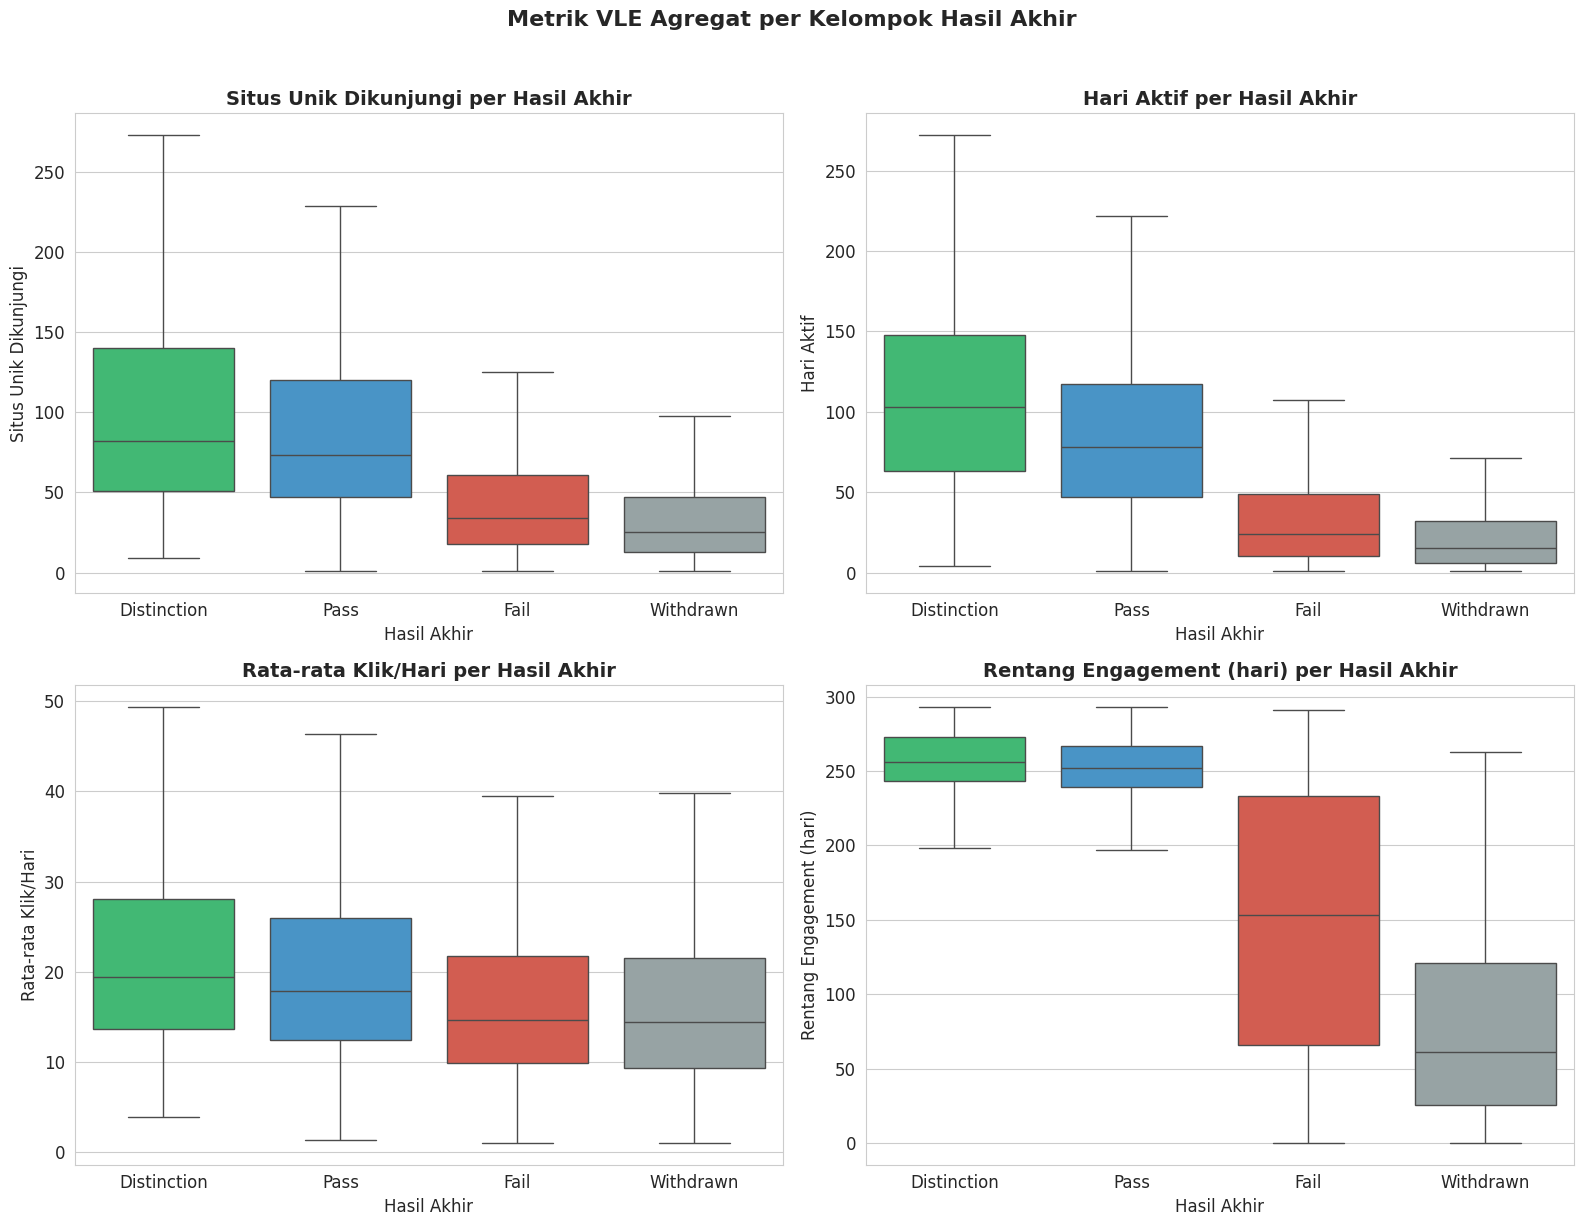

CPU times: user 5.23 s, sys: 323 ms, total: 5.56 s
Wall time: 5.97 s


In [36]:
%%time
# 6.4 Metrik VLE Agregat per Mahasiswa

print("[LOADING] Menghitung metrik VLE agregat per mahasiswa...")

vle_agg = df_student_vle.groupby(
    ['code_module', 'code_presentation', 'id_student']
).agg(
    total_clicks=('sum_click', 'sum'),
    unique_sites=('id_site', 'nunique'),
    active_days=('date', 'nunique'),
    total_interactions=('sum_click', 'count'),
    avg_clicks_per_interaction=('sum_click', 'mean'),
    max_daily_clicks=('sum_click', 'max'),
    first_access_day=('date', 'min'),
    last_access_day=('date', 'max')
).reset_index()

vle_agg['avg_clicks_per_day'] = vle_agg['total_clicks'] / vle_agg['active_days']
vle_agg['engagement_span'] = vle_agg['last_access_day'] - vle_agg['first_access_day']

# Gabungkan dengan hasil akhir
vle_agg_result = vle_agg.merge(
    df_student_info[['id_student', 'code_module', 'code_presentation', 'final_result']],
    on=['id_student', 'code_module', 'code_presentation'], how='left'
)

print("Statistik VLE Agregat per Kelompok Hasil Akhir:")
display(
    vle_agg_result.groupby('final_result')[[
        'total_clicks', 'unique_sites', 'active_days',
        'avg_clicks_per_day', 'engagement_span'
    ]].mean().round(1).reindex(result_order)
)

# Visualisasi metrik utama
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = [
    ('unique_sites', 'Situs Unik Dikunjungi'),
    ('active_days', 'Hari Aktif'),
    ('avg_clicks_per_day', 'Rata-rata Klik/Hari'),
    ('engagement_span', 'Rentang Engagement (hari)')
]

for idx, (metric, label) in enumerate(metrics):
    ax = axes[idx // 2][idx % 2]
    sns.boxplot(data=vle_agg_result, x='final_result', y=metric,
                order=result_order, palette=colors_result, ax=ax,
                showfliers=False)
    ax.set_title(f'{label} per Hasil Akhir', fontweight='bold')
    ax.set_xlabel('Hasil Akhir')
    ax.set_ylabel(label)

plt.suptitle('Metrik VLE Agregat per Kelompok Hasil Akhir',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 📝 Temuan Deep Dive VLE

**Tipe Aktivitas per Modul:**
- Setiap modul memiliki profil aktivitas VLE yang berbeda.
- `oucontent` dan `forumng` umumnya mendominasi di semua modul.
- Beberapa modul lebih banyak menggunakan `quiz` atau `resource`.

**Intensitas Penggunaan:**
- **Temuan penting:** Heavy users (Q4) memiliki tingkat kelulusan (Pass + Distinction) yang jauh lebih tinggi.
- Light users (Q1) memiliki proporsi Withdrawn dan Fail paling besar.
- Ini mengkonfirmasi bahwa engagement VLE adalah prediktor kuat keberhasilan.

**Metrik Agregat:**
- Mahasiswa Distinction memiliki rata-rata **hari aktif**, **situs unik**, dan **klik per hari** tertinggi.
- Mahasiswa Withdrawn memiliki **rentang engagement** yang pendek — mereka berhenti berinteraksi jauh sebelum akhir modul.

---
## ⚖️ Section 7: Analisis Bias & Kesetaraan

Bagian ini menganalisis potensi bias dan ketidaksetaraan dalam data OULAD:
- **Bias sosial-ekonomi:** Apakah mahasiswa dari daerah deprived memiliki hasil lebih buruk?
- **Kesetaraan gender:** Apakah ada perbedaan signifikan antara laki-laki dan perempuan?
- **Dampak disabilitas:** Apakah mahasiswa penyandang disabilitas dirugikan?
- **Disparitas regional:** Apakah ada wilayah yang tertinggal?
- **Disparate Impact Ratio:** Mengukur fairness kuantitatif
- **Uji statistik Chi-Square:** Menguji signifikansi asosiasi

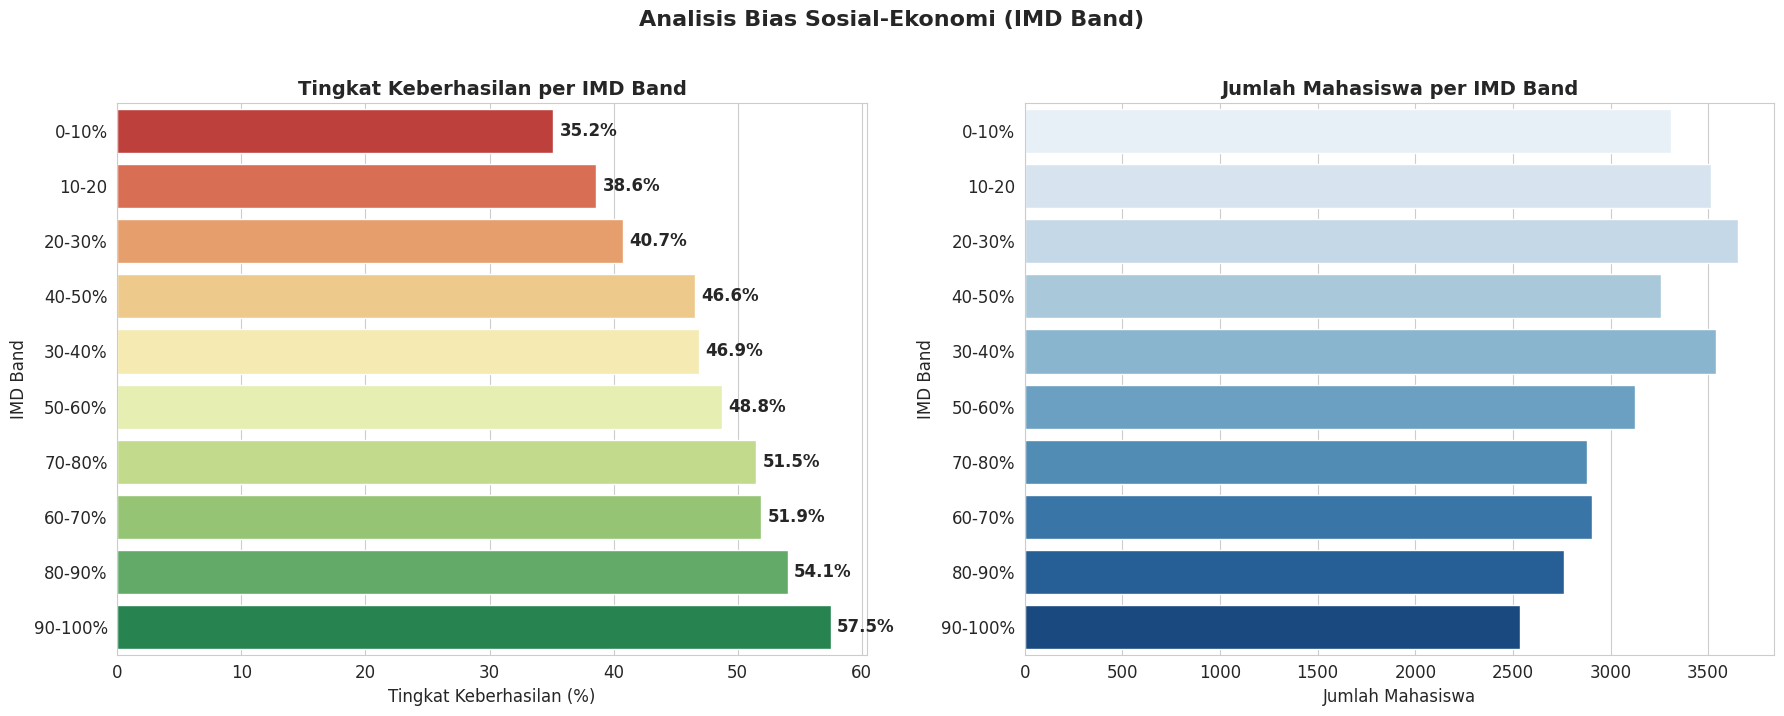

In [37]:
# 7.1 Bias Sosial-Ekonomi: IMD Band vs Hasil Akhir (Detail)

# Buat variabel sukses (Pass + Distinction = 1, Fail + Withdrawn = 0)
df_student_info['is_success'] = df_student_info['final_result'].isin(['Pass', 'Distinction']).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Tingkat keberhasilan per IMD Band
success_by_imd = df_student_info.groupby('imd_band')['is_success'].mean().sort_values()
success_by_imd = success_by_imd.dropna()

colors_imd = sns.color_palette('RdYlGn', len(success_by_imd))
sns.barplot(y=success_by_imd.index, x=success_by_imd.values * 100,
            palette=colors_imd, ax=axes[0])
axes[0].set_title('Tingkat Keberhasilan per IMD Band', fontweight='bold')
axes[0].set_xlabel('Tingkat Keberhasilan (%)')
axes[0].set_ylabel('IMD Band')
for i, v in enumerate(success_by_imd.values * 100):
    axes[0].text(v + 0.5, i, f"{v:.1f}%", va='center', fontweight='bold')

# Jumlah mahasiswa per IMD Band (konteks)
imd_student_count = df_student_info['imd_band'].value_counts().reindex(success_by_imd.index)
sns.barplot(y=imd_student_count.index, x=imd_student_count.values,
            palette='Blues', ax=axes[1])
axes[1].set_title('Jumlah Mahasiswa per IMD Band', fontweight='bold')
axes[1].set_xlabel('Jumlah Mahasiswa')
axes[1].set_ylabel('IMD Band')

plt.suptitle('Analisis Bias Sosial-Ekonomi (IMD Band)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

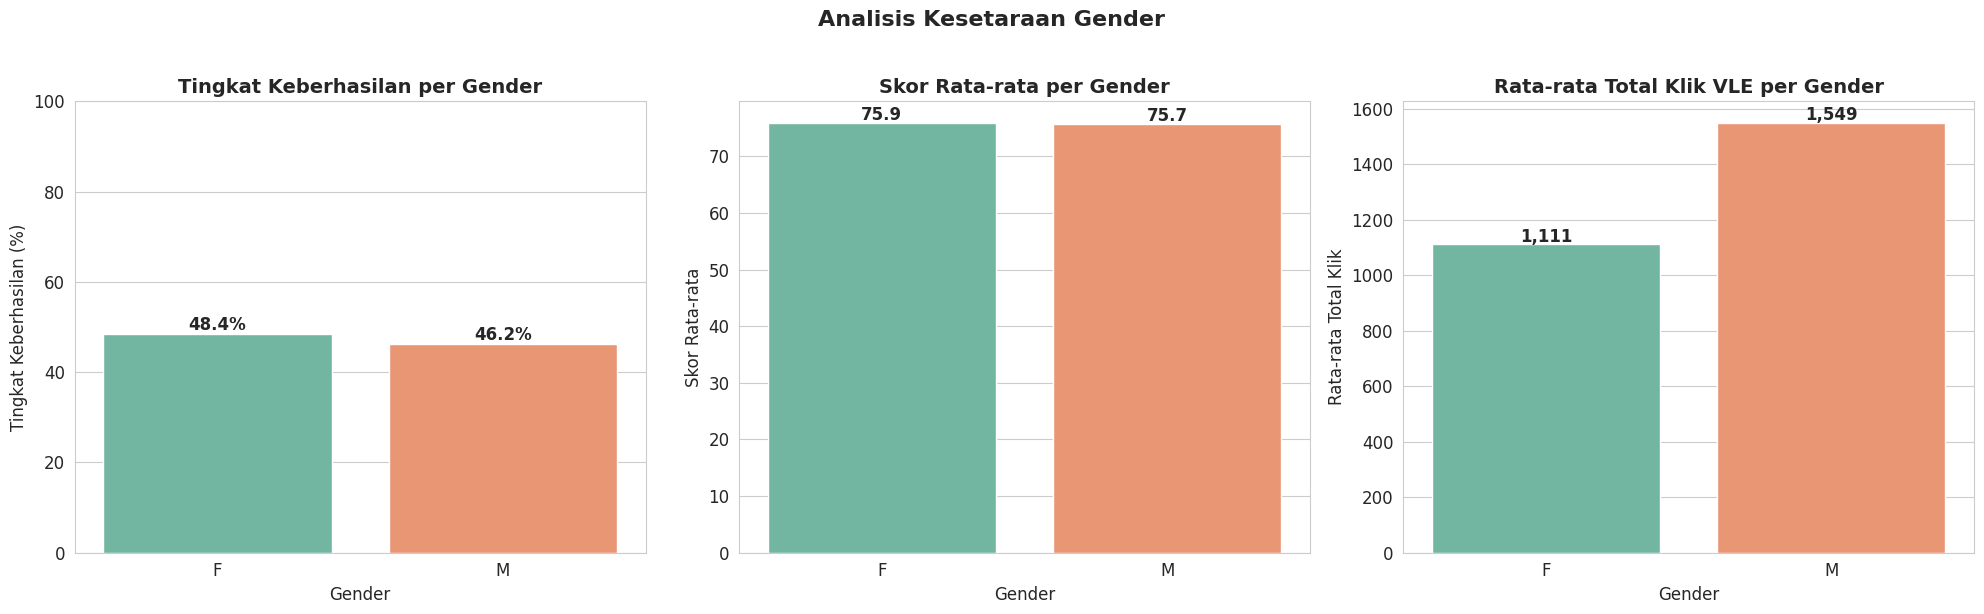

In [38]:
# 7.2 Kesetaraan Gender
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Tingkat keberhasilan per gender
success_by_gender = df_student_info.groupby('gender')['is_success'].mean()
sns.barplot(x=success_by_gender.index, y=success_by_gender.values * 100,
            palette='Set2', ax=axes[0])
axes[0].set_title('Tingkat Keberhasilan per Gender', fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Tingkat Keberhasilan (%)')
axes[0].set_ylim(0, 100)
for i, v in enumerate(success_by_gender.values * 100):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')

# Skor rata-rata per gender
score_by_gender = df_sa_merged.groupby(
    df_sa_merged.merge(
        df_student_info[['id_student', 'gender']].drop_duplicates(),
        on='id_student', how='left'
    )['gender']
)['score'].mean()

# Alternatif: merge langsung
sa_gender = df_sa_merged.merge(
    df_student_info[['id_student', 'gender']].drop_duplicates(),
    on='id_student', how='left'
)
score_gender_mean = sa_gender.groupby('gender')['score'].mean()
sns.barplot(x=score_gender_mean.index, y=score_gender_mean.values,
            palette='Set2', ax=axes[1])
axes[1].set_title('Skor Rata-rata per Gender', fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Skor Rata-rata')
for i, v in enumerate(score_gender_mean.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}", ha='center', fontweight='bold')

# VLE engagement per gender
vle_gender = vle_agg.merge(
    df_student_info[['id_student', 'code_module', 'code_presentation', 'gender']],
    on=['id_student', 'code_module', 'code_presentation'], how='left'
)
clicks_gender = vle_gender.groupby('gender')['total_clicks'].mean()
sns.barplot(x=clicks_gender.index, y=clicks_gender.values,
            palette='Set2', ax=axes[2])
axes[2].set_title('Rata-rata Total Klik VLE per Gender', fontweight='bold')
axes[2].set_xlabel('Gender')
axes[2].set_ylabel('Rata-rata Total Klik')
for i, v in enumerate(clicks_gender.values):
    axes[2].text(i, v + 10, f"{v:,.0f}", ha='center', fontweight='bold')

plt.suptitle('Analisis Kesetaraan Gender',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

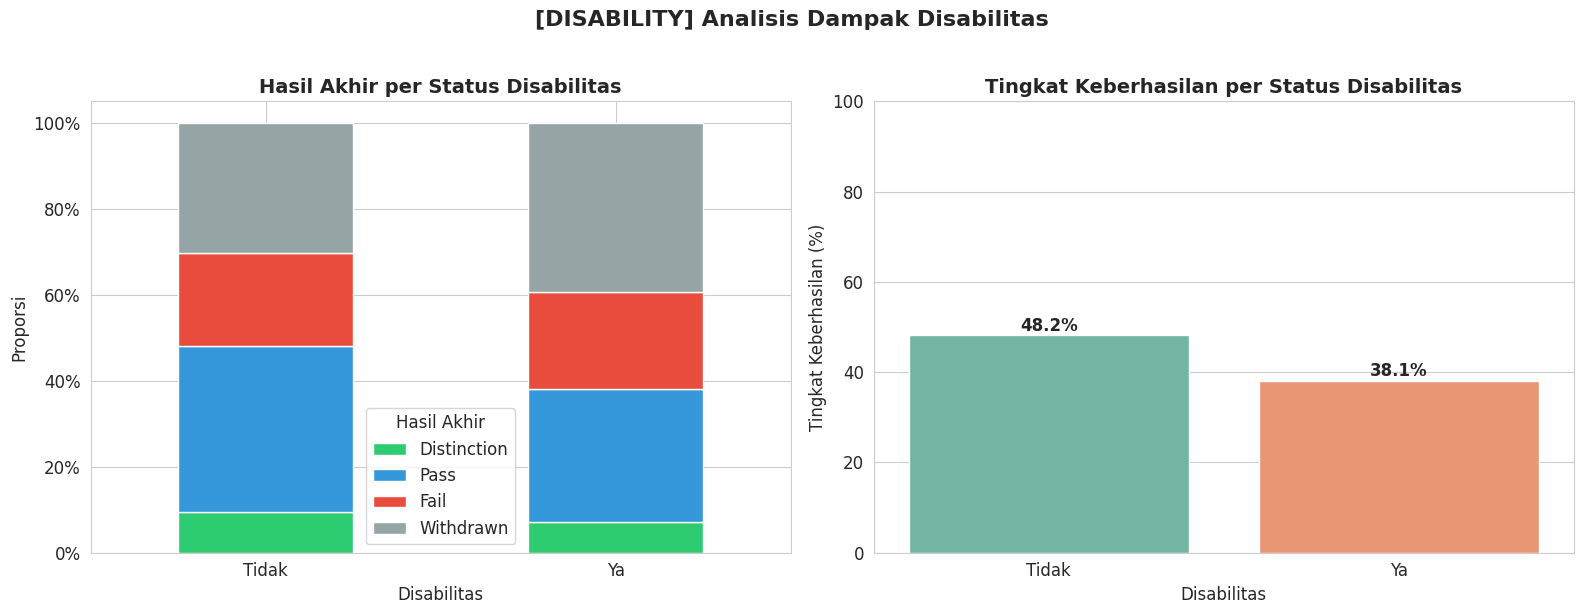

In [39]:
# 7.3 Dampak Disabilitas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Hasil akhir per disabilitas
ct_disability = pd.crosstab(df_student_info['disability'], df_student_info['final_result'],
                             normalize='index')
ct_disability = ct_disability.reindex(columns=result_order, fill_value=0)
ct_disability.plot(kind='bar', stacked=True, ax=axes[0], color=colors_result, edgecolor='white')
axes[0].set_title('Hasil Akhir per Status Disabilitas', fontweight='bold')
axes[0].set_xlabel('Disabilitas')
axes[0].set_ylabel('Proporsi')
axes[0].legend(title='Hasil Akhir')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_xticklabels(['Tidak', 'Ya'], rotation=0)

# Tingkat keberhasilan
success_disability = df_student_info.groupby('disability')['is_success'].mean() * 100
sns.barplot(x=success_disability.index, y=success_disability.values,
            palette='Set2', ax=axes[1])
axes[1].set_title('Tingkat Keberhasilan per Status Disabilitas', fontweight='bold')
axes[1].set_xlabel('Disabilitas')
axes[1].set_ylabel('Tingkat Keberhasilan (%)')
axes[1].set_ylim(0, 100)
axes[1].set_xticklabels(['Tidak', 'Ya'], rotation=0)
for i, v in enumerate(success_disability.values):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')

plt.suptitle('[DISABILITY] Analisis Dampak Disabilitas',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

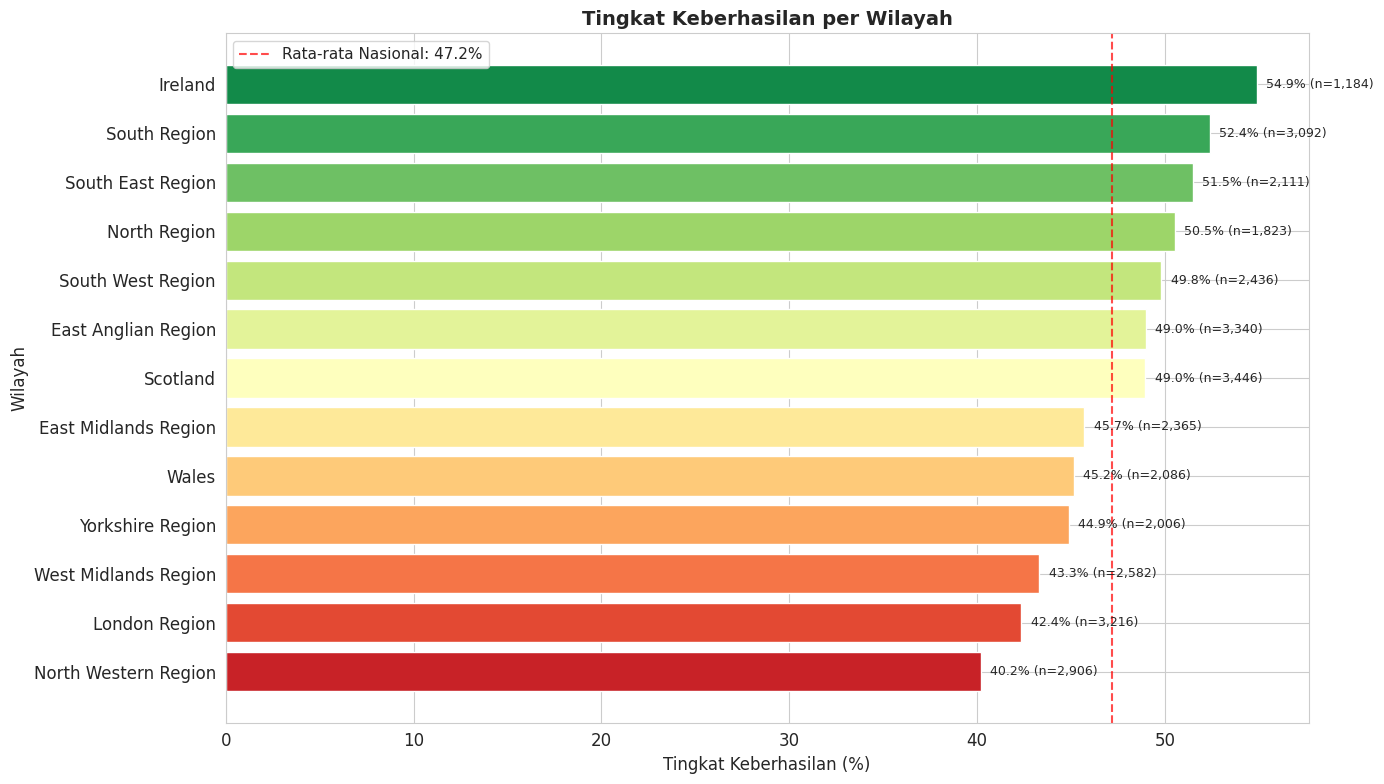

In [53]:
# 7.4 Disparitas Regional
# Tingkat keberhasilan per wilayah
success_by_region = df_student_info.groupby('region').agg(
    success_rate=('is_success', 'mean'),
    count=('is_success', 'count')
).reset_index()
success_by_region = success_by_region.sort_values('success_rate', ascending=True)

fig, ax = plt.subplots(figsize=(14, 8))

colors_region = sns.color_palette('RdYlGn', len(success_by_region))
bars = ax.barh(success_by_region['region'], success_by_region['success_rate'] * 100,
               color=colors_region)
ax.set_title('Tingkat Keberhasilan per Wilayah', fontweight='bold')
ax.set_xlabel('Tingkat Keberhasilan (%)')
ax.set_ylabel('Wilayah')

# Tambahkan label
for i, (rate, count) in enumerate(zip(success_by_region['success_rate'].values,
                                        success_by_region['count'].values)):
    ax.text(rate * 100 + 0.5, i, f"{rate*100:.1f}% (n={count:,})",
            va='center', fontsize=9)

# Garis rata-rata nasional
national_avg = df_student_info['is_success'].mean() * 100
ax.axvline(x=national_avg, color='red', linestyle='--', alpha=0.7,
           label=f'Rata-rata Nasional: {national_avg:.1f}%')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

In [41]:
# 7.5 Disparate Impact Ratio (DIR)
def calculate_disparate_impact(df, protected_col, outcome_col='is_success',
                                privileged_value=None):
    """Menghitung Disparate Impact Ratio.

    Disparate Impact Ratio = (tingkat keberhasilan kelompok terlindungi) /
                             (tingkat keberhasilan kelompok privileged)

    Aturan 80% (Four-Fifths Rule):
    - DIR >= 0.8 : Tidak ada indikasi disparate impact
    - DIR < 0.8  : Ada indikasi disparate impact (potensi bias)

    Parameters
    ----------
    df : pd.DataFrame
    protected_col : str
        Kolom atribut terlindungi
    outcome_col : str
        Kolom outcome biner (1=sukses, 0=gagal)
    privileged_value : str, optional
        Nilai kelompok privileged. Jika None, gunakan kelompok dengan tingkat tertinggi.

    Returns
    -------
    pd.DataFrame : hasil DIR untuk setiap kelompok
    """
    rates = df.groupby(protected_col)[outcome_col].mean()

    if privileged_value is None:
        privileged_value = rates.idxmax()

    privileged_rate = rates[privileged_value]

    results = []
    for group, rate in rates.items():
        dir_val = rate / privileged_rate if privileged_rate > 0 else np.nan
        results.append({
            'Kelompok': group,
            'Tingkat Keberhasilan': f"{rate*100:.1f}%",
            'DIR': round(dir_val, 3),
            'Status': '[OK] Fair' if dir_val >= 0.8 else '\u26a0\ufe0f Disparate Impact',
            'Privileged': '[STAR]' if group == privileged_value else ''
        })

    return pd.DataFrame(results), privileged_value

print(" DISPARATE IMPACT RATIO (DIR) ANALYSIS")
print("Aturan 80% (Four-Fifths Rule): DIR >= 0.8 dianggap fair.\n")

# Filter mahasiswa dengan imd_band yang valid
df_valid = df_student_info.dropna(subset=['imd_band'])

dimensions = {
    'Gender': ('gender', None),
    'Kelompok Umur': ('age_band', None),
    'Disabilitas': ('disability', 'N'),
    'Pendidikan Tertinggi': ('highest_education', None),
}

for dim_name, (col, priv) in dimensions.items():
    dir_df, priv_val = calculate_disparate_impact(df_student_info, col, privileged_value=priv)
    print(f"{dim_name} (Privileged: {priv_val}):")
    display(dir_df)

# IMD Band dengan data valid
dir_imd, priv_imd = calculate_disparate_impact(df_valid, 'imd_band')
print(f"IMD Band (Privileged: {priv_imd}):")
display(dir_imd)

 DISPARATE IMPACT RATIO (DIR) ANALYSIS
Aturan 80% (Four-Fifths Rule): DIR >= 0.8 dianggap fair.

Gender (Privileged: F):


,Kelompok,Tingkat Keberhasilan,DIR,Status,Privileged
0,F,48.4%,1.000,[OK] Fair,[STAR]
1,M,46.2%,0.954,[OK] Fair,


Kelompok Umur (Privileged: 55<=):


,Kelompok,Tingkat Keberhasilan,DIR,Status,Privileged
0,0-35,45.0%,0.731,⚠️ Disparate Impact,
1,35-55,52.2%,0.847,[OK] Fair,
2,55<=,61.6%,1.000,[OK] Fair,[STAR]


Disabilitas (Privileged: N):


,Kelompok,Tingkat Keberhasilan,DIR,Status,Privileged
0,N,48.2%,1.000,[OK] Fair,[STAR]
1,Y,38.1%,0.792,⚠️ Disparate Impact,


Pendidikan Tertinggi (Privileged: Post Graduate Qualification):


,Kelompok,Tingkat Keberhasilan,DIR,Status,Privileged
0,A Level or Equivalent,52.0%,0.794,⚠️ Disparate Impact,
1,HE Qualification,56.2%,0.858,[OK] Fair,
2,Lower Than A Level,38.9%,0.593,⚠️ Disparate Impact,
3,No Formal quals,29.7%,0.453,⚠️ Disparate Impact,
4,Post Graduate Qualification,65.5%,1.000,[OK] Fair,[STAR]


IMD Band (Privileged: 90-100%):


,Kelompok,Tingkat Keberhasilan,DIR,Status,Privileged
0,0-10%,35.2%,0.611,⚠️ Disparate Impact,
1,10-20,38.6%,0.671,⚠️ Disparate Impact,
2,20-30%,40.7%,0.708,⚠️ Disparate Impact,
3,30-40%,46.9%,0.815,[OK] Fair,
4,40-50%,46.6%,0.810,[OK] Fair,
5,50-60%,48.8%,0.848,[OK] Fair,
6,60-70%,51.9%,0.902,[OK] Fair,
7,70-80%,51.5%,0.895,[OK] Fair,
8,80-90%,54.1%,0.940,[OK] Fair,
9,90-100%,57.5%,1.000,[OK] Fair,[STAR]


In [52]:
# 7.6 Uji Statistik Chi-Square
print("UJI CHI-SQUARE: ASOSIASI DEMOGRAFI vs HASIL AKHIR")

print("H0: Tidak ada asosiasi antara variabel demografi dan hasil akhir")
print("H1: Ada asosiasi antara variabel demografi dan hasil akhir")
print(f"alpha = 0.05\n")

chi2_vars = ['gender', 'age_band', 'highest_education', 'disability', 'region']

chi2_results = []
for var in chi2_vars:
    contingency = pd.crosstab(df_student_info[var], df_student_info['final_result'])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

    # Cramer's V (effect size)
    n = contingency.sum().sum()
    min_dim = min(contingency.shape[0], contingency.shape[1]) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

    significant = "[OK] Ya" if p_value < 0.05 else "[X] Tidak"
    effect = 'Kecil' if cramers_v < 0.1 else ('Sedang' if cramers_v < 0.3 else 'Besar')

    chi2_results.append({
        'Variabel': var,
        'Chi-Square': round(chi2, 2),
        'p-value': f"{p_value:.2e}" if p_value < 0.001 else f"{p_value:.4f}",
        'DoF': dof,
        "Cramer's V": round(cramers_v, 4),
        'Effect Size': effect,
        'Signifikan (alpha=0.05)': significant
    })

# Chi-square untuk IMD Band (tanpa missing)
contingency_imd = pd.crosstab(df_valid['imd_band'], df_valid['final_result'])
chi2_imd, p_imd, dof_imd, _ = stats.chi2_contingency(contingency_imd)
n_imd = contingency_imd.sum().sum()
min_dim_imd = min(contingency_imd.shape[0], contingency_imd.shape[1]) - 1
v_imd = np.sqrt(chi2_imd / (n_imd * min_dim_imd)) if min_dim_imd > 0 else 0
effect_imd = 'Kecil' if v_imd < 0.1 else ('Sedang' if v_imd < 0.3 else 'Besar')

chi2_results.append({
    'Variabel': 'imd_band',
    'Chi-Square': round(chi2_imd, 2),
    'p-value': f"{p_imd:.2e}" if p_imd < 0.001 else f"{p_imd:.4f}",
    'DoF': dof_imd,
    "Cramer's V": round(v_imd, 4),
    'Effect Size': effect_imd,
    'Signifikan (alpha=0.05)': "[OK] Ya" if p_imd < 0.05 else "[X] Tidak"
})

display(pd.DataFrame(chi2_results))

print("Interpretasi:")
print("p-value < 0.05 menunjukkan asosiasi yang signifikan secara statistik.")
print("Cramer's V mengukur kekuatan asosiasi (0=tidak ada, 1=sempurna).")
print("Variabel dengan effect size 'Sedang' atau 'Besar' patut menjadi perhatian.")

UJI CHI-SQUARE: ASOSIASI DEMOGRAFI vs HASIL AKHIR
H0: Tidak ada asosiasi antara variabel demografi dan hasil akhir
H1: Ada asosiasi antara variabel demografi dan hasil akhir
alpha = 0.05



,Variabel,Chi-Square,p-value,DoF,Cramer's V,Effect Size,Signifikan (alpha=0.05)
0,gender,16.53,8.83e-04,3,0.0225,Kecil,[OK] Ya
1,age_band,222.65,2.83e-45,6,0.0584,Kecil,[OK] Ya
2,highest_education,1024.70,9.18e-212,12,0.1024,Sedang,[OK] Ya
3,disability,138.45,8.14e-30,3,0.0652,Kecil,[OK] Ya
4,region,449.72,6.47e-73,36,0.0678,Kecil,[OK] Ya
5,imd_band,666.94,3.15e-123,27,0.0840,Kecil,[OK] Ya


Interpretasi:
p-value < 0.05 menunjukkan asosiasi yang signifikan secara statistik.
Cramer's V mengukur kekuatan asosiasi (0=tidak ada, 1=sempurna).
Variabel dengan effect size 'Sedang' atau 'Besar' patut menjadi perhatian.


### 📝 Temuan Analisis Bias & Kesetaraan

**Sosial-Ekonomi (IMD Band):**
- Terdapat disparitas yang jelas: mahasiswa dari daerah lebih deprived (IMD rendah) memiliki tingkat keberhasilan yang lebih rendah.
- Disparate Impact Ratio untuk beberapa band IMD terendah mungkin berada di bawah ambang batas 0.8.

**Gender:**
- Perbedaan tingkat keberhasilan antara laki-laki dan perempuan relatif kecil.
- Secara statistik mungkin signifikan karena ukuran sampel besar, tapi effect size kecil.

**Disabilitas:**
- Mahasiswa penyandang disabilitas menunjukkan tingkat keberhasilan yang sedikit lebih rendah.
- Perlu perhatian khusus untuk dukungan aksesibilitas.

**Regional:**
- Terdapat variasi antar wilayah, dengan beberapa wilayah di bawah rata-rata nasional.
- Scotland dan Ireland cenderung memiliki pola yang berbeda.

**Uji Chi-Square:**
- Semua variabel demografi menunjukkan asosiasi signifikan dengan hasil akhir.
- `highest_education` kemungkinan memiliki effect size terbesar.
- Perlu diingat: signifikan secara statistik ≠ signifikan secara praktis.

---
## 🛠️ Section 8: Rekayasa Fitur & Ekspor Data

Pada bagian terakhir ini, kita akan:
1. Membuat fitur agregat level mahasiswa dari semua dataset
2. Menggabungkan semua fitur ke dalam satu **master dataframe**
3. Menyimpan data yang sudah diproses untuk pemodelan selanjutnya

Output:
- `student_master.csv` — Satu baris per mahasiswa dengan semua fitur agregat
- `vle_aggregated.csv` — Statistik VLE agregat per mahasiswa per modul

In [43]:
%%time
# 8.1 Fitur VLE Agregat

print(" Menghitung fitur VLE agregat per mahasiswa...")

# Gunakan vle_agg yang sudah dihitung di section 6
vle_features = vle_agg[[
    'code_module', 'code_presentation', 'id_student',
    'total_clicks', 'unique_sites', 'active_days',
    'total_interactions', 'avg_clicks_per_interaction',
    'max_daily_clicks', 'first_access_day', 'last_access_day',
    'avg_clicks_per_day', 'engagement_span'
]].copy()

# Rename kolom untuk kejelasan
vle_features.columns = [
    'code_module', 'code_presentation', 'id_student',
    'vle_total_clicks', 'vle_unique_sites', 'vle_active_days',
    'vle_total_interactions', 'vle_avg_clicks_per_interaction',
    'vle_max_daily_clicks', 'vle_first_access_day', 'vle_last_access_day',
    'vle_avg_clicks_per_day', 'vle_engagement_span'
]

print(f" Fitur VLE: {vle_features.shape[0]:,} baris, {vle_features.shape[1]} kolom")
display(vle_features.head())

 Menghitung fitur VLE agregat per mahasiswa...
 Fitur VLE: 29,228 baris, 13 kolom


,code_module,code_presentation,id_student,vle_total_clicks,vle_unique_sites,vle_active_days,vle_total_interactions,vle_avg_clicks_per_interaction,vle_max_daily_clicks,vle_first_access_day,vle_last_access_day,vle_avg_clicks_per_day,vle_engagement_span
0,AAA,2013J,11391,934,55,40,196,4.765306,76,-5,253,23.350000,258
1,AAA,2013J,28400,1435,84,80,430,3.337209,23,-10,239,17.937500,249
2,AAA,2013J,30268,281,22,12,76,3.697368,23,-10,12,23.416667,22
3,AAA,2013J,31604,2158,82,123,663,3.254902,22,-10,264,17.544715,274
4,AAA,2013J,32885,1034,66,70,352,2.937500,22,-10,247,14.771429,257


CPU times: user 36.7 ms, sys: 2.08 ms, total: 38.8 ms
Wall time: 39.9 ms


In [44]:
import numpy as np
import pandas as pd

print(" Menghitung fitur penilaian agregat per mahasiswa...")

# Gabungkan studentAssessment dengan assessments
sa_full = df_student_assessment.merge(
    df_assessments[['id_assessment', 'code_module', 'code_presentation',
                     'assessment_type', 'date', 'weight']],
    on='id_assessment', how='left'
)

# Hitung ketepatan waktu
sa_full['days_before_deadline'] = sa_full['date'] - sa_full['date_submitted']
sa_full['is_on_time'] = (sa_full['days_before_deadline'] >= 0).astype(int)

# --- TAMBAHKAN FUNGSI INI ---
def safe_weighted_average(x):
    """Menghitung weighted average dengan aman untuk menghindari ZeroDivisionError."""
    # Ambil bobot berdasarkan index skor saat ini, isi NaN dengan 1
    weights = sa_full.loc[x.index, 'weight'].fillna(1)

    # Jika total bobot 0, kembalikan rata-rata biasa agar tidak error
    if weights.sum() == 0:
        return x.mean()

    return np.average(x, weights=weights)
# -----------------------------

# Agregasi per mahasiswa
assessment_features = sa_full.groupby(
    ['code_module', 'code_presentation', 'id_student']
).agg(
    assess_avg_score=('score', 'mean'),
    assess_std_score=('score', 'std'),
    assess_min_score=('score', 'min'),
    assess_max_score=('score', 'max'),
    assess_count=('score', 'count'),
    assess_on_time_rate=('is_on_time', 'mean'),
    assess_avg_days_before_deadline=('days_before_deadline', 'mean'),
    # Gunakan fungsi yang baru dibuat di sini
    assess_weighted_score=('score', safe_weighted_average)
).reset_index()

# Hitung completion rate (jumlah yang dikumpulkan / total yang tersedia)
total_assessments_per_module = df_assessments.groupby(
    ['code_module', 'code_presentation']
)['id_assessment'].nunique().reset_index()
total_assessments_per_module.columns = ['code_module', 'code_presentation', 'total_assessments']

assessment_features = assessment_features.merge(
    total_assessments_per_module,
    on=['code_module', 'code_presentation'], how='left'
)
assessment_features['assess_completion_rate'] = (
    assessment_features['assess_count'] / assessment_features['total_assessments']
).clip(0, 1)
assessment_features.drop('total_assessments', axis=1, inplace=True)

print(f"Fitur Penilaian: {assessment_features.shape[0]:,} baris, {assessment_features.shape[1]} kolom")
display(assessment_features.head())

 Menghitung fitur penilaian agregat per mahasiswa...
Fitur Penilaian: 25,843 baris, 12 kolom


,code_module,code_presentation,id_student,assess_avg_score,assess_std_score,assess_min_score,assess_max_score,assess_count,assess_on_time_rate,assess_avg_days_before_deadline,assess_weighted_score,assess_completion_rate
0,AAA,2013J,11391,82.0,3.082207,78.0,85.0,5,1.0,1.8,82.4,0.833333
1,AAA,2013J,28400,66.4,4.335897,60.0,70.0,5,0.6,0.0,65.4,0.833333
2,AAA,2013J,31604,76.0,6.892024,71.0,88.0,5,1.0,2.0,76.3,0.833333
3,AAA,2013J,32885,54.4,20.513410,30.0,75.0,5,0.0,-11.4,55.0,0.833333
4,AAA,2013J,38053,68.0,10.977249,50.0,79.0,5,0.8,-2.0,66.9,0.833333


In [45]:
# 8.3 Fitur Registrasi

print("[LOADING] Menghitung fitur registrasi per mahasiswa...")

reg_features = df_student_reg.copy()
reg_features['is_unregistered'] = reg_features['date_unregistration'].notna().astype(int)

# Gabungkan dengan durasi modul
reg_features = reg_features.merge(
    df_courses[['code_module', 'code_presentation', 'module_presentation_length']],
    on=['code_module', 'code_presentation'], how='left'
)

# Hari terdaftar
reg_features['days_enrolled'] = reg_features.apply(
    lambda row: (row['date_unregistration'] - row['date_registration'])
                if pd.notna(row['date_unregistration'])
                else (row['module_presentation_length'] - row['date_registration']),
    axis=1
)

# Apakah registrasi awal (sebelum modul dimulai)
reg_features['early_registration'] = (reg_features['date_registration'] < 0).astype(int)

reg_features_final = reg_features[[
    'code_module', 'code_presentation', 'id_student',
    'date_registration', 'is_unregistered', 'days_enrolled', 'early_registration'
]].copy()

print(f"[OK] Fitur Registrasi: {reg_features_final.shape[0]:,} baris, {reg_features_final.shape[1]} kolom")
display(reg_features_final.head())

[LOADING] Menghitung fitur registrasi per mahasiswa...
[OK] Fitur Registrasi: 32,593 baris, 7 kolom


,code_module,code_presentation,id_student,date_registration,is_unregistered,days_enrolled,early_registration
0,AAA,2013J,11391,-159.0,0,427.0,1
1,AAA,2013J,28400,-53.0,0,321.0,1
2,AAA,2013J,30268,-92.0,1,104.0,1
3,AAA,2013J,31604,-52.0,0,320.0,1
4,AAA,2013J,32885,-176.0,0,444.0,1


In [46]:
# 8.4 Membuat Master Dataframe Mahasiswa
print("[LOADING] Menggabungkan semua fitur ke dalam master dataframe...")

# Mulai dari studentInfo sebagai basis
student_master = df_student_info.copy()

# Gabungkan fitur registrasi
student_master = student_master.merge(
    reg_features_final,
    on=['code_module', 'code_presentation', 'id_student'],
    how='left'
)

# Gabungkan fitur penilaian
student_master = student_master.merge(
    assessment_features,
    on=['code_module', 'code_presentation', 'id_student'],
    how='left'
)

# Gabungkan fitur VLE
student_master = student_master.merge(
    vle_features,
    on=['code_module', 'code_presentation', 'id_student'],
    how='left'
)

# Gabungkan durasi modul
student_master = student_master.merge(
    df_courses[['code_module', 'code_presentation', 'module_presentation_length']],
    on=['code_module', 'code_presentation'], how='left'
)

# Isi NaN untuk mahasiswa tanpa VLE atau assessment data
vle_cols = [c for c in student_master.columns if c.startswith('vle_')]
assess_cols = [c for c in student_master.columns if c.startswith('assess_')]
student_master[vle_cols] = student_master[vle_cols].fillna(0)
student_master[assess_cols] = student_master[assess_cols].fillna(0)

print(f"Master Dataframe berhasil dibuat!")
print(f" Shape: {student_master.shape[0]:,} baris x {student_master.shape[1]} kolom")
print(f" Memori: {student_master.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(" Daftar Kolom:")
for i, col in enumerate(student_master.columns, 1):
    dtype = student_master[col].dtype
    non_null = student_master[col].notna().sum()
    print(f"  {i:2d}. {col} ({dtype}) -- {non_null:,} non-null")

print(" 5 Baris Pertama:")
display(student_master.head())

[LOADING] Menggabungkan semua fitur ke dalam master dataframe...
Master Dataframe berhasil dibuat!
 Shape: 32,593 baris x 37 kolom
 Memori: 22.51 MB
 Daftar Kolom:
   1. code_module (object) -- 32,593 non-null
   2. code_presentation (object) -- 32,593 non-null
   3. id_student (int64) -- 32,593 non-null
   4. gender (object) -- 32,593 non-null
   5. region (object) -- 32,593 non-null
   6. highest_education (object) -- 32,593 non-null
   7. imd_band (object) -- 31,482 non-null
   8. age_band (object) -- 32,593 non-null
   9. num_of_prev_attempts (int64) -- 32,593 non-null
  10. studied_credits (int64) -- 32,593 non-null
  11. disability (object) -- 32,593 non-null
  12. final_result (object) -- 32,593 non-null
  13. is_success (int64) -- 32,593 non-null
  14. date_registration (float64) -- 32,548 non-null
  15. is_unregistered (int64) -- 32,593 non-null
  16. days_enrolled (float64) -- 32,548 non-null
  17. early_registration (int64) -- 32,593 non-null
  18. assess_avg_score (float64)

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,vle_unique_sites,vle_active_days,vle_total_interactions,vle_avg_clicks_per_interaction,vle_max_daily_clicks,vle_first_access_day,vle_last_access_day,vle_avg_clicks_per_day,vle_engagement_span,module_presentation_length
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,55.0,40.0,196.0,4.765306,76.0,-5.0,253.0,23.350000,258.0,268
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,84.0,80.0,430.0,3.337209,23.0,-10.0,239.0,17.937500,249.0,268
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,22.0,12.0,76.0,3.697368,23.0,-10.0,12.0,23.416667,22.0,268
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,82.0,123.0,663.0,3.254902,22.0,-10.0,264.0,17.544715,274.0,268
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,66.0,70.0,352.0,2.937500,22.0,-10.0,247.0,14.771429,257.0,268


 STATISTIK DESKRIPTIF MASTER DATAFRAME


,num_of_prev_attempts,studied_credits,days_enrolled,date_registration,assess_avg_score,assess_completion_rate,assess_on_time_rate,vle_total_clicks,vle_unique_sites,vle_active_days,vle_avg_clicks_per_day,vle_engagement_span
count,32593.00,32593.00,32548.00,32548.00,32593.00,32593.00,32593.00,32593.00,32593.00,32593.00,32593.00,32593.00
mean,0.16,79.76,262.06,-69.41,57.65,0.54,0.54,1215.14,60.15,55.48,17.08,166.37
std,0.48,41.07,108.89,49.26,32.93,0.39,0.40,1692.60,55.90,54.52,12.40,104.17
min,0.00,30.00,0.00,-322.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,60.00,207.00,-100.00,43.00,0.10,0.00,142.00,19.00,11.00,9.41,55.00
50%,0.00,60.00,291.00,-57.00,70.57,0.71,0.55,602.00,46.00,40.00,15.00,224.00
75%,0.00,120.00,330.00,-29.00,82.40,0.90,1.00,1585.00,86.00,85.00,23.16,254.00
max,6.00,655.00,551.00,167.00,100.00,1.00,1.00,24139.00,413.00,286.00,221.20,293.00


Korelasi Fitur Numerik dengan Keberhasilan (is_success):


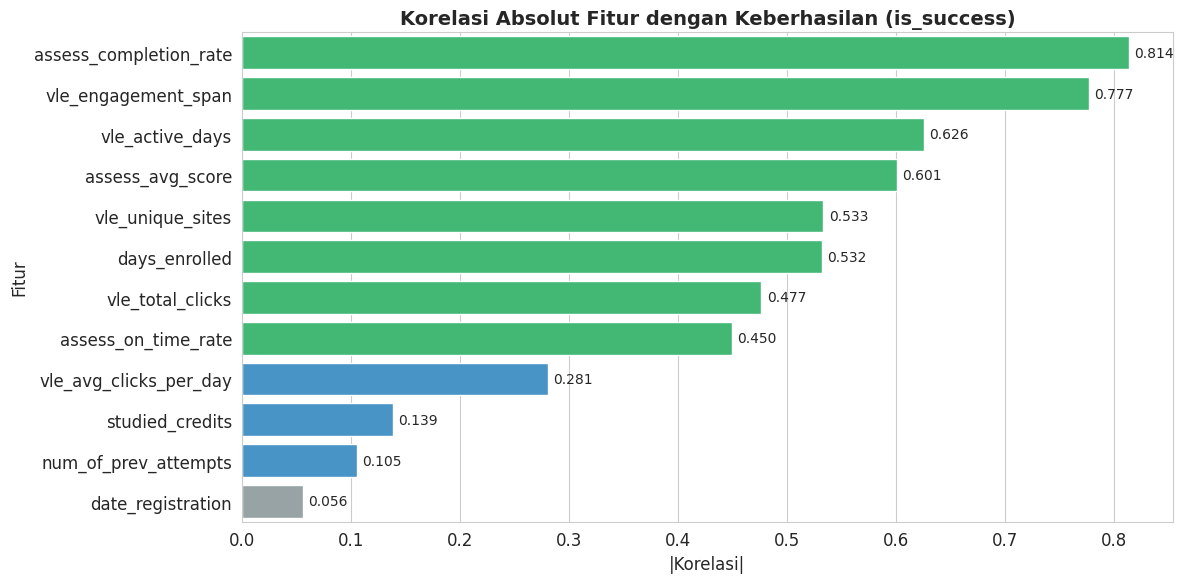

In [51]:
# 8.5 Statistik Master Dataframe
print(" STATISTIK DESKRIPTIF MASTER DATAFRAME")

# Fitur numerik utama
key_features = [
    'num_of_prev_attempts', 'studied_credits',
    'days_enrolled', 'date_registration',
    'assess_avg_score', 'assess_completion_rate', 'assess_on_time_rate',
    'vle_total_clicks', 'vle_unique_sites', 'vle_active_days',
    'vle_avg_clicks_per_day', 'vle_engagement_span'
]

display(student_master[key_features].describe().round(2))

# Korelasi antara fitur numerik dan keberhasilan
print("Korelasi Fitur Numerik dengan Keberhasilan (is_success):")
correlations = student_master[key_features + ['is_success']].corr()['is_success'].drop('is_success')
correlations = correlations.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors_corr = ['#2ecc71' if v > 0.3 else '#3498db' if v > 0.1 else '#95a5a6'
               for v in correlations.values]
sns.barplot(x=correlations.values, y=correlations.index, palette=colors_corr, ax=ax)
ax.set_title('Korelasi Absolut Fitur dengan Keberhasilan (is_success)',
             fontweight='bold')
ax.set_xlabel('|Korelasi|')
ax.set_ylabel('Fitur')
for i, v in enumerate(correlations.values):
    ax.text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

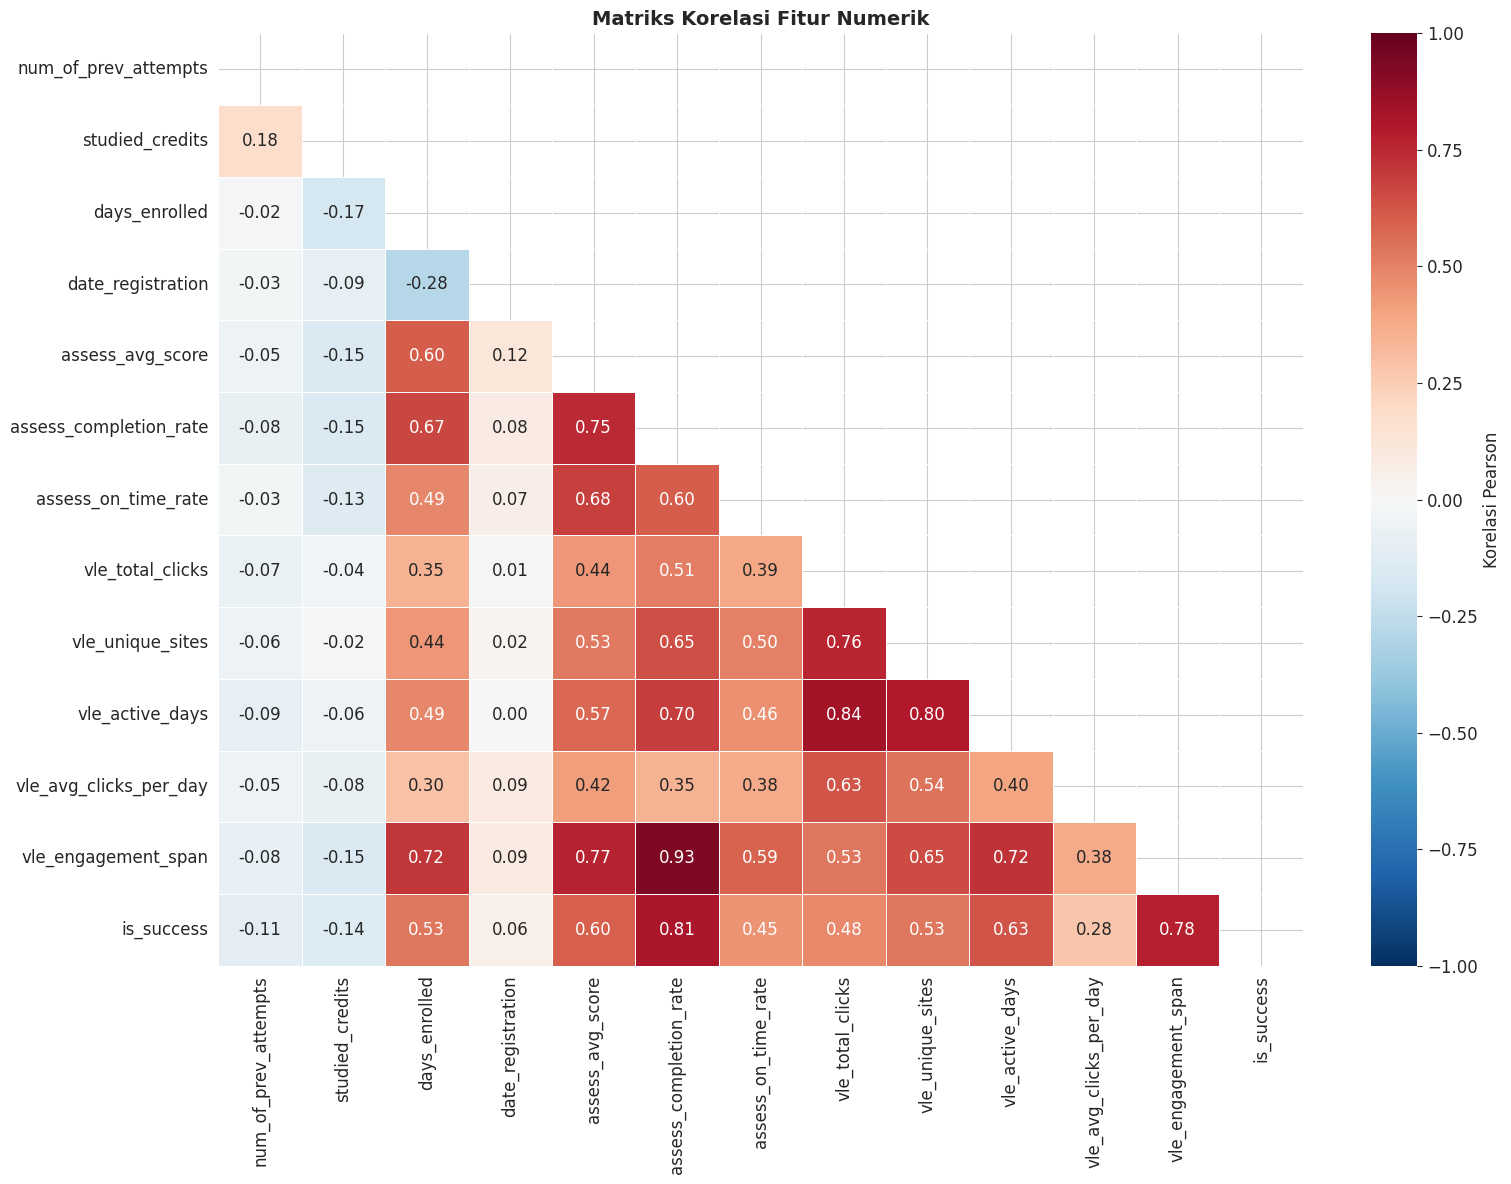

In [48]:
# 8.6 Heatmap Korelasi Lengkap
# Pilih fitur numerik untuk korelasi
numeric_features = student_master[key_features + ['is_success']]
corr_matrix = numeric_features.corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1,
            cbar_kws={'label': 'Korelasi Pearson'})
ax.set_title('Matriks Korelasi Fitur Numerik', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

In [49]:
# 8.7 Ekspor Data ke Google Drive

print(" Menyimpan data yang sudah diproses...")
print(f" Output folder: {OUTPUT_PATH}\n")

# 1. Student Master
master_path = os.path.join(OUTPUT_PATH, 'student_master.csv')
# Hapus kolom helper sebelum menyimpan
student_master_export = student_master.drop(columns=['is_success'], errors='ignore')
student_master_export.to_csv(master_path, index=False)
print(f" student_master.csv tersimpan!")
print(f"Path: {master_path}")
print(f"Shape: {student_master_export.shape[0]:,} baris x {student_master_export.shape[1]} kolom")
print(f"Ukuran: {os.path.getsize(master_path) / 1024**2:.2f} MB")

# 2. VLE Aggregated
vle_agg_path = os.path.join(OUTPUT_PATH, 'vle_aggregated.csv')
vle_features.to_csv(vle_agg_path, index=False)
print(f"\n vle_aggregated.csv tersimpan!")
print(f"Path: {vle_agg_path}")
print(f"Shape: {vle_features.shape[0]:,} baris x {vle_features.shape[1]} kolom")
print(f"Ukuran: {os.path.getsize(vle_agg_path) / 1024**2:.2f} MB")

print("\n" + "=" * 70)
print(" SEMUA DATA BERHASIL DIEKSPOR!")
print("=" * 70)

 Menyimpan data yang sudah diproses...
 Output folder: /content/drive/MyDrive/AI-Learning Path/processed

 student_master.csv tersimpan!
Path: /content/drive/MyDrive/AI-Learning Path/processed/student_master.csv
Shape: 32,593 baris x 36 kolom
Ukuran: 7.69 MB

 vle_aggregated.csv tersimpan!
Path: /content/drive/MyDrive/AI-Learning Path/processed/vle_aggregated.csv
Shape: 29,228 baris x 13 kolom
Ukuran: 2.16 MB

 SEMUA DATA BERHASIL DIEKSPOR!


### 📝 Ringkasan Fitur yang Dibuat

**Fitur VLE Agregat:**
| Fitur | Deskripsi |
|---|---|
| `vle_total_clicks` | Total klik VLE sepanjang modul |
| `vle_unique_sites` | Jumlah situs VLE unik yang dikunjungi |
| `vle_active_days` | Jumlah hari aktif di VLE |
| `vle_avg_clicks_per_day` | Rata-rata klik per hari aktif |
| `vle_engagement_span` | Rentang waktu engagement (hari pertama – hari terakhir) |
| `vle_max_daily_clicks` | Klik maksimum dalam satu interaksi |

**Fitur Penilaian Agregat:**
| Fitur | Deskripsi |
|---|---|
| `assess_avg_score` | Skor rata-rata semua penilaian |
| `assess_completion_rate` | Rasio penilaian yang dikumpulkan |
| `assess_on_time_rate` | Rasio pengumpulan tepat waktu |
| `assess_weighted_score` | Skor tertimbang berdasarkan bobot penilaian |

**Fitur Registrasi:**
| Fitur | Deskripsi |
|---|---|
| `days_enrolled` | Jumlah hari terdaftar |
| `is_unregistered` | Apakah membatalkan registrasi (0/1) |
| `early_registration` | Apakah mendaftar sebelum modul dimulai (0/1) |

---
## 🏁 Kesimpulan & Temuan Utama

### 📊 Ringkasan Dataset
- **32.593** mahasiswa unik di 7 modul dan 4 semester presentasi
- **~10.6 juta** catatan interaksi VLE
- **173.912** catatan skor penilaian
- **20 tipe** aktivitas VLE berbeda

### 🔑 Temuan Kunci

1. **VLE Engagement adalah prediktor terkuat keberhasilan:**
   - Mahasiswa berhasil memiliki total klik, hari aktif, dan situs unik yang jauh lebih tinggi.
   - Pola engagement temporal dapat digunakan untuk deteksi dini risiko dropout.

2. **Skor penilaian berkorelasi kuat dengan hasil akhir:**
   - Mahasiswa Distinction rata-rata mendapat skor 80+.
   - Ketepatan waktu pengumpulan juga merupakan indikator penting.

3. **Bias sosial-ekonomi terdeteksi:**
   - IMD Band rendah (daerah deprived) berkorelasi dengan tingkat kegagalan lebih tinggi.
   - Ini menunjukkan perlunya intervensi khusus untuk kelompok rentan.

4. **Pendidikan sebelumnya berpengaruh signifikan:**
   - Mahasiswa dengan kualifikasi lebih tinggi cenderung lebih berhasil.

5. **Withdrawal terjadi sepanjang modul:**
   - Banyak terjadi di awal, tapi juga signifikan di pertengahan modul.
   - Early warning system berdasarkan VLE engagement bisa efektif.

### 🚀 Langkah Selanjutnya
1. Gunakan `student_master.csv` untuk membangun model prediktif.
2. Implementasi early warning system berbasis engagement temporal.
3. Analisis lebih lanjut untuk mengidentifikasi intervensi yang efektif.
4. A/B testing untuk strategi dukungan mahasiswa berisiko.

In [50]:
# Pembersihan Memori Akhir
print("Membersihkan memori...")
gc.collect()
print(" Selesai!")
print(" Notebook EDA Komprehensif OULAD telah selesai dijalankan!")
print(f" File output tersimpan di: {OUTPUT_PATH}")

Membersihkan memori...
 Selesai!
 Notebook EDA Komprehensif OULAD telah selesai dijalankan!
 File output tersimpan di: /content/drive/MyDrive/AI-Learning Path/processed
